# 📊 ML Portfolio Performance Analysis - Regime-Switching Strategies

## Overview
This Jupyter Notebook analyzes the performance of 5 machine learning models across 5 basket strategies using regime-switching portfolio construction. It generates:
1. **Table 1 (Main Text)**: Performance comparison of best ML models per basket (Gross vs Net returns).
2. **Table 2 (Main Text)**: Basket-level analysis comparing Offensive vs Defensive strategies.
3. **Table A1 (Appendix)**: Complete performance metrics for all 25 ML strategies (5 models × 5 baskets).
4. **Table A2 (Appendix)**: Transaction costs breakdown by basket and period.
5. **Table A3 (Appendix)**: Portfolio turnover analysis (stock-level + inter-basket switching).
6. **Table A4 (Appendix)**: Break-even transaction cost analysis (vs Market + vs 50/50 benchmarks).
7. **Figure 1 (Main Text)**: Cumulative performance plot of top strategies vs market benchmark.

The notebook validates ML strategy profitability, documents transaction cost impacts, and provides robustness analysis across different market regimes.

## Key Features
- **5 ML Models**: Logistic L2, Random Forest, XGBoost, LSTM Expanding, LSTM Rolling 10Y.
- **5 Basket Strategies**: Economic Basket, Beta Expansion, Rolling Beta, EWMA Beta, Kalman Beta.
- **3 Investment Regimes**: Regime-Switching (dynamic), Buy&Hold Offensive, Buy&Hold Defensive.
- **Gross vs Net Analysis**: Performance before and after Frazzini (2018) transaction costs.
- **Transaction Cost Model**: Annual stock-level rebalancing (June) + monthly inter-basket switching costs.
- **Break-Even Analysis**: Identifies TC thresholds where strategies lose their edge vs benchmarks.
- **Market Benchmark**: Equal-weighted NYSE P20 portfolio (no transaction costs).

## Methodology

### Data Loading & Preparation
1. Load ML portfolio results from `data/ml_data/portfolios/{model}/portfolio_results_monthly.parquet` (5 files).
2. Extract monthly returns by basket × strategy × model.
3. Load Fama-French 5-factor data for risk-adjusted performance metrics.
4. Load transaction cost time-series from `data/ml_data/transaction_costs/tc_timeseries_monthly.parquet`.
5. Load market benchmark from `data/ml_data/market/market_returns_ew_nys80.parquet`.

### Performance Metrics Calculation
For each strategy, compute:
- **Annualized Return**: Arithmetic mean × 12.
- **CAGR**: Geometric compound annual growth rate.
- **Volatility**: Annualized standard deviation (√12 × monthly std).
- **Sharpe Ratio**: (Excess return mean × 12) / (Excess return std × √12).
- **Sortino Ratio**: Sharpe with downside deviation only.
- **Max Drawdown**: Largest peak-to-trough decline.
- **Recovery Period**: Months from max drawdown to recovery.

### Transaction Cost Application
1. **Stock-Level TC**: Applied **once per year in June** (Fama-French convention).
   - Uses Frazzini (2018) schedule: 50 bps (1980-1999), 30 bps (2000-2009), 20 bps (2010-2024).
   - Applied to annual turnover × number of stocks rebalanced.

2. **Inter-Basket TC**: Applied **monthly** for regime switches.
   - Economic Basket: 0 (fixed Offensive/Defensive, no switching).
   - Beta Baskets (2-5): Captures High Beta ↔ Low Beta transitions.
   - Measured from allocation file changes (signal selection dynamics).

3. **NET Returns**: `return_net = return_gross - (total_tc_pct / 100)`.

### Table 1: Performance Comparison (Main Text)
1. For each basket, select the **best-performing ML model** (by Sharpe ratio).
2. Display metrics for **Gross** (Panel A) and **Net** (Panel B) returns.
3. Include market benchmark (NYSE P20 EW) for comparison.
4. Format: 9 columns (Basket, Model, Ann. Ret., CAGR, Vol., Sharpe, Sortino, Max DD, DD Date).
5. Export LaTeX to `results/latex/results/01_results_table_performance_comparison.tex`.

### Table 2: Basket-Level Analysis (Main Text)
1. Average performance across all 5 ML models for each basket.
2. Compare **Offensive** vs **Defensive** regimes (Buy&Hold strategies).
3. Display for **Gross** (Panel A) and **Net** (Panel B) returns.
4. Export LaTeX to `results/latex/results/03_results_table_basket_level_performance.tex`.

### Table A1: Complete ML Performance (Appendix)
1. List all 25 strategies (5 baskets × 5 models) with full metrics.
2. Format: Landscape, dual minipage (Gross | Net side-by-side).
3. Within each basket, sort models by Sharpe ratio (descending).
4. Export LaTeX to `results/latex/results/01_appendix_performance_comparison_full.tex`.

### Table A2: Transaction Costs (Appendix)
1. **Panel A**: Aggregate TC by basket (1980-2024 mean).
2. **Panel B**: TC breakdown by period (1980-1999, 2000-2009, 2010-2024).
3. Columns: Stock TC, Inter TC, Total TC (all in bps/year).
4. Export LaTeX to `results/latex/results/02_appendix_TC_table_transaction_costs.tex`.

### Table A3: Turnover Analysis (Appendix)
1. **Panel A**: Aggregate turnover by basket (annual %).
2. **Panel B**: Turnover breakdown by period.
3. Columns: Stock Turnover, Inter-Basket Turnover, Total Turnover.
4. Export LaTeX to `results/latex/results/04_appendix_table_turnover.tex`.

### Table A4: Break-Even Analysis (Appendix)
1. **Panel A**: Headroom vs Market Benchmark (14.71% annual).
   - Formula: `Break-Even TC = (R_net_ML - R_market) × 10,000` (bps/year).
   - TC Multiplier = Total TC @ BE / Real TC (robustness measure).
2. **Panel B**: Headroom vs 50/50 Benchmark (static Offensive/Defensive mix).
   - 50/50 computed **net** using its own turnover-based TC model.
3. Export LaTeX to `results/latex/results/09_appendix_A.X_Transaction_Cost_Breakeven.tex`.

### Figure 1: Cumulative Performance (Main Text)
1. Plot cumulative wealth index (log scale) for:
   - Best strategy: LSTM Expanding + EWMA Beta.
   - Runner-up: LSTM Rolling 10Y + Beta Expansion.
   - Market Benchmark (NYSE P20 EW).
2. Overlay recession periods (GFC 2007-2009, COVID 2020).
3. Export PNG to `results/latex/results/00_FIG_results_performance_best_strategies.png` (300 dpi).

## Dependencies
- Libraries: pandas, numpy, pathlib, matplotlib, seaborn.
- Data:
  - ML portfolios: `data/ml_data/portfolios/{model}/portfolio_results_monthly.parquet` (5 files).
  - Transaction costs: `data/ml_data/transaction_costs/tc_timeseries_monthly.parquet`.
  - Turnover: Computed from `data/portfolios/{signal}_signal.parquet` (25 files) + allocation files.
  - Market benchmark: `data/ml_data/market/market_returns_ew_nys80.parquet`.
  - Fama-French factors: `data/factors/ff/FF5.csv`.
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. **Cell 1-2**: Load data and define helper functions (`compute_metrics`).
2. **Cell 3-5**: Harmonize datasets (basket/strategy mappings for TC merge).
3. **Cell 6**: Display GROSS performance (by basket, by model, overall ranking).
4. **Cell 7**: Merge transaction costs with portfolio returns.
5. **Cell 8-9**: Compute and display NET performance (with TC impact analysis).
6. **Cell 10**: Export Table 1 (best performers per basket, Gross vs Net).
7. **Cell 11**: Export Table A1 (complete ML performance, all 25 strategies).
8. **Cell 12**: Export Table A2 (transaction costs by basket and period).
9. **Cell 13**: Export Table A3 (turnover analysis).
10. **Cell 14**: Basket-level analysis (Offensive vs Defensive).
11. **Cell 15**: Export Table 2 (basket-level performance to LaTeX).
12. **Cell 16**: Generate Figure 1 (cumulative performance plot).
13. **Cell 17-19**: Export monthly returns (Buy&Hold + ML strategies) to Parquet.
14. **Cell 20**: Break-even TC analysis (vs Market + vs 50/50).
15. **Cell 21**: Export Table A4 (break-even analysis to LaTeX).

## Output Files

### Main Text
- **results/latex/results/01_results_table_performance_comparison.tex**: Performance comparison (Panel A: Gross, Panel B: Net).
  - Columns: Basket, Best ML Model, Ann. Ret., CAGR, Vol., Sharpe, Sortino, Max DD, DD Date.
  - Format: Booktabs, two-panel layout, resizebox (0.95 textwidth).

- **results/latex/results/03_results_table_basket_level_performance.tex**: Basket-level analysis (Offensive vs Defensive).
  - Columns: Basket, Regime, Ann. Ret., CAGR, Vol., Sharpe, Sortino, Max DD, DD Date.
  - Format: Booktabs, sorted by Sharpe ratio within each basket.

- **results/latex/results/00_FIG_results_performance_best_strategies.png**: Cumulative wealth plot (1980-2024).
  - Shows growth of $100 invested in top strategies vs market benchmark.
  - Log scale, recession overlays, 300 dpi.

### Appendix
- **results/latex/results/01_appendix_performance_comparison_full.tex**: Complete ML performance (25 strategies).
  - Format: Landscape, dual minipage (Gross | Net).
  - Sorted by basket (fixed order), then by Sharpe (descending) within basket.

- **results/latex/results/02_appendix_TC_table_transaction_costs.tex**: Transaction costs breakdown.
  - Panel A: Aggregate (1980-2024).
  - Panel B: By period (1980-1999, 2000-2009, 2010-2024).
  - Columns: Stock TC, Inter TC, Total TC (bps/year).

- **results/latex/results/04_appendix_table_turnover.tex**: Turnover analysis.
  - Panel A: Aggregate (annual %).
  - Panel B: By period.
  - Columns: Stock Turnover, Inter Turnover, Total Turnover.

- **results/latex/results/09_appendix_A.X_Transaction_Cost_Breakeven.tex**: Break-even analysis.
  - Panel A: vs Market Benchmark (14.71%).
  - Panel B: vs 50/50 Benchmark (computed net).
  - Columns: NET Return, Headroom, Total TC @ BE, TC Multiplier.

### Intermediate Files
- **data/results/monthly_returns_by_strategy_basket.parquet**: Buy&Hold returns (Offensive/Defensive).
- **data/results/monthly_returns_ml_by_model_basket.parquet**: ML returns (all 25 strategies).
- **data/results/transaction_costs_monthly_june.parquet**: TC time-series (June only).
- **data/results/turnover_monthly_june.parquet**: Turnover time-series (June only).


## References
- Fama & French (1993) - "Common Risk Factors in the Returns on Stocks and Bonds" (portfolio formation methodology).
- Frazzini, Israel & Moskowitz (2012, 2018) - "Trading Costs" (transaction cost schedule).
- Hou, Xue & Zhang (2015) - "Digesting Anomalies: An Investment Approach" (regime-switching motivation).



In [88]:
# Cell 1: Imports

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [89]:
# Cell 2: Load Data

# ML Models
MODELS = {
    'Logistic L2': 'data/ml_data/portfolios/logistic/portfolio_results_monthly.parquet',
    'Random Forest': 'data/ml_data/portfolios/random_forest/portfolio_results_monthly.parquet',
    'XGBoost': 'data/ml_data/portfolios/xgboost/portfolio_results_monthly.parquet',
    'LSTM Expanding': 'data/ml_data/portfolios/lstm_expanding/portfolio_results_monthly.parquet',
    'LSTM Rolling 10Y': 'data/ml_data/portfolios/lstm_rolling_10y/portfolio_results_monthly.parquet'
}

all_data = {}
for model_name, path in MODELS.items():
    df = pd.read_parquet(path)
    df['model'] = model_name
    all_data[model_name] = df

df_all = pd.concat(all_data.values(), ignore_index=False).sort_index()

# Transaction Costs
df_tc = pd.read_parquet('data/ml_data/transaction_costs/tc_timeseries_monthly.parquet')
df_tc = df_tc[(df_tc['date'] >= '1980-07-31') & (df_tc['date'] <= '2024-06-28')]
df_tc = df_tc.set_index('date')

# Risk-Free Rate
ff5 = pd.read_csv('data/factors/ff/FF5.csv')
ff5['date'] = pd.to_datetime(ff5['dateff'])
ff5 = ff5[(ff5['date'] >= '1980-07-31') & (ff5['date'] <= '2024-06-28')]
rf_monthly = ff5.set_index('date')['rf'].sort_index()

print(f"✅ Data Loaded:")
print(f"   ML Models: {df_all['model'].nunique()} models × {df_all['basket'].nunique()} baskets")
print(f"   Strategies: {df_all['strategy'].unique()}")
print(f"   TC Data: {len(df_tc)} rows")
print(f"   RF Data: {len(rf_monthly)} months")
print(f"   Period: {df_all.index.min().date()} → {df_all.index.max().date()}")


✅ Data Loaded:
   ML Models: 5 models × 5 baskets
   Strategies: ['Regime-Switching' 'Buy&Hold Defensive' 'Market' 'Static 60/40'
 'Buy&Hold Offensive']
   TC Data: 5280 rows
   RF Data: 528 months
   Period: 1980-07-31 → 2024-06-28


In [90]:
# Cell 3: Harmonize Datasets

# Basket name mapping (Portfolio → TC)
BASKET_MAP = {
    'Basket_1_Economic': 'basket_1',
    'Basket_2_Beta_Expansion': 'basket_2',
    'Basket_3_Rolling_Beta': 'basket_3',
    'Basket_4_EWMA_Beta': 'basket_4',
    'Basket_5_Kalman_Beta': 'basket_5'
}

# Strategy mapping (Portfolio → TC)
STRATEGY_MAP = {
    'Buy&Hold Offensive': 'Offensive',
    'Buy&Hold Defensive': 'Defensive'
}

# Add mapped basket column to portfolio data
df_all['basket_tc'] = df_all['basket'].map(BASKET_MAP)
df_all['strategy_tc'] = df_all['strategy'].map(STRATEGY_MAP)

# For Regime-Switching: use Offensive TC (conservative assumption)
df_all.loc[df_all['strategy'] == 'Regime-Switching', 'strategy_tc'] = 'Offensive'

print("✅ Harmonization Complete")
print(f"   Portfolio baskets mapped to TC baskets")
print(f"   Regime-Switching → Offensive TC (Frazzini convention)")

✅ Harmonization Complete
   Portfolio baskets mapped to TC baskets
   Regime-Switching → Offensive TC (Frazzini convention)


## Transaction Costs by Basket

In [91]:
# Cell 4: Display Transaction Costs by Basket

# Aggregate TC by basket
tc_by_basket = df_tc.groupby('basket').agg({
    'stock_tc_pct': 'mean',
    'inter_tc_pct': 'mean',
    'total_tc_pct': 'mean'
}).round(4)

# Rename baskets for clarity
basket_names = {
    'basket_1': 'Economic',
    'basket_2': 'Beta Expansion',
    'basket_3': 'Rolling Beta',
    'basket_4': 'EWMA Beta',
    'basket_5': 'Kalman Beta'
}
tc_by_basket.index = tc_by_basket.index.map(basket_names)
tc_by_basket.columns = ['Stock-Level', 'Inter-Basket', 'Total']

# Convert to basis points (multiply by 100) and format
tc_display = tc_by_basket * 100
tc_display.columns = ['Stock TC (bps/yr)', 'Inter TC (bps/yr)', 'Total TC (bps/yr)']

print("="*100)
print("TRANSACTION COSTS BY BASKET (Frazzini Convention - 1x/year in June)")
print("="*100)
print(tc_display.to_string())
print("\nNote: Applied once per year in June rebalancing (Fama-French convention)")
print("="*100)

TRANSACTION COSTS BY BASKET (Frazzini Convention - 1x/year in June)
                Stock TC (bps/yr)  Inter TC (bps/yr)  Total TC (bps/yr)
basket                                                                 
Economic                     3.08               0.00               3.08
Beta Expansion               3.13               0.05               3.18
Rolling Beta                 3.09               0.99               4.08
EWMA Beta                    3.05               1.73               4.78
Kalman Beta                  3.10               0.98               4.08

Note: Applied once per year in June rebalancing (Fama-French convention)


## Performance Metrics: GROSS Returns

In [92]:
# Cell 5: Compute Performance Metrics (GROSS)

def compute_metrics(returns_series, rf_series, label):
    """Compute performance metrics with excess returns"""
    
    # Align RF to returns
    rf_aligned = rf_series.reindex(returns_series.index, method='nearest')
    rf_aligned = rf_aligned.fillna(rf_series.mean())
    
    excess_returns = returns_series - rf_aligned
    
    # CAGR
    cumulative = (1 + returns_series).prod()
    years = len(returns_series) / 12
    cagr = (cumulative ** (1 / years)) - 1
    
    # Annualized Return (arithmetic mean)
    annualized_return = returns_series.mean() * 12
    
    # Volatility (annualized)
    volatility = returns_series.std() * np.sqrt(12)
    
    # Sharpe Ratio
    sharpe = (excess_returns.mean() * 12) / (excess_returns.std() * np.sqrt(12))
    
    # Sortino Ratio
    downside_returns = excess_returns[excess_returns < 0]
    downside_std = downside_returns.std() * np.sqrt(12) if len(downside_returns) > 0 else volatility
    sortino = (excess_returns.mean() * 12) / downside_std if downside_std > 0 else 0
    
    # Drawdown
    cum_returns = (1 + returns_series).cumprod()
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    max_dd_date = drawdown.idxmin()
    
    # Recovery period (months from max DD to recovery)
    if max_dd < 0:
        dd_start = running_max[:max_dd_date].idxmax()
        recovery_idx = cum_returns[max_dd_date:] >= running_max.loc[dd_start]
        if recovery_idx.any():
            recovery_date = recovery_idx[recovery_idx].index[0]
            recovery_months = (recovery_date.year - max_dd_date.year) * 12 + (recovery_date.month - max_dd_date.month)
        else:
            recovery_months = np.nan
    else:
        recovery_months = 0
    
    # Cumulative return
    cum_return = cumulative - 1
    
    return {
        'Model': label,
        'Ann. Return': annualized_return,
        'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Max DD': max_dd,
        'Max DD Date': max_dd_date,
        'Recovery (months)': recovery_months,
        'Cum Return': cum_return
    }

# Compute for all models × baskets (Regime-Switching only)
df_regime = df_all[df_all['strategy'] == 'Regime-Switching']

results_gross = []

for model in df_regime['model'].unique():
    for basket in df_regime['basket'].unique():
        subset = df_regime[(df_regime['model'] == model) & (df_regime['basket'] == basket)]
        
        if len(subset) == 0:
            continue
        
        returns = subset.groupby(subset.index)['portfolio_return'].first()
        returns.index = pd.DatetimeIndex(returns.index)
        
        label = f"{model} | {basket}"
        metrics = compute_metrics(returns, rf_monthly, label)
        results_gross.append(metrics)

df_gross = pd.DataFrame(results_gross)
df_gross = df_gross.sort_values('Sharpe', ascending=False)

print("✅ GROSS metrics computed for", len(df_gross), "combinations")

✅ GROSS metrics computed for 25 combinations


In [93]:
# Cell 7.5: Load TRUE Market Benchmark (CORRIGÉ)

print("\n" + "="*120)
print("BUY & HOLD + MARKET BENCHMARK: GROSS RETURNS")
print("="*120)

# ════════════════════════════════════════════════════════════════════════════
# 1. BUY & HOLD STRATEGIES (par basket)
# ════════════════════════════════════════════════════════════════════════════

df_bh = df_all[
    (df_all['model'] == 'XGBoost') &
    (df_all['strategy'].isin(['Buy&Hold Offensive', 'Buy&Hold Defensive']))
].copy()

results_bh = []

for basket in df_bh['basket'].unique():
    for strategy in ['Buy&Hold Offensive', 'Buy&Hold Defensive']:
        subset = df_bh[
            (df_bh['basket'] == basket) &
            (df_bh['strategy'] == strategy)
        ]

        if len(subset) == 0:
            continue

        returns = subset.groupby(subset.index)['portfolio_return'].first()
        returns.index = pd.DatetimeIndex(returns.index)

        label = f"{strategy} | {basket}"
        metrics = compute_metrics(returns, rf_monthly, label)
        results_bh.append(metrics)

# ════════════════════════════════════════════════════════════════════════════
# 2. TRUE MARKET BENCHMARK (from separate file)
# ════════════════════════════════════════════════════════════════════════════

try:
    df_market_true = pd.read_parquet('data/ml_data/market/market_returns_ew_nys80.parquet')

    # Set index to date if needed
    if 'date' in df_market_true.columns:
        df_market_true = df_market_true.set_index('date')

    # CRITICAL FIX: Use the correct column name 'ret_market_ew'
    if 'ret_market_ew' not in df_market_true.columns:
        raise ValueError(f"Column 'ret_market_ew' not found. Available: {list(df_market_true.columns)}")

    market_returns = df_market_true['ret_market_ew'].copy()

    # Filter to match portfolio date range
    market_returns = market_returns[
        (market_returns.index >= '1980-07-31') &
        (market_returns.index <= '2024-06-28')
    ]
    market_returns.index = pd.DatetimeIndex(market_returns.index)

    # Verify data quality
    print(f"\n📊 True Market data loaded:")
    print(f"   • Observations: {len(market_returns)}")
    print(f"   • Mean return: {market_returns.mean():.6f}")
    print(f"   • Std return: {market_returns.std():.6f}")

    # Compute metrics
    label = "Market | Universal"
    metrics = compute_metrics(market_returns, rf_monthly, label)
    results_bh.append(metrics)

    print(f"\n✅ True Market Benchmark:")
    print(f"   • CAGR: {metrics['CAGR']:.2%}")
    print(f"   • Volatility: {metrics['Volatility']:.2%}")
    print(f"   • Sharpe: {metrics['Sharpe']:.3f}")
    print(f"   • Max DD: {metrics['Max DD']:.2%}")

except FileNotFoundError:
    print("\n⚠️  WARNING: True market file not found")
    print("   Market Benchmark will NOT be included in results")

df_bh_gross = pd.DataFrame(results_bh)

print(f"\n✅ Buy&Hold + Market Benchmark (GROSS) computed: {len(df_bh_gross)} combinations")


BUY & HOLD + MARKET BENCHMARK: GROSS RETURNS

📊 True Market data loaded:
   • Observations: 528
   • Mean return: 0.012255
   • Std return: 0.050971

✅ True Market Benchmark:
   • CAGR: 13.95%
   • Volatility: 17.66%
   • Sharpe: 0.613
   • Max DD: -48.40%

✅ Buy&Hold + Market Benchmark (GROSS) computed: 11 combinations


In [94]:
# Cell 6: Display GROSS Performance - BY BASKET → BY MODEL

# Sépare correctement le nom complet
df_gross_copy = df_gross.copy()
df_gross_copy['ML_Model'] = df_gross_copy['Model'].str.split(' \| ', expand=True)[0]
df_gross_copy['Basket'] = df_gross_copy['Model'].str.split(' \| ', expand=True)[1]

# Basket mapping
basket_names = {
    'Basket_1_Economic': 'Economic',
    'Basket_2_Beta_Expansion': 'Beta Expansion',
    'Basket_3_Rolling_Beta': 'Rolling Beta',
    'Basket_4_EWMA_Beta': 'EWMA Beta',
    'Basket_5_Kalman_Beta': 'Kalman Beta'
}

print("="*120)
print("PERFORMANCE METRICS: GROSS RETURNS (Before Transaction Costs)")
print("="*120)

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1: BY BASKET (avec Market Benchmark UNIVERSEL)
# ═══════════════════════════════════════════════════════════════════════════

# PRE-LOAD UNIVERSAL MARKET BENCHMARK (same for ALL baskets)
market_universal = df_bh_gross[df_bh_gross['Model'] == 'Market | Universal'].copy()

for basket in sorted(df_gross_copy['Basket'].unique()):
    # Get ML models for this basket
    basket_data = df_gross_copy[df_gross_copy['Basket'] == basket].copy()
    basket_data = basket_data.sort_values('Sharpe', ascending=False)
    
    # Combine ML models + Market
    combined = []
    
    # Add ML models
    for _, row in basket_data.iterrows():
        combined.append({
            'Strategy': row['ML_Model'],
            'Ann. Return': row['Ann. Return'],
            'CAGR': row['CAGR'],
            'Volatility': row['Volatility'],
            'Sharpe': row['Sharpe'],
            'Sortino': row['Sortino'],
            'Max DD': row['Max DD'],
            'DD Date': row['Max DD Date']  # ← AJOUTER ICI
        })
    
    # Add UNIVERSAL Market Benchmark (IDENTICAL for all baskets)
    if len(market_universal) > 0:
        row = market_universal.iloc[0]
        combined.append({
            'Strategy': '─── Market Benchmark ───',
            'Ann. Return': row['Ann. Return'],
            'CAGR': row['CAGR'],
            'Volatility': row['Volatility'],
            'Sharpe': row['Sharpe'],
            'Sortino': row['Sortino'],
            'Max DD': row['Max DD'],
            'DD Date': row['Max DD Date'] 
        })
    
    # Create display
    basket_display = pd.DataFrame(combined)
    basket_display['Ann. Return'] = basket_display['Ann. Return'].apply(lambda x: f"{x:.2%}")
    basket_display['CAGR'] = basket_display['CAGR'].apply(lambda x: f"{x:.2%}")
    basket_display['Volatility'] = basket_display['Volatility'].apply(lambda x: f"{x:.2%}")
    basket_display['Sharpe'] = basket_display['Sharpe'].apply(lambda x: f"{x:.3f}")
    basket_display['Sortino'] = basket_display['Sortino'].apply(lambda x: f"{x:.3f}")
    basket_display['Max DD'] = basket_display['Max DD'].apply(lambda x: f"{x:.4%}")
    basket_display['DD Date'] = basket_display['DD Date'].apply(lambda x: x.strftime('%Y-%m') if pd.notna(x) else 'N/A')
    basket_name = basket_names.get(basket, basket)
    print(f"\n{'─'*120}")
    print(f"📊 BASKET: {basket_name}")
    print(f"{'─'*120}")
    print(basket_display.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2: BY MODEL
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*120)
print("PERFORMANCE BY ML MODEL (All Baskets)")
print("="*120)

for model in sorted(df_gross_copy['ML_Model'].unique()):
    model_data = df_gross_copy[df_gross_copy['ML_Model'] == model].copy()
    model_data = model_data.sort_values('Sharpe', ascending=False)
    
    model_display = model_data[['Basket', 'Ann. Return', 'CAGR', 'Sharpe', 'Sortino', 'Max DD', 'Max DD Date']].copy()  # ← Ajouter 'Max DD Date'
    model_display['Basket'] = model_display['Basket'].apply(lambda x: basket_names.get(x, x))
    model_display['Ann. Return'] = model_display['Ann. Return'].apply(lambda x: f"{x:.2%}")
    model_display['CAGR'] = model_display['CAGR'].apply(lambda x: f"{x:.2%}")
    model_display['Sharpe'] = model_display['Sharpe'].apply(lambda x: f"{x:.3f}")
    model_display['Sortino'] = model_display['Sortino'].apply(lambda x: f"{x:.3f}")
    model_display['Max DD'] = model_display['Max DD'].apply(lambda x: f"{x:.4%}")
    model_display['Max DD Date'] = model_display['Max DD Date'].apply(lambda x: x.strftime('%Y-%m') if pd.notna(x) else 'N/A')
    
    print(f"\n{'─'*120}")
    print(f"🤖 MODEL: {model}")
    print(f"{'─'*120}")
    print(model_display.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3: OVERALL RANKING (TOP 10 avec podium)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*120)
print("🏆 OVERALL RANKING - TOP 10 PERFORMERS (Regime-Switching)")
print("="*120)

top10 = df_gross_copy.nlargest(10, 'Sharpe').copy()

# Add ranking column
top10.insert(0, 'Rank', range(1, len(top10) + 1))

# Split Model into ML + Basket for better display
top10['ML Model'] = top10['Model'].str.split(' \| ', expand=True)[0]
top10['Basket'] = top10['Model'].str.split(' \| ', expand=True)[1].apply(lambda x: basket_names.get(x, x))

# Create display
ranking_display = top10[['Rank', 'ML Model', 'Basket', 'Ann. Return', 'CAGR', 'Sharpe', 'Sortino', 'Max DD']].copy()
ranking_display['Ann. Return'] = ranking_display['Ann. Return'].apply(lambda x: f"{x:.2%}")
ranking_display['CAGR'] = ranking_display['CAGR'].apply(lambda x: f"{x:.2%}")
ranking_display['Sharpe'] = ranking_display['Sharpe'].apply(lambda x: f"{x:.3f}")
ranking_display['Sortino'] = ranking_display['Sortino'].apply(lambda x: f"{x:.3f}")
ranking_display['Max DD'] = ranking_display['Max DD'].apply(lambda x: f"{x:.2%}")

# Display podium
print("\n" + "┌" + "─"*118 + "┐")
print("│" + " "*45 + "🥇 PODIUM 🥇" + " "*61 + "│")
print("└" + "─"*118 + "┘")
print(ranking_display.head(3).to_string(index=False))

print("\n" + "┌" + "─"*118 + "┐")
print("│" + " "*44 + "📊 TOP 4-5 📊" + " "*60 + "│")
print("└" + "─"*118 + "┘")
print(ranking_display.iloc[3:5].to_string(index=False))

print("\n" + "┌" + "─"*118 + "┐")
print("│" + " "*44 + "📈 TOP 6-10 📈" + " "*59 + "│")
print("└" + "─"*118 + "┘")
print(ranking_display.iloc[5:10].to_string(index=False))

print("\n" + "="*120)
print("KEY INSIGHTS:")
print("="*120)
best = ranking_display.iloc[0]
print(f"🥇 Champion: {best['ML Model']} on {best['Basket']}")
print(f"   Sharpe: {best['Sharpe']} | CAGR: {best['CAGR']} | Max DD: {best['Max DD']}")

# Count by model
model_counts = top10['ML Model'].value_counts()
print(f"\n📊 Models in Top 10:")
for model, count in model_counts.items():
    print(f"   • {model}: {count} basket(s)")

# Count by basket
basket_counts = top10['Basket'].value_counts()
print(f"\n🗂️  Baskets in Top 10:")
for basket, count in basket_counts.items():
    print(f"   • {basket}: {count} model(s)")

print("="*120)


PERFORMANCE METRICS: GROSS RETURNS (Before Transaction Costs)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 BASKET: Economic
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                Strategy Ann. Return   CAGR Volatility Sharpe Sortino    Max DD DD Date
                 XGBoost      15.93% 14.78%     20.22%  0.596   0.860 -48.9994% 2009-02
           Random Forest      15.56% 14.35%     20.25%  0.577   0.841 -48.9994% 2009-02
             Logistic L2      15.49% 14.29%     20.20%  0.575   0.834 -48.9994% 2009-02
        LSTM Rolling 10Y      15.30% 14.09%     20.12%  0.568   0.832 -48.9994% 2009-02
          LSTM Expanding      15.32% 14.10%     20.21%  0.566   0.827 -48.9994% 2009-02
─── Market Benchmark ───      14.71% 13.95%     17.66%  0.613   0.846 -48.3972% 2009-02

───────────────────────────────────────────────────────────

## Performance Metrics: NET Returns (After TC)

In [95]:
# Cell 6.9: Merge TC with Portfolio Returns

# Prepare TC data for merging
df_tc_merge = df_tc.reset_index()[['date', 'basket', 'strategy', 'total_tc_pct']].copy()

# Merge TC with portfolio data
df_regime_with_tc = df_regime.reset_index().merge(
    df_tc_merge,
    left_on=['date', 'basket_tc', 'strategy_tc'],
    right_on=['date', 'basket', 'strategy'],
    how='left',
    suffixes=('', '_tc')
)

# Fill missing TC with 0 (for months without rebalancing)
df_regime_with_tc['total_tc_pct'] = df_regime_with_tc['total_tc_pct'].fillna(0)

# Compute NET returns (GROSS - TC in decimal form)
# TC is already in % format (e.g., 0.043499 = 0.043499%)
# Convert to decimal: divide by 100
df_regime_with_tc['portfolio_return_net'] = (
    df_regime_with_tc['portfolio_return'] - (df_regime_with_tc['total_tc_pct'] / 100)
)

df_regime_with_tc = df_regime_with_tc.set_index('date')

print("✅ TC merged with portfolio returns")
print(f"   Mean TC applied: {df_regime_with_tc['total_tc_pct'].mean():.6f}%")
print(f"   Non-zero TC months: {(df_regime_with_tc['total_tc_pct'] > 0).sum()} / {len(df_regime_with_tc)}")

✅ TC merged with portfolio returns
   Mean TC applied: 0.006522%
   Non-zero TC months: 195 / 13200


In [96]:
# Cell 7: Merge TC with Portfolio Returns (CORRIGÉ - v3 - JUNE ONLY)

# ════════════════════════════════════════════════════════════════════════════
# POUR BASKETS BETA: Agréger High_Beta + Low_Beta en moyenne
# ════════════════════════════════════════════════════════════════════════════

# Reset index de df_tc pour travailler avec 'date' comme colonne
df_tc_reset = df_tc.reset_index()

# Préparer TC pour basket 1 (Economic) - utilise Offensive/Defensive
df_tc_basket1 = df_tc_reset[df_tc_reset['basket'] == 'basket_1'].copy()
df_tc_basket1 = df_tc_basket1[['date', 'basket', 'strategy', 'total_tc_pct']]

# Préparer TC pour baskets 2-5 (Beta) - moyenner High_Beta + Low_Beta
df_tc_beta = df_tc_reset[df_tc_reset['basket'].isin(['basket_2', 'basket_3', 'basket_4', 'basket_5'])].copy()

# Grouper par date + basket et moyenner High_Beta + Low_Beta
df_tc_beta_avg = df_tc_beta.groupby(['date', 'basket']).agg({
    'total_tc_pct': 'mean'  # Moyenne de High_Beta et Low_Beta
}).reset_index()

# Ajouter une colonne strategy = 'Offensive' pour le merge
df_tc_beta_avg['strategy'] = 'Offensive'

# Combiner les deux
df_tc_merge = pd.concat([
    df_tc_basket1,
    df_tc_beta_avg
], ignore_index=True)

print(f"✅ TC prepared for merge:")
print(f"   • Basket 1 (Economic): {len(df_tc_basket1)} rows (Offensive/Defensive)")
print(f"   • Baskets 2-5 (Beta): {len(df_tc_beta_avg)} rows (averaged High+Low Beta)")
print(f"   • Total: {len(df_tc_merge)} rows")

# ════════════════════════════════════════════════════════════════════════════
# FILTRER JUNE UNIQUEMENT (Convention Fama-French - Cohérence avec table TC)
# ════════════════════════════════════════════════════════════════════════════

print(f"\n🔍 AVANT filtrage June:")
print(f"   • Total rows: {len(df_tc_merge)}")
print(f"   • Non-zero TC: {(df_tc_merge['total_tc_pct'] > 0).sum()}")
print(f"   • Mean TC: {df_tc_merge['total_tc_pct'].mean():.6f}%")

# Filtrer UNIQUEMENT June (rebalancing annuel)
df_tc_merge['month'] = pd.to_datetime(df_tc_merge['date']).dt.month
df_tc_merge_june = df_tc_merge[df_tc_merge['month'] == 6].copy()
df_tc_merge_june = df_tc_merge_june.drop('month', axis=1)

print(f"\n✅ APRÈS filtrage June (annual rebalancing):")
print(f"   • Total rows: {len(df_tc_merge_june)}")
print(f"   • Non-zero TC: {(df_tc_merge_june['total_tc_pct'] > 0).sum()}")
print(f"   • Mean TC: {df_tc_merge_june['total_tc_pct'].mean():.6f}%")

# Remplacer df_tc_merge par la version June uniquement
df_tc_merge = df_tc_merge_june

# ════════════════════════════════════════════════════════════════════════════
# MERGE avec Portfolio Returns
# ════════════════════════════════════════════════════════════════════════════

df_regime_with_tc = df_regime.reset_index().merge(
    df_tc_merge,
    left_on=['date', 'basket_tc', 'strategy_tc'],
    right_on=['date', 'basket', 'strategy'],
    how='left',
    suffixes=('', '_tc')
)

# Fill missing TC with 0 (for months without rebalancing)
df_regime_with_tc['total_tc_pct'] = df_regime_with_tc['total_tc_pct'].fillna(0)

# Compute NET returns (GROSS - TC in decimal form)
df_regime_with_tc['portfolio_return_net'] = (
    df_regime_with_tc['portfolio_return'] - (df_regime_with_tc['total_tc_pct'] / 100)
)

df_regime_with_tc = df_regime_with_tc.set_index('date')

# ════════════════════════════════════════════════════════════════════════════
# VÉRIFICATION
# ════════════════════════════════════════════════════════════════════════════

print(f"\n✅ TC merged with portfolio returns:")
print(f"   • Total rows: {len(df_regime_with_tc)}")
print(f"   • Mean TC applied: {df_regime_with_tc['total_tc_pct'].mean():.6f}%")
print(f"   • Non-zero TC months: {(df_regime_with_tc['total_tc_pct'] > 0).sum()} / {len(df_regime_with_tc)}")

# Vérifier par basket
print(f"\n   TC Application by Basket:")
for basket_name in sorted(df_regime_with_tc['basket'].unique()):
    basket_data = df_regime_with_tc[df_regime_with_tc['basket'] == basket_name]
    non_zero = (basket_data['total_tc_pct'] > 0).sum()
    mean_tc = basket_data['total_tc_pct'].mean()
    print(f"   • {basket_name}: {non_zero} months with TC ({non_zero/len(basket_data)*100:.1f}%), mean TC: {mean_tc:.6f}%")


✅ TC prepared for merge:
   • Basket 1 (Economic): 1056 rows (Offensive/Defensive)
   • Baskets 2-5 (Beta): 2112 rows (averaged High+Low Beta)
   • Total: 3168 rows

🔍 AVANT filtrage June:
   • Total rows: 3168
   • Non-zero TC: 809
   • Mean TC: 0.037146%

✅ APRÈS filtrage June (annual rebalancing):
   • Total rows: 264
   • Non-zero TC: 246
   • Mean TC: 0.376264%

✅ TC merged with portfolio returns:
   • Total rows: 13200
   • Mean TC applied: 0.031813%
   • Non-zero TC months: 1025 / 13200

   TC Application by Basket:
   • Basket_1_Economic: 195 months with TC (7.4%), mean TC: 0.032608%
   • Basket_2_Beta_Expansion: 205 months with TC (7.8%), mean TC: 0.031276%
   • Basket_3_Rolling_Beta: 205 months with TC (7.8%), mean TC: 0.031445%
   • Basket_4_EWMA_Beta: 205 months with TC (7.8%), mean TC: 0.031989%
   • Basket_5_Kalman_Beta: 215 months with TC (8.1%), mean TC: 0.031748%


In [97]:
# Cell 8: Compute Performance Metrics (NET)

results_net = []

for model in df_regime_with_tc['model'].unique():
    for basket in df_regime_with_tc['basket'].unique():
        subset = df_regime_with_tc[
            (df_regime_with_tc['model'] == model) & 
            (df_regime_with_tc['basket'] == basket)
        ]
        
        if len(subset) == 0:
            continue
        
        returns_net = subset.groupby(subset.index)['portfolio_return_net'].first()
        returns_net.index = pd.DatetimeIndex(returns_net.index)
        
        label = f"{model} | {basket}"
        metrics = compute_metrics(returns_net, rf_monthly, label)
        results_net.append(metrics)

df_net = pd.DataFrame(results_net)
df_net = df_net.sort_values('Sharpe', ascending=False)

print("✅ NET metrics computed for", len(df_net), "combinations")

✅ NET metrics computed for 25 combinations


In [98]:
# Cell 8.5: Buy&Hold and Market Benchmark Performance (NET)

print("\n" + "="*120)
print("BUY & HOLD + MARKET BENCHMARK: NET RETURNS")
print("="*120)

# Merge Buy&Hold with TC
df_bh_tc = df_all[
    (df_all['model'] == 'XGBoost') & 
    (df_all['strategy'].isin(['Buy&Hold Offensive', 'Buy&Hold Defensive', 'Market']))
].copy()

# Map strategies for TC
df_bh_tc['basket_tc'] = df_bh_tc['basket'].map(BASKET_MAP)
df_bh_tc['strategy_tc'] = df_bh_tc['strategy'].map(STRATEGY_MAP)

# Market has no TC
df_bh_tc.loc[df_bh_tc['strategy'] == 'Market', 'strategy_tc'] = None

# Merge with TC
df_tc_merge = df_tc.reset_index()[['date', 'basket', 'strategy', 'total_tc_pct']].copy()

df_bh_with_tc = df_bh_tc.reset_index().merge(
    df_tc_merge,
    left_on=['date', 'basket_tc', 'strategy_tc'],
    right_on=['date', 'basket', 'strategy'],
    how='left',
    suffixes=('', '_tc')
)

df_bh_with_tc['total_tc_pct'] = df_bh_with_tc['total_tc_pct'].fillna(0)
df_bh_with_tc['portfolio_return_net'] = (
    df_bh_with_tc['portfolio_return'] - (df_bh_with_tc['total_tc_pct'] / 100)
)
df_bh_with_tc = df_bh_with_tc.set_index('date')

# Compute metrics
results_bh_net = []

for basket in df_bh_with_tc['basket'].unique():
    for strategy in ['Buy&Hold Offensive', 'Buy&Hold Defensive', 'Market']:
        subset = df_bh_with_tc[
            (df_bh_with_tc['basket'] == basket) & 
            (df_bh_with_tc['strategy'] == strategy)
        ]
        
        if len(subset) == 0:
            continue
        
        returns_net = subset.groupby(subset.index)['portfolio_return_net'].first()
        returns_net.index = pd.DatetimeIndex(returns_net.index)
        
        label = f"{strategy} | {basket}"
        metrics = compute_metrics(returns_net, rf_monthly, label)
        results_bh_net.append(metrics)

df_bh_net = pd.DataFrame(results_bh_net)

print("✅ Buy&Hold + Market Benchmark (NET) computed:", len(df_bh_net), "combinations")



BUY & HOLD + MARKET BENCHMARK: NET RETURNS
✅ Buy&Hold + Market Benchmark (NET) computed: 15 combinations


In [99]:
# Cell 9: Display NET Performance - BY BASKET → BY MODEL

# Sépare correctement le nom complet
df_net_copy = df_net.copy()
df_net_copy['ML_Model'] = df_net_copy['Model'].str.split(' \| ', expand=True)[0]
df_net_copy['Basket'] = df_net_copy['Model'].str.split(' \| ', expand=True)[1]

# Basket mapping
basket_names = {
    'Basket_1_Economic': 'Economic',
    'Basket_2_Beta_Expansion': 'Beta Expansion',
    'Basket_3_Rolling_Beta': 'Rolling Beta',
    'Basket_4_EWMA_Beta': 'EWMA Beta',
    'Basket_5_Kalman_Beta': 'Kalman Beta'
}

print("="*120)
print("PERFORMANCE METRICS: NET RETURNS (After Transaction Costs)")
print("="*120)

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1: BY BASKET (avec Market Benchmark UNIVERSEL)
# ═══════════════════════════════════════════════════════════════════════════

# PRE-LOAD UNIVERSAL MARKET BENCHMARK (same for ALL baskets)
# Market has NO TC so NET = GROSS (use df_bh_gross)
market_universal = df_bh_gross[df_bh_gross['Model'] == 'Market | Universal'].copy()

for basket in sorted(df_net_copy['Basket'].unique()):
    # Get ML models for this basket
    basket_data = df_net_copy[df_net_copy['Basket'] == basket].copy()
    basket_data = basket_data.sort_values('Sharpe', ascending=False)
    
    # Combine ML models + Market
    combined = []
    
    # Add ML models
    for _, row in basket_data.iterrows():
        combined.append({
            'Strategy': row['ML_Model'],
            'Ann. Return': row['Ann. Return'],
            'CAGR': row['CAGR'],
            'Volatility': row['Volatility'],
            'Sharpe': row['Sharpe'],
            'Sortino': row['Sortino'],
            'Max DD': row['Max DD'],
            'DD Date': row['Max DD Date']  # ← AJOUTER ICI
        })
    
    # Add UNIVERSAL Market Benchmark (IDENTICAL for all baskets, NO TC)
    if len(market_universal) > 0:
        row = market_universal.iloc[0]
        combined.append({
            'Strategy': '─── Market Benchmark ───',
            'Ann. Return': row['Ann. Return'],
            'CAGR': row['CAGR'],
            'Volatility': row['Volatility'],
            'Sharpe': row['Sharpe'],
            'Sortino': row['Sortino'],
            'Max DD': row['Max DD'],
            'DD Date': row['Max DD Date']  # ← AJOUTER ICI
        })
    
    # Create display
    basket_display = pd.DataFrame(combined)
    basket_display['Ann. Return'] = basket_display['Ann. Return'].apply(lambda x: f"{x:.2%}")
    basket_display['CAGR'] = basket_display['CAGR'].apply(lambda x: f"{x:.2%}")
    basket_display['Volatility'] = basket_display['Volatility'].apply(lambda x: f"{x:.2%}")
    basket_display['Sharpe'] = basket_display['Sharpe'].apply(lambda x: f"{x:.3f}")
    basket_display['Sortino'] = basket_display['Sortino'].apply(lambda x: f"{x:.3f}")
    basket_display['Max DD'] = basket_display['Max DD'].apply(lambda x: f"{x:.4%}")
    
    basket_name = basket_names.get(basket, basket)
    print(f"\n{'─'*120}")
    print(f"📊 BASKET: {basket_name}")
    print(f"{'─'*120}")
    print(basket_display.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2: BY MODEL
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*120)
print("PERFORMANCE BY ML MODEL (All Baskets)")
print("="*120)

for model in sorted(df_net_copy['ML_Model'].unique()):
    model_data = df_net_copy[df_net_copy['ML_Model'] == model].copy()
    model_data = model_data.sort_values('Sharpe', ascending=False)
    
    model_display = model_data[['Basket', 'Ann. Return', 'CAGR', 'Sharpe', 'Sortino', 'Max DD', 'Max DD Date']].copy()  # ← Ajouter 'Max DD Date'
    model_display['Basket'] = model_display['Basket'].apply(lambda x: basket_names.get(x, x))
    model_display['Ann. Return'] = model_display['Ann. Return'].apply(lambda x: f"{x:.2%}")
    model_display['CAGR'] = model_display['CAGR'].apply(lambda x: f"{x:.2%}")
    model_display['Sharpe'] = model_display['Sharpe'].apply(lambda x: f"{x:.3f}")
    model_display['Sortino'] = model_display['Sortino'].apply(lambda x: f"{x:.3f}")
    model_display['Max DD'] = model_display['Max DD'].apply(lambda x: f"{x:.2%}")
    model_display['Max DD Date'] = model_display['Max DD Date'].apply(lambda x: x.strftime('%Y-%m') if pd.notna(x) else 'N/A')

    print(f"\n{'─'*120}")
    print(f"🤖 MODEL: {model}")
    print(f"{'─'*120}")
    print(model_display.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3: OVERALL RANKING (TOP 10 avec podium)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*120)
print("🏆 OVERALL RANKING - TOP 10 PERFORMERS (Regime-Switching, After TC)")
print("="*120)

top10 = df_net_copy.nlargest(10, 'Sharpe').copy()

# Add ranking column
top10.insert(0, 'Rank', range(1, len(top10) + 1))

# Split Model into ML + Basket for better display
top10['ML Model'] = top10['Model'].str.split(' \| ', expand=True)[0]
top10['Basket'] = top10['Model'].str.split(' \| ', expand=True)[1].apply(lambda x: basket_names.get(x, x))

# Create display
ranking_display = top10[['Rank', 'ML Model', 'Basket', 'Ann. Return', 'CAGR', 'Sharpe', 'Sortino', 'Max DD']].copy()
ranking_display['Ann. Return'] = ranking_display['Ann. Return'].apply(lambda x: f"{x:.2%}")
ranking_display['CAGR'] = ranking_display['CAGR'].apply(lambda x: f"{x:.2%}")
ranking_display['Sharpe'] = ranking_display['Sharpe'].apply(lambda x: f"{x:.3f}")
ranking_display['Sortino'] = ranking_display['Sortino'].apply(lambda x: f"{x:.3f}")
ranking_display['Max DD'] = ranking_display['Max DD'].apply(lambda x: f"{x:.2%}")

# Display podium
print("\n" + "┌" + "─"*118 + "┐")
print("│" + " "*45 + "🥇 PODIUM 🥇" + " "*61 + "│")
print("└" + "─"*118 + "┘")
print(ranking_display.head(3).to_string(index=False))

print("\n" + "┌" + "─"*118 + "┐")
print("│" + " "*44 + "📊 TOP 4-5 📊" + " "*60 + "│")
print("└" + "─"*118 + "┘")
print(ranking_display.iloc[3:5].to_string(index=False))

print("\n" + "┌" + "─"*118 + "┐")
print("│" + " "*44 + "📈 TOP 6-10 📈" + " "*59 + "│")
print("└" + "─"*118 + "┘")
print(ranking_display.iloc[5:10].to_string(index=False))

print("\n" + "="*120)
print("KEY INSIGHTS (NET):")
print("="*120)
best = ranking_display.iloc[0]
print(f"🥇 Champion: {best['ML Model']} on {best['Basket']}")
print(f"   Sharpe: {best['Sharpe']} | CAGR: {best['CAGR']} | Max DD: {best['Max DD']}")

# Count by model
model_counts = top10['ML Model'].value_counts()
print(f"\n📊 Models in Top 10:")
for model, count in model_counts.items():
    print(f"   • {model}: {count} basket(s)")

# Count by basket
basket_counts = top10['Basket'].value_counts()
print(f"\n🗂️  Baskets in Top 10:")
for basket, count in basket_counts.items():
    print(f"   • {basket}: {count} model(s)")

print("="*120)


PERFORMANCE METRICS: NET RETURNS (After Transaction Costs)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 BASKET: Economic
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                Strategy Ann. Return   CAGR Volatility Sharpe Sortino    Max DD    DD Date
                 XGBoost      15.54% 14.34%     20.22%  0.577   0.832 -49.2995% 2009-02-27
           Random Forest      15.17% 13.91%     20.26%  0.557   0.812 -49.2995% 2009-02-27
             Logistic L2      15.10% 13.85%     20.21%  0.555   0.806 -49.2995% 2009-02-27
        LSTM Rolling 10Y      14.91% 13.65%     20.13%  0.548   0.804 -49.2995% 2009-02-27
          LSTM Expanding      14.93% 13.65%     20.21%  0.547   0.798 -49.2995% 2009-02-27
─── Market Benchmark ───      14.71% 13.95%     17.66%  0.613   0.846 -48.3972% 2009-02-27

─────────────────────────────────────────

In [100]:
# Cell 10: TC Impact Summary

# Split Model properly
df_gross_tc = df_gross.copy()
df_gross_tc['ML_Model'] = df_gross_tc['Model'].str.split(' \| ', expand=True)[0]
df_gross_tc['Basket'] = df_gross_tc['Model'].str.split(' \| ', expand=True)[1]

# Merge gross and net for comparison
df_comparison = df_gross_tc[['Model', 'ML_Model', 'Basket', 'Ann. Return', 'CAGR', 'Sharpe']].merge(
    df_net[['Model', 'Ann. Return', 'CAGR', 'Sharpe']],
    on='Model',
    suffixes=('_gross', '_net')
)

df_comparison['Ann_Return_Δ'] = (df_comparison['Ann. Return_gross'] - df_comparison['Ann. Return_net']) * 10000
df_comparison['CAGR_Δ'] = (df_comparison['CAGR_gross'] - df_comparison['CAGR_net']) * 10000
df_comparison['Sharpe_Δ'] = df_comparison['Sharpe_gross'] - df_comparison['Sharpe_net']

# Basket mapping
basket_names = {
    'Basket_1_Economic': 'Economic',
    'Basket_2_Beta_Expansion': 'Beta Expansion',
    'Basket_3_Rolling_Beta': 'Rolling Beta',
    'Basket_4_EWMA_Beta': 'EWMA Beta',
    'Basket_5_Kalman_Beta': 'Kalman Beta'
}

print("="*120)
print("TRANSACTION COST IMPACT ANALYSIS")
print("="*120)

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1: TC Impact by Basket (Average)
# ═══════════════════════════════════════════════════════════════════════════

tc_impact_by_basket = df_comparison.groupby('Basket').agg({
    'Ann_Return_Δ': 'mean',
    'CAGR_Δ': 'mean',
    'Sharpe_Δ': 'mean'
}).round(2)

tc_impact_by_basket.columns = ['Ann. Return Impact (bps)', 'CAGR Impact (bps)', 'Sharpe Impact']
tc_impact_by_basket.index = tc_impact_by_basket.index.map(basket_names)

print("\n┌" + "─"*118 + "┐")
print("│" + " "*35 + "📊 TC IMPACT BY BASKET (Average)" + " "*49 + "│")
print("└" + "─"*118 + "┘")
print(tc_impact_by_basket.to_string())
print("\nNote: Positive values = performance reduction due to TC (e.g., 48 bps = 0.48% CAGR drag)")

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2: TC Impact by Model (Average)
# ═══════════════════════════════════════════════════════════════════════════

tc_impact_by_model = df_comparison.groupby('ML_Model').agg({
    'Ann_Return_Δ': 'mean',
    'CAGR_Δ': 'mean',
    'Sharpe_Δ': 'mean'
}).round(2)

tc_impact_by_model.columns = ['Ann. Return Impact (bps)', 'CAGR Impact (bps)', 'Sharpe Impact']

print("\n┌" + "─"*118 + "┐")
print("│" + " "*33 + "🤖 TC IMPACT BY ML MODEL (Average)" + " "*49 + "│")
print("└" + "─"*118 + "┘")
print(tc_impact_by_model.to_string())

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3: Top 10 Most Impacted Combinations
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*120)
print("📉 TOP 10 MOST IMPACTED BY TC (Ranked by Sharpe Reduction)")
print("="*120)

top_impact = df_comparison.nlargest(10, 'Sharpe_Δ').copy()
top_impact.insert(0, 'Rank', range(1, len(top_impact) + 1))

# Split Model for display
top_impact['Basket_Display'] = top_impact['Basket'].map(basket_names)

# Create display
impact_display = top_impact[['Rank', 'ML_Model', 'Basket_Display', 'CAGR_gross', 'CAGR_net', 'CAGR_Δ', 'Sharpe_gross', 'Sharpe_net', 'Sharpe_Δ']].copy()
impact_display.columns = ['Rank', 'ML Model', 'Basket', 'CAGR (Gross)', 'CAGR (Net)', 'CAGR Δ (bps)', 'Sharpe (Gross)', 'Sharpe (Net)', 'Sharpe Δ']

impact_display['CAGR (Gross)'] = impact_display['CAGR (Gross)'].apply(lambda x: f"{x:.2%}")
impact_display['CAGR (Net)'] = impact_display['CAGR (Net)'].apply(lambda x: f"{x:.2%}")
impact_display['CAGR Δ (bps)'] = impact_display['CAGR Δ (bps)'].apply(lambda x: f"{x:.0f}")
impact_display['Sharpe (Gross)'] = impact_display['Sharpe (Gross)'].apply(lambda x: f"{x:.3f}")
impact_display['Sharpe (Net)'] = impact_display['Sharpe (Net)'].apply(lambda x: f"{x:.3f}")
impact_display['Sharpe Δ'] = impact_display['Sharpe Δ'].apply(lambda x: f"{x:.3f}")

print(impact_display.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4: Summary Statistics
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*120)
print("📊 SUMMARY STATISTICS")
print("="*120)

print(f"\n💡 Overall Impact (All 25 combinations):")
print(f"   • Average CAGR Reduction: {df_comparison['CAGR_Δ'].mean():.1f} bps ({df_comparison['CAGR_Δ'].mean()/100:.3%})")
print(f"   • Average Sharpe Reduction: {df_comparison['Sharpe_Δ'].mean():.3f}")
print(f"   • Max CAGR Impact: {df_comparison['CAGR_Δ'].max():.1f} bps")
print(f"   • Min CAGR Impact: {df_comparison['CAGR_Δ'].min():.1f} bps")

# Which basket is most/least affected
most_affected_basket = tc_impact_by_basket['CAGR Impact (bps)'].idxmax()
least_affected_basket = tc_impact_by_basket['CAGR Impact (bps)'].idxmin()

print(f"\n🏆 Basket Rankings:")
print(f"   • Most Affected: {most_affected_basket} ({tc_impact_by_basket.loc[most_affected_basket, 'CAGR Impact (bps)']:.0f} bps)")
print(f"   • Least Affected: {least_affected_basket} ({tc_impact_by_basket.loc[least_affected_basket, 'CAGR Impact (bps)']:.0f} bps)")

# Which model is most/least affected
most_affected_model = tc_impact_by_model['CAGR Impact (bps)'].idxmax()
least_affected_model = tc_impact_by_model['CAGR Impact (bps)'].idxmin()

print(f"\n🤖 Model Rankings:")
print(f"   • Most Affected: {most_affected_model} ({tc_impact_by_model.loc[most_affected_model, 'CAGR Impact (bps)']:.0f} bps)")
print(f"   • Least Affected: {least_affected_model} ({tc_impact_by_model.loc[least_affected_model, 'CAGR Impact (bps)']:.0f} bps)")

print("\n" + "="*120)


TRANSACTION COST IMPACT ANALYSIS

┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                   📊 TC IMPACT BY BASKET (Average)                                                 │
└──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘
                Ann. Return Impact (bps)  CAGR Impact (bps)  Sharpe Impact
Basket                                                                    
Economic                           39.13              44.38           0.02
Beta Expansion                     37.53              42.90           0.02
Rolling Beta                       37.73              43.12           0.02
EWMA Beta                          38.39              43.72           0.02
Kalman Beta                        38.10              43.46           0.02

Note: Positive values = performance reduction due to TC (e.g., 48 bps = 0.48% CA

# Exportation Part -> Latex -> Section Results

In [101]:
# Cell 10.5: LaTeX-Ready Name Mappings

# ════════════════════════════════════════════════════════════════════════════
# DICTIONNAIRES DE MAPPING POUR LATEX
# ════════════════════════════════════════════════════════════════════════════

# Basket names (clean for LaTeX)
BASKET_NAMES_LATEX = {
    'Basket_1_Economic': 'Economic Basket',
    'Basket_2_Beta_Expansion': 'Beta Expansion',
    'Basket_3_Rolling_Beta': 'Rolling Beta',
    'Basket_4_EWMA_Beta': 'EWMA Beta',
    'Basket_5_Kalman_Beta': 'Kalman Filter Beta'
}

# ML Model names (clean for LaTeX)
MODEL_NAMES_LATEX = {
    'Logistic L2': 'Logistic Regression (L2)',
    'Random Forest': 'Random Forest',
    'XGBoost': 'XGBoost',
    'LSTM Expanding': 'LSTM (Expanding Window)',
    'LSTM Rolling 10Y': 'LSTM (Rolling 10Y)'
}

# Strategy names (clean for LaTeX)
STRATEGY_NAMES_LATEX = {
    'Regime-Switching': 'Regime-Switching',
    'Buy&Hold Offensive': 'Buy \& Hold (Offensive)',
    'Buy&Hold Defensive': 'Buy \& Hold (Defensive)',
    'Market Benchmark': 'Market Benchmark',
    'Equal-Weighted NYSE': 'Equal-Weighted (NYSE P20)'
}

# Compact names for tables
COMPACT_NAMES = {
    # Baskets
    'Economic Basket': 'Economic',
    'Beta Expansion': 'Beta Exp.',
    'Rolling Beta': 'Rolling β',
    'EWMA Beta': 'EWMA β',
    'Kalman Filter Beta': 'Kalman β',
    
    # Models (short form)
    'Logistic Regression (L2)': 'Logistic',
    'Random Forest': 'RF',
    'XGBoost': 'XGB',
    'LSTM (Expanding Window)': 'LSTM-Exp',
    'LSTM (Rolling 10Y)': 'LSTM-Roll',
    
    # Strategies
    'Equal-Weighted (NYSE P20)': 'Market (NYSE P20)',
    'Regime-Switching': 'Regime-Switch'
}

print("✅ LaTeX mapping dictionaries created:")
print(f"   • Baskets: {len(BASKET_NAMES_LATEX)} entries")
print(f"   • Models: {len(MODEL_NAMES_LATEX)} entries")
print(f"   • Strategies: {len(STRATEGY_NAMES_LATEX)} entries")
print(f"   • Compact names: {len(COMPACT_NAMES)} entries")

✅ LaTeX mapping dictionaries created:
   • Baskets: 5 entries
   • Models: 5 entries
   • Strategies: 5 entries
   • Compact names: 12 entries


In [102]:
# Cell 11: Table 1 - Champions by Basket (Panel A/B Format)

print("="*120)
print("TABLE 1: Performance Comparison - Signal Power vs. Realizability")
print("July 1980 - June 2024 (528 months)")
print("="*120)

# ════════════════════════════════════════════════════════════════════════════
# PREPARE DATA FOR PANELS
# ════════════════════════════════════════════════════════════════════════════

# Get Market Benchmark (same for both panels)
if len(market_universal) > 0:
    mkt = market_universal.iloc[0]
else:
    raise ValueError("Market benchmark not found!")

# ════════════════════════════════════════════════════════════════════════════
# BUILD TABLE DATA
# ════════════════════════════════════════════════════════════════════════════

table_data = []

# ────────────────────────────────────────────────────────────────────────────
# PANEL A: GROSS RETURNS (Best per basket, sorted by Sharpe DESC)
# ────────────────────────────────────────────────────────────────────────────

table_data.append({
    'Return Type': 'Panel A: Gross',
    'Signal Power': 'Signal Power',
    'Basket Strategy': '',
    'Best ML Model': '',
    'Ann. Return': np.nan,
    'Volatility': np.nan,
    'Sharpe Ratio': np.nan,
    'Max Drawdown': np.nan,
    'DD Date': ''
})

table_data.append({
    'Return Type': '(No Costs)',
    'Signal Power': '',
    'Basket Strategy': '',
    'Best ML Model': '',
    'Ann. Return': np.nan,
    'Volatility': np.nan,
    'Sharpe Ratio': np.nan,
    'Max Drawdown': np.nan,
    'DD Date': ''
})

# Get best performers per basket and sort by Sharpe (descending)
gross_champions = []
for basket in sorted(df_gross_copy['Basket'].unique()):
    champion = df_gross_copy[df_gross_copy['Basket'] == basket].nlargest(1, 'Sharpe').iloc[0]
    gross_champions.append({
        'basket': basket,
        'champion': champion
    })

# Sort by Sharpe ratio (descending)
gross_champions_sorted = sorted(gross_champions, key=lambda x: x['champion']['Sharpe'], reverse=True)

for item in gross_champions_sorted:
    basket = item['basket']
    champion = item['champion']
    
    basket_name = BASKET_NAMES_LATEX.get(basket, basket)
    model_name = MODEL_NAMES_LATEX.get(champion['ML_Model'], champion['ML_Model'])
    
    # Use compact model name
    model_compact = COMPACT_NAMES.get(model_name, model_name)
    
    table_data.append({
        'Return Type': '',
        'Signal Power': '',
        'Basket Strategy': basket_name,
        'Best ML Model': model_compact,
        'Ann. Return': champion['Ann. Return'],
        'Volatility': champion['Volatility'],
        'Sharpe Ratio': champion['Sharpe'],
        'Max Drawdown': champion['Max DD'],
        'DD Date': champion['Max DD Date'].strftime('%Y-%m') if pd.notna(champion['Max DD Date']) else ''
    })

# Add Market Benchmark (GROSS)
table_data.append({
    'Return Type': '',
    'Signal Power': '',
    'Basket Strategy': 'Benchmark (NYSE P20)',
    'Best ML Model': '—',
    'Ann. Return': mkt['Ann. Return'],
    'Volatility': mkt['Volatility'],
    'Sharpe Ratio': mkt['Sharpe'],
    'Max Drawdown': mkt['Max DD'],
    'DD Date': mkt['Max DD Date'].strftime('%Y-%m') if pd.notna(mkt['Max DD Date']) else ''
})

# ────────────────────────────────────────────────────────────────────────────
# PANEL B: NET RETURNS (Best per basket, sorted by Sharpe DESC)
# ────────────────────────────────────────────────────────────────────────────

table_data.append({
    'Return Type': 'Panel B: Net',
    'Signal Power': 'Realizability',
    'Basket Strategy': '',
    'Best ML Model': '',
    'Ann. Return': np.nan,
    'Volatility': np.nan,
    'Sharpe Ratio': np.nan,
    'Max Drawdown': np.nan,
    'DD Date': ''
})

table_data.append({
    'Return Type': '(With Costs)',
    'Signal Power': '',
    'Basket Strategy': '',
    'Best ML Model': '',
    'Ann. Return': np.nan,
    'Volatility': np.nan,
    'Sharpe Ratio': np.nan,
    'Max Drawdown': np.nan,
    'DD Date': ''
})

# Get best performers per basket and sort by Sharpe (descending)
net_champions = []
for basket in sorted(df_net_copy['Basket'].unique()):
    champion = df_net_copy[df_net_copy['Basket'] == basket].nlargest(1, 'Sharpe').iloc[0]
    net_champions.append({
        'basket': basket,
        'champion': champion
    })

# Sort by Sharpe ratio (descending)
net_champions_sorted = sorted(net_champions, key=lambda x: x['champion']['Sharpe'], reverse=True)

for item in net_champions_sorted:
    basket = item['basket']
    champion = item['champion']
    
    basket_name = BASKET_NAMES_LATEX.get(basket, basket)
    model_name = MODEL_NAMES_LATEX.get(champion['ML_Model'], champion['ML_Model'])
    
    # Use compact model name
    model_compact = COMPACT_NAMES.get(model_name, model_name)
    
    table_data.append({
        'Return Type': '',
        'Signal Power': '',
        'Basket Strategy': basket_name,
        'Best ML Model': model_compact,
        'Ann. Return': champion['Ann. Return'],
        'Volatility': champion['Volatility'],
        'Sharpe Ratio': champion['Sharpe'],
        'Max Drawdown': champion['Max DD'],
        'DD Date': champion['Max DD Date'].strftime('%Y-%m') if pd.notna(champion['Max DD Date']) else ''
    })

# Add Market Benchmark (NET = same as GROSS, no TC)
table_data.append({
    'Return Type': '',
    'Signal Power': '',
    'Basket Strategy': 'Benchmark (NYSE P20)',
    'Best ML Model': '—',
    'Ann. Return': mkt['Ann. Return'],
    'Volatility': mkt['Volatility'],
    'Sharpe Ratio': mkt['Sharpe'],
    'Max Drawdown': mkt['Max DD'],
    'DD Date': mkt['Max DD Date'].strftime('%Y-%m') if pd.notna(mkt['Max DD Date']) else ''
})

# ════════════════════════════════════════════════════════════════════════════
# FORMAT TABLE FOR DISPLAY
# ════════════════════════════════════════════════════════════════════════════

df_table1 = pd.DataFrame(table_data)

# Format numeric columns
df_table1_display = df_table1.copy()
df_table1_display['Ann. Return'] = df_table1_display['Ann. Return'].apply(
    lambda x: f"{x:.2%}" if pd.notna(x) else ''
)
df_table1_display['Volatility'] = df_table1_display['Volatility'].apply(
    lambda x: f"{x:.2%}" if pd.notna(x) else ''
)
df_table1_display['Sharpe Ratio'] = df_table1_display['Sharpe Ratio'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else ''
)
df_table1_display['Max Drawdown'] = df_table1_display['Max Drawdown'].apply(
    lambda x: f"{x:.1%}" if pd.notna(x) else ''
)

# Reorder columns
df_table1_display = df_table1_display[[
    'Return Type', 'Signal Power', 'Basket Strategy', 'Best ML Model',
    'Ann. Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown', 'DD Date'
]]

# ════════════════════════════════════════════════════════════════════════════
# DISPLAY TABLE
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "┌" + "─"*118 + "┐")
print("│" + " "*30 + "📊 PERFORMANCE COMPARISON: GROSS vs NET RETURNS" + " "*41 + "│")
print("└" + "─"*118 + "┘")
print()
print(df_table1_display.to_string(index=False))


print("\n" + "="*120)

TABLE 1: Performance Comparison - Signal Power vs. Realizability
July 1980 - June 2024 (528 months)

┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                              📊 PERFORMANCE COMPARISON: GROSS vs NET RETURNS                                         │
└──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

   Return Type  Signal Power      Basket Strategy Best ML Model Ann. Return Volatility Sharpe Ratio Max Drawdown DD Date
Panel A: Gross  Signal Power                                                                                            
    (No Costs)                                                                                                          
                                   Beta Expansion     LSTM-Roll      16.85%     19.96%        0.649       -47.5% 2009-02
                                     Rolling Beta   

In [103]:
# Cell 11.1: Export Table 1 to LaTeX (FORMAT CLEAN - AVEC CAGR & SORTINO)

import os

# ════════════════════════════════════════════════════════════════════════════
# PREPARE LATEX EXPORT DIRECTORY
# ════════════════════════════════════════════════════════════════════════════

latex_dir = Path('results/latex/results')
latex_dir.mkdir(parents=True, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════
# BUILD LATEX TABLE
# ════════════════════════════════════════════════════════════════════════════

latex_content = r"""\begin{table}[htbp]
\centering
\caption{Performance Comparison: Signal Power vs. Realizability (1980--2024)}
\label{tab:performance_comparison}
\footnotesize
\renewcommand{\arraystretch}{1.25}
\resizebox{0.95\textwidth}{!}{%
\begin{tabular}{l l r r r r r r r r}
\toprule
\textbf{Basket Strategy} & \textbf{Best ML Model} & \textbf{Ann. Ret.} & \textbf{CAGR} & \textbf{Vol.} & \textbf{Sharpe} & \textbf{Sortino} & \textbf{Max DD} & \textbf{DD Date} \\
 & & \textbf{(\%)} & \textbf{(\%)} & \textbf{(\%)} & & & \textbf{(\%)} & \\
\midrule
\multicolumn{9}{l}{\textbf{Panel A: Gross Returns (Signal Power)}} \\
\addlinespace[0.1cm]
"""

# ────────────────────────────────────────────────────────────────────────────
# PANEL A: GROSS RETURNS
# ────────────────────────────────────────────────────────────────────────────

# Get GROSS champions sorted by Sharpe
gross_champions = []
for basket in sorted(df_gross_copy['Basket'].unique()):
    champion = df_gross_copy[df_gross_copy['Basket'] == basket].nlargest(1, 'Sharpe').iloc[0]
    gross_champions.append({
        'basket': basket,
        'champion': champion
    })
gross_champions_sorted = sorted(gross_champions, key=lambda x: x['champion']['Sharpe'], reverse=True)

for item in gross_champions_sorted:
    basket = item['basket']
    champion = item['champion']
    
    basket_name = BASKET_NAMES_LATEX.get(basket, basket)
    model_name = MODEL_NAMES_LATEX.get(champion['ML_Model'], champion['ML_Model'])
    
    # Use FULL model name (pas compact)
    model_display = model_name
    
    # FORMAT WITHOUT %
    ann_ret = f"{champion['Ann. Return']*100:.2f}"
    cagr = f"{champion['CAGR']*100:.2f}"
    vol = f"{champion['Volatility']*100:.2f}"
    sharpe = f"{champion['Sharpe']:.3f}"
    sortino = f"{champion['Sortino']:.3f}"
    max_dd = f"{champion['Max DD']*100:.1f}"
    dd_date = champion['Max DD Date'].strftime('%Y-%m') if pd.notna(champion['Max DD Date']) else 'N/A'
    
    # Bold le meilleur Sharpe
    if champion['Sharpe'] == max(c['champion']['Sharpe'] for c in gross_champions):
        sharpe = f"\\textbf{{{sharpe}}}"
    
    latex_content += f"{basket_name} & {model_display} & {ann_ret} & {cagr} & {vol} & {sharpe} & {sortino} & {max_dd} & {dd_date} \\\\\n"

# Add Market Benchmark (GROSS)
mkt = market_universal.iloc[0]
mkt_ann_ret = f"{mkt['Ann. Return']*100:.2f}"
mkt_cagr = f"{mkt['CAGR']*100:.2f}"
mkt_vol = f"{mkt['Volatility']*100:.2f}"
mkt_sharpe = f"{mkt['Sharpe']:.3f}"
mkt_sortino = f"{mkt['Sortino']:.3f}"
mkt_max_dd = f"{mkt['Max DD']*100:.1f}"
mkt_dd_date = mkt['Max DD Date'].strftime('%Y-%m') if pd.notna(mkt['Max DD Date']) else 'N/A'

latex_content += r"\cdashline{1-9}" + "\n"
latex_content += f"\\textit{{Benchmark (NYSE P20)}} & \\textit{{---}} & \\textit{{{mkt_ann_ret}}} & \\textit{{{mkt_cagr}}} & \\textit{{{mkt_vol}}} & \\textit{{{mkt_sharpe}}} & \\textit{{{mkt_sortino}}} & \\textit{{{mkt_max_dd}}} & \\textit{{{mkt_dd_date}}} \\\\\n"

# ────────────────────────────────────────────────────────────────────────────
# PANEL B: NET RETURNS
# ────────────────────────────────────────────────────────────────────────────

latex_content += r"""\midrule
\multicolumn{9}{l}{\textbf{Panel B: Net Returns (Realizability)}} \\
\addlinespace[0.1cm]
"""

# Get NET champions sorted by Sharpe
net_champions = []
for basket in sorted(df_net_copy['Basket'].unique()):
    champion = df_net_copy[df_net_copy['Basket'] == basket].nlargest(1, 'Sharpe').iloc[0]
    net_champions.append({
        'basket': basket,
        'champion': champion
    })
net_champions_sorted = sorted(net_champions, key=lambda x: x['champion']['Sharpe'], reverse=True)

for item in net_champions_sorted:
    basket = item['basket']
    champion = item['champion']
    
    basket_name = BASKET_NAMES_LATEX.get(basket, basket)
    model_name = MODEL_NAMES_LATEX.get(champion['ML_Model'], champion['ML_Model'])
    
    # Use FULL model name
    model_display = model_name
    
    # FORMAT WITHOUT %
    ann_ret = f"{champion['Ann. Return']*100:.2f}"
    cagr = f"{champion['CAGR']*100:.2f}"
    vol = f"{champion['Volatility']*100:.2f}"
    sharpe = f"{champion['Sharpe']:.3f}"
    sortino = f"{champion['Sortino']:.3f}"
    max_dd = f"{champion['Max DD']*100:.1f}"
    dd_date = champion['Max DD Date'].strftime('%Y-%m') if pd.notna(champion['Max DD Date']) else 'N/A'
    
    # Bold le meilleur Sharpe
    if champion['Sharpe'] == max(c['champion']['Sharpe'] for c in net_champions):
        sharpe = f"\\textbf{{{sharpe}}}"
    
    latex_content += f"{basket_name} & {model_display} & {ann_ret} & {cagr} & {vol} & {sharpe} & {sortino} & {max_dd} & {dd_date} \\\\\n"

# Add Market Benchmark (NET = same as GROSS)
latex_content += r"\cdashline{1-9}" + "\n"
latex_content += f"\\textit{{Benchmark (NYSE P20)}} & \\textit{{---}} & \\textit{{{mkt_ann_ret}}} & \\textit{{{mkt_cagr}}} & \\textit{{{mkt_vol}}} & \\textit{{{mkt_sharpe}}} & \\textit{{{mkt_sortino}}} & \\textit{{{mkt_max_dd}}} & \\textit{{{mkt_dd_date}}} \\\\\n"

# ────────────────────────────────────────────────────────────────────────────
# CLOSE TABLE
# ────────────────────────────────────────────────────────────────────────────

latex_content += r"""\bottomrule
\end{tabular}}
\caption*{\textbf{Notes:} This table compares the performance of the best-performing ML model for each basket strategy under two conditions: gross returns (Panel A, signal power) and net returns (Panel B, realizability after transaction costs). The sample consists of NYSE/AMEX/NASDAQ stocks with price $\geq$ \$5 and market capitalization $\geq$ 20th percentile (NYSE) from July 1980 to June 2024 (528 months). The Market Benchmark is an equal-weighted portfolio of all eligible stocks with monthly rebalancing (no transaction costs). Panel A measures \textit{signal power} (returns before costs), while Panel B measures \textit{realizability} (returns after Frazzini (2018) transaction costs, applied annually in June). For each basket, the best ML model is selected based on the highest Sharpe ratio among five models: Logistic Regression (L2), Random Forest, XGBoost, LSTM (Expanding Window), and LSTM (Rolling 10Y). \textit{Ann. Ret.} = annualized arithmetic return, \textit{CAGR} = compound annual growth rate, \textit{Vol.} = annualized volatility, \textit{Sharpe} = Sharpe ratio, \textit{Sortino} = Sortino ratio, \textit{Max DD} = maximum drawdown, \textit{DD Date} = date of maximum drawdown. Requires package \texttt{arydshln} for dashed lines.}
\end{table}
"""

# ════════════════════════════════════════════════════════════════════════════
# SAVE TO FILE
# ════════════════════════════════════════════════════════════════════════════

output_file = latex_dir / '01_results_table_performance_comparison.tex'
with open(output_file, 'w') as f:
    f.write(latex_content)

print("="*120)
print("✅ LATEX TABLE EXPORTED (AVEC CAGR & SORTINO)")
print("="*120)
print(f"📄 File: {output_file}")
print(f"📊 Content:")
print(f"   • Panel A: GROSS returns (5 baskets + benchmark)")
print(f"   • Panel B: NET returns (5 baskets + benchmark)")
print(f"   • Format: 9 colonnes (+ CAGR & Sortino)")
print(f"   • Meilleur Sharpe en gras par panel")
print(f"   • Ligne pointillée (cdashline) avant benchmark")
print(f"   • Resizebox (0.95 textwidth)")
print("="*120)

✅ LATEX TABLE EXPORTED (AVEC CAGR & SORTINO)
📄 File: results/latex/results/01_results_table_performance_comparison.tex
📊 Content:
   • Panel A: GROSS returns (5 baskets + benchmark)
   • Panel B: NET returns (5 baskets + benchmark)
   • Format: 9 colonnes (+ CAGR & Sortino)
   • Meilleur Sharpe en gras par panel
   • Ligne pointillée (cdashline) avant benchmark
   • Resizebox (0.95 textwidth)


# Appendix Tables - Gross + Net







In [118]:
# Cell 12: Export Appendix Table - Full Performance Comparison (Landscape - DUAL MINIPAGE + Ann.Ret + CAGR + Sortino)

import os

# ════════════════════════════════════════════════════════════════════════════
# PREPARE LATEX EXPORT DIRECTORY
# ════════════════════════════════════════════════════════════════════════════

latex_dir = Path('results/latex/results')
latex_dir.mkdir(parents=True, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════
# BUILD LATEX TABLE (LANDSCAPE, TWO MINIPAGES SIDE-BY-SIDE)
# ════════════════════════════════════════════════════════════════════════════

latex_content = r"""\begin{landscape}
\begin{table}[htbp]
\centering
\caption{Complete Performance Metrics: Gross vs. Net Returns (1980--2024)}
\label{tab:appendix_performance_full}
\scriptsize
\renewcommand{\arraystretch}{1.25}

% ═══════════════════════════════════════════════════════════════════════════
% MINIPAGE LAYOUT: GROSS (Left) | NET (Right)
% ═══════════════════════════════════════════════════════════════════════════

\begin{minipage}[t]{0.47\linewidth}
\centering
\textbf{\normalsize Gross Returns (Signal Power)}
\vspace{0.2cm}

\resizebox{\linewidth}{!}{%
\begin{tabular}{l l r r r r r r}
\toprule
\textbf{Basket} & \textbf{Model} & \textbf{Ann.Ret.} & \textbf{CAGR} & \textbf{Sharpe} & \textbf{Sortino} & \textbf{Max DD} & \textbf{Date} \\
 & & \textbf{(\%)} & \textbf{(\%)} & & & \textbf{(\%)} & \\
\midrule
"""

# ════════════════════════════════════════════════════════════════════════════
# PANEL A: GROSS RETURNS - SORTED BY BASKET (with models sorted by Sharpe DESC)
# ════════════════════════════════════════════════════════════════════════════

# Sort by Basket first, then by Sharpe within each basket
df_gross_sorted = df_gross_copy.sort_values(['Basket', 'Sharpe'], ascending=[True, False]).copy()

# Define basket order (for consistent display)
basket_order = [
    'Basket_1_Economic',
    'Basket_2_Beta_Expansion', 
    'Basket_3_Rolling_Beta',
    'Basket_4_EWMA_Beta',
    'Basket_5_Kalman_Beta'
]

current_basket = None
for basket in basket_order:
    basket_data = df_gross_sorted[df_gross_sorted['Basket'] == basket].copy()
    
    if len(basket_data) == 0:
        continue
    
    basket_name = BASKET_NAMES_LATEX.get(basket, basket)
    basket_compact = COMPACT_NAMES.get(basket_name, basket_name)
    
    # Add basket header (bold, italic)
    latex_content += r"\multicolumn{8}{l}{\textit{\textbf{" + basket_compact + r"}}} \\" + "\n"
    
    # Add models for this basket (sorted by Sharpe DESC)
    for idx, row in basket_data.iterrows():
        model_name = MODEL_NAMES_LATEX.get(row['ML_Model'], row['ML_Model'])
        model_compact = COMPACT_NAMES.get(model_name, model_name)
        
        ann_ret = f"{row['Ann. Return']*100:.2f}"  # ✅ CORRIGÉ: 'Ann. Return' avec espace
        cagr = f"{row['CAGR']*100:.2f}"
        sharpe = f"{row['Sharpe']:.3f}"
        sortino = f"{row['Sortino']:.3f}"
        max_dd = f"{row['Max DD']*100:.1f}"
        dd_date = row['Max DD Date'].strftime('%Y-%m') if pd.notna(row['Max DD Date']) else 'N/A'
        
        # Empty first column (no basket name repetition)
        latex_content += f" & {model_compact} & {ann_ret} & {cagr} & {sharpe} & {sortino} & {max_dd} & {dd_date} \\\\\n"
    
    # Add spacing between baskets
    latex_content += r"\addlinespace[0.15cm]" + "\n"

# ────────────────────────────────────────────────────────────────────────────
# ADD MARKET BENCHMARK (GROSS)
# ────────────────────────────────────────────────────────────────────────────

latex_content += r"\midrule" + "\n"

mkt = market_universal.iloc[0]
mkt_ann_ret = f"{mkt['Ann. Return']*100:.2f}"  # ✅ CORRIGÉ: 'Ann. Return' avec espace
mkt_cagr = f"{mkt['CAGR']*100:.2f}"
mkt_sharpe = f"{mkt['Sharpe']:.3f}"
mkt_sortino = f"{mkt['Sortino']:.3f}"
mkt_max_dd = f"{mkt['Max DD']*100:.1f}"
mkt_dd_date = mkt['Max DD Date'].strftime('%Y-%m') if pd.notna(mkt['Max DD Date']) else 'N/A'

latex_content += (
    f"\\textit{{NYSE P20}} & \\textit{{Benchmark}} & \\textit{{{mkt_ann_ret}}} & \\textit{{{mkt_cagr}}} & "
    f"\\textit{{{mkt_sharpe}}} & \\textit{{{mkt_sortino}}} & \\textit{{{mkt_max_dd}}} & \\textit{{{mkt_dd_date}}} \\\\\n"
)

# ────────────────────────────────────────────────────────────────────────────
# CLOSE GROSS TABLE
# ────────────────────────────────────────────────────────────────────────────

latex_content += r"""\bottomrule
\end{tabular}}
\end{minipage}%
\hspace{0.5cm}%
"""

# ════════════════════════════════════════════════════════════════════════════
# PANEL B: NET RETURNS - SORTED BY BASKET (with models sorted by Sharpe DESC)
# ════════════════════════════════════════════════════════════════════════════

latex_content += r"""\begin{minipage}[t]{0.47\linewidth}
\centering
\textbf{\normalsize Net Returns (Realizability)}
\vspace{0.2cm}

\resizebox{\linewidth}{!}{%
\begin{tabular}{l l r r r r r r}
\toprule
\textbf{Basket} & \textbf{Model} & \textbf{Ann.Ret.} & \textbf{CAGR} & \textbf{Sharpe} & \textbf{Sortino} & \textbf{Max DD} & \textbf{Date} \\
 & & \textbf{(\%)} & \textbf{(\%)} & & & \textbf{(\%)} & \\
\midrule
"""

# Sort NET by Basket first, then by Sharpe within each basket
df_net_sorted = df_net_copy.sort_values(['Basket', 'Sharpe'], ascending=[True, False]).copy()

for basket in basket_order:
    basket_data = df_net_sorted[df_net_sorted['Basket'] == basket].copy()
    
    if len(basket_data) == 0:
        continue
    
    basket_name = BASKET_NAMES_LATEX.get(basket, basket)
    basket_compact = COMPACT_NAMES.get(basket_name, basket_name)
    
    # Add basket header (bold, italic)
    latex_content += r"\multicolumn{8}{l}{\textit{\textbf{" + basket_compact + r"}}} \\" + "\n"
    
    # Add models for this basket (sorted by Sharpe DESC)
    for idx, row in basket_data.iterrows():
        model_name = MODEL_NAMES_LATEX.get(row['ML_Model'], row['ML_Model'])
        model_compact = COMPACT_NAMES.get(model_name, model_name)
        
        ann_ret = f"{row['Ann. Return']*100:.2f}"  # ✅ CORRIGÉ: 'Ann. Return' avec espace
        cagr = f"{row['CAGR']*100:.2f}"
        sharpe = f"{row['Sharpe']:.3f}"
        sortino = f"{row['Sortino']:.3f}"
        max_dd = f"{row['Max DD']*100:.1f}"
        dd_date = row['Max DD Date'].strftime('%Y-%m') if pd.notna(row['Max DD Date']) else 'N/A'
        
        # Empty first column (no basket name repetition)
        latex_content += f" & {model_compact} & {ann_ret} & {cagr} & {sharpe} & {sortino} & {max_dd} & {dd_date} \\\\\n"
    
    # Add spacing between baskets
    latex_content += r"\addlinespace[0.15cm]" + "\n"

# ────────────────────────────────────────────────────────────────────────────
# ADD MARKET BENCHMARK (NET = same as GROSS)
# ────────────────────────────────────────────────────────────────────────────

latex_content += r"\midrule" + "\n"

latex_content += (
    f"\\textit{{NYSE P20}} & \\textit{{Benchmark}} & \\textit{{{mkt_ann_ret}}} & \\textit{{{mkt_cagr}}} & "
    f"\\textit{{{mkt_sharpe}}} & \\textit{{{mkt_sortino}}} & \\textit{{{mkt_max_dd}}} & \\textit{{{mkt_dd_date}}} \\\\\n"
)

# ────────────────────────────────────────────────────────────────────────────
# CLOSE NET TABLE
# ────────────────────────────────────────────────────────────────────────────

latex_content += r"""\bottomrule
\end{tabular}}
\end{minipage}

"""

# ════════════════════════════════════════════════════════════════════════════
# TABLE NOTES
# ════════════════════════════════════════════════════════════════════════════

latex_content += r"""
\vspace{0.3cm}
\caption*{\textbf{Notes:} This table presents the complete performance metrics for all 25 basket-model combinations under gross returns (left panel, signal power) and net returns (right panel, realizability after transaction costs). The sample consists of NYSE/AMEX/NASDAQ stocks with price $\geq$ \$5 and market capitalization $\geq$ 20th percentile (NYSE) from July 1980 to June 2024 (528 months). Within each basket, models are sorted by Sharpe ratio (descending). Net returns incorporate Frazzini (2018) transaction costs applied annually in June. The NYSE P20 Benchmark is an equal-weighted portfolio of all eligible stocks with monthly rebalancing (no transaction costs, identical for both panels). \textit{Ann. Ret.} = annualized arithmetic return, \textit{CAGR} = compound annual growth rate, \textit{Sharpe} = Sharpe ratio, \textit{Sortino} = Sortino ratio, \textit{Max DD} = maximum drawdown, \textit{Date} = date of maximum drawdown. Requires packages \texttt{pdflscape} and \texttt{booktabs}.}
\end{table}
\end{landscape}
"""

# ════════════════════════════════════════════════════════════════════════════
# SAVE TO FILE
# ════════════════════════════════════════════════════════════════════════════

output_file = latex_dir / '01_appendix_performance_comparison_full.tex'
with open(output_file, 'w') as f:
    f.write(latex_content)

print(f"\n✅ Appendix table saved: {output_file}")
print(f"   • Format: Landscape, dual minipage (Gross | Net)")
print(f"   • Columns: Basket, Model, Ann.Ret., CAGR, Sharpe, Sortino, Max DD, Date")
print(f"   • Baskets: {len(basket_order)}")
print(f"   • Total strategies: {len(df_gross_copy)} (Gross) + {len(df_net_copy)} (Net)")



✅ Appendix table saved: results/latex/results/01_appendix_performance_comparison_full.tex
   • Format: Landscape, dual minipage (Gross | Net)
   • Columns: Basket, Model, Ann.Ret., CAGR, Sharpe, Sortino, Max DD, Date
   • Baskets: 5
   • Total strategies: 25 (Gross) + 25 (Net)


### Table 2 For results - Transaction costs by period analysis - June Based FF style

In [105]:
# Cell 13: Export Transaction Costs Table to LaTeX (FIXED - BPS UNITS)

import os

print("="*120)
print("EXPORTING TRANSACTION COSTS TABLE TO LATEX (FIXED)")
print("="*120)

# ════════════════════════════════════════════════════════════════════════════
# LOAD TRANSACTION COSTS DATA
# ════════════════════════════════════════════════════════════════════════════

df_tc_full = pd.read_parquet('data/ml_data/transaction_costs/tc_timeseries_monthly.parquet')
df_tc_full['date'] = pd.to_datetime(df_tc_full['date'])

# Filter to match portfolio date range EXACTEMENT
df_tc_full = df_tc_full[
    (df_tc_full['date'] >= '1980-07-31') & 
    (df_tc_full['date'] <= '2024-06-28')
]

print(f"✅ TC data loaded: {len(df_tc_full)} observations")
print(f"   Period: {df_tc_full['date'].min().date()} → {df_tc_full['date'].max().date()}")

# ════════════════════════════════════════════════════════════════════════════
# COMPUTE STATISTICS BY BASKET (IN BPS)
# ════════════════════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════════════════════
# FILTRER JUIN UNIQUEMENT (Convention Fama-French)
# ════════════════════════════════════════════════════════════════════════════

df_tc_june = df_tc_full[df_tc_full['date'].dt.month == 6].copy()

print(f"✅ Filtered to June only: {len(df_tc_june)} observations (annual rebalancing)")

# Aggregate by basket (average High_Beta + Low_Beta for baskets 2-5)
df_tc_basket = df_tc_june.groupby(['date', 'basket']).agg({
    'stock_tc_pct': 'mean',
    'inter_tc_pct': 'mean',
    'total_tc_pct': 'mean'
}).reset_index()

# ────────────────────────────────────────────────────────────────────────────
# CONVERT TO BPS (multiply by 100)
# ────────────────────────────────────────────────────────────────────────────

df_tc_basket['stock_tc_bps'] = df_tc_basket['stock_tc_pct'] * 100
df_tc_basket['inter_tc_bps'] = df_tc_basket['inter_tc_pct'] * 100
df_tc_basket['total_tc_bps'] = df_tc_basket['total_tc_pct'] * 100

# ────────────────────────────────────────────────────────────────────────────
# PÉRIODES EXACTES
# ────────────────────────────────────────────────────────────────────────────

df_tc_basket['year'] = df_tc_basket['date'].dt.year

def assign_period(row):
    year = row['year']
    if year < 2000:
        return '1980--1999'
    elif year < 2010:
        return '2000--2009'
    else:
        return '2010--2024'

df_tc_basket['period'] = df_tc_basket.apply(assign_period, axis=1)

# ────────────────────────────────────────────────────────────────────────────
# TABLE 1: AGGREGATE (ALL PERIODS COMBINED)
# ────────────────────────────────────────────────────────────────────────────

tc_aggregate = df_tc_basket.groupby('basket').agg({
    'stock_tc_bps': 'mean',
    'inter_tc_bps': 'mean',
    'total_tc_bps': 'mean'
}).reset_index()

tc_aggregate['basket_name'] = tc_aggregate['basket'].map({
    'basket_1': 'Economic',
    'basket_2': 'Beta Expansion',
    'basket_3': 'Rolling Beta',
    'basket_4': 'EWMA Beta',
    'basket_5': 'Kalman Beta'
})

# ────────────────────────────────────────────────────────────────────────────
# TABLE 2: BY PERIOD
# ────────────────────────────────────────────────────────────────────────────

tc_by_period = df_tc_basket.groupby(['basket', 'period']).agg({
    'stock_tc_bps': 'mean',
    'inter_tc_bps': 'mean',
    'total_tc_bps': 'mean'
}).reset_index()

tc_by_period['basket_name'] = tc_by_period['basket'].map({
    'basket_1': 'Economic',
    'basket_2': 'Beta Expansion',
    'basket_3': 'Rolling Beta',
    'basket_4': 'EWMA Beta',
    'basket_5': 'Kalman Beta'
})

# ════════════════════════════════════════════════════════════════════════════
# BUILD LATEX TABLE (PANEL A + PANEL B - CORRIGÉ)
# ════════════════════════════════════════════════════════════════════════════

latex_content = r"""\begin{table}[htbp]
\centering
\caption{Transaction Costs by Basket Strategy (1980--2024)}
\label{tab:transaction_costs}
\footnotesize
\renewcommand{\arraystretch}{1.25}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l r r r r r r r r r r r r}
\toprule
& \multicolumn{3}{c}{\textbf{Panel A: Aggregate}} & \multicolumn{9}{c}{\textbf{Panel B: By Period}} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-13}
\textbf{Basket} & \textbf{Stock} & \textbf{Inter} & \textbf{Total} & \multicolumn{3}{c}{\textbf{1980--1999}} & \multicolumn{3}{c}{\textbf{2000--2009}} & \multicolumn{3}{c}{\textbf{2010--2024}} \\
\cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13}
\textbf{Strategy} & \textbf{(bps)} & \textbf{(bps)} & \textbf{(bps)} & \textbf{Stock} & \textbf{Inter} & \textbf{Total} & \textbf{Stock} & \textbf{Inter} & \textbf{Total} & \textbf{Stock} & \textbf{Inter} & \textbf{Total} \\
\midrule
"""

# ────────────────────────────────────────────────────────────────────────────
# DATA ROWS
# ────────────────────────────────────────────────────────────────────────────

basket_order = ['basket_1', 'basket_2', 'basket_3', 'basket_4', 'basket_5']
tc_aggregate['basket'] = pd.Categorical(tc_aggregate['basket'], categories=basket_order, ordered=True)
tc_aggregate = tc_aggregate.sort_values('basket')

periods = ['1980--1999', '2000--2009', '2010--2024']

for _, agg_row in tc_aggregate.iterrows():
    basket = agg_row['basket']
    basket_name = agg_row['basket_name']
    
    # Panel A (aggregate)
    stock_agg = f"{agg_row['stock_tc_bps']:.1f}"
    inter_agg = f"{agg_row['inter_tc_bps']:.1f}"
    total_agg = f"{agg_row['total_tc_bps']:.1f}"
    
    # Panel B (by period)
    basket_period_data = tc_by_period[tc_by_period['basket'] == basket]
    
    # Period 1 (1980-1999)
    p1 = basket_period_data[basket_period_data['period'] == '1980--1999']
    stock_p1 = f"{p1['stock_tc_bps'].iloc[0]:.1f}" if len(p1) > 0 else "---"
    inter_p1 = f"{p1['inter_tc_bps'].iloc[0]:.1f}" if len(p1) > 0 else "---"
    total_p1 = f"{p1['total_tc_bps'].iloc[0]:.1f}" if len(p1) > 0 else "---"
    
    # Period 2 (2000-2009)
    p2 = basket_period_data[basket_period_data['period'] == '2000--2009']
    stock_p2 = f"{p2['stock_tc_bps'].iloc[0]:.1f}" if len(p2) > 0 else "---"
    inter_p2 = f"{p2['inter_tc_bps'].iloc[0]:.1f}" if len(p2) > 0 else "---"
    total_p2 = f"{p2['total_tc_bps'].iloc[0]:.1f}" if len(p2) > 0 else "---"
    
    # Period 3 (2010-2024)
    p3 = basket_period_data[basket_period_data['period'] == '2010--2024']
    stock_p3 = f"{p3['stock_tc_bps'].iloc[0]:.1f}" if len(p3) > 0 else "---"
    inter_p3 = f"{p3['inter_tc_bps'].iloc[0]:.1f}" if len(p3) > 0 else "---"
    total_p3 = f"{p3['total_tc_bps'].iloc[0]:.1f}" if len(p3) > 0 else "---"
    
    # Build row
    latex_content += (
        f"{basket_name} & {stock_agg} & {inter_agg} & {total_agg} & "
        f"{stock_p1} & {inter_p1} & {total_p1} & "
        f"{stock_p2} & {inter_p2} & {total_p2} & "
        f"{stock_p3} & {inter_p3} & {total_p3} \\\\\n"
    )

# ────────────────────────────────────────────────────────────────────────────
# MEAN ROW
# ────────────────────────────────────────────────────────────────────────────

mean_stock = tc_aggregate['stock_tc_bps'].mean()
mean_inter = tc_aggregate['inter_tc_bps'].mean()
mean_total = tc_aggregate['total_tc_bps'].mean()

# Mean by period
mean_p1_stock = tc_by_period[tc_by_period['period'] == '1980--1999']['stock_tc_bps'].mean()
mean_p1_inter = tc_by_period[tc_by_period['period'] == '1980--1999']['inter_tc_bps'].mean()
mean_p1_total = tc_by_period[tc_by_period['period'] == '1980--1999']['total_tc_bps'].mean()

mean_p2_stock = tc_by_period[tc_by_period['period'] == '2000--2009']['stock_tc_bps'].mean()
mean_p2_inter = tc_by_period[tc_by_period['period'] == '2000--2009']['inter_tc_bps'].mean()
mean_p2_total = tc_by_period[tc_by_period['period'] == '2000--2009']['total_tc_bps'].mean()

mean_p3_stock = tc_by_period[tc_by_period['period'] == '2010--2024']['stock_tc_bps'].mean()
mean_p3_inter = tc_by_period[tc_by_period['period'] == '2010--2024']['inter_tc_bps'].mean()
mean_p3_total = tc_by_period[tc_by_period['period'] == '2010--2024']['total_tc_bps'].mean()

latex_content += r"\midrule" + "\n"
latex_content += (
    f"\\textit{{Mean}} & \\textit{{{mean_stock:.1f}}} & \\textit{{{mean_inter:.1f}}} & \\textit{{{mean_total:.1f}}} & "
    f"\\textit{{{mean_p1_stock:.1f}}} & \\textit{{{mean_p1_inter:.1f}}} & \\textit{{{mean_p1_total:.1f}}} & "
    f"\\textit{{{mean_p2_stock:.1f}}} & \\textit{{{mean_p2_inter:.1f}}} & \\textit{{{mean_p2_total:.1f}}} & "
    f"\\textit{{{mean_p3_stock:.1f}}} & \\textit{{{mean_p3_inter:.1f}}} & \\textit{{{mean_p3_total:.1f}}} \\\\\n"
)

# ────────────────────────────────────────────────────────────────────────────
# CLOSE TABLE
# ────────────────────────────────────────────────────────────────────────────

latex_content += r"""\bottomrule
\end{tabular}}
\caption*{\textbf{Notes:} This table reports annual transaction costs for each basket strategy. \textit{Panel A} presents aggregate costs (July 1980--June 2024, 528 months). \textit{Panel B} decomposes costs by period. \textit{Stock} TC reflects one-way costs at annual rebalancing (June) following Frazzini, Israel, and Moskowitz (2012): 50 bps (1980--1999), 30 bps (2000--2009), 20 bps (2010--2024). \textit{Inter} TC captures switching costs between High/Low Beta portfolios (Baskets 2--5 only; Basket 1 uses Economic cycles, hence Inter = 0). \textit{Total} = Stock + Inter. All costs are annualized and expressed in basis points. The Benchmark (equal-weighted NYSE P20 with monthly rebalancing) is reported gross (no transaction costs applied).}
\end{table}
"""


# ════════════════════════════════════════════════════════════════════════════
# SAVE TO FILE
# ════════════════════════════════════════════════════════════════════════════

output_file = latex_dir / '02_appendix_TC_table_transaction_costs.tex'
with open(output_file, 'w') as f:
    f.write(latex_content)

print("\n" + "="*120)
print("✅ TRANSACTION COSTS TABLE EXPORTED (FIXED - BPS UNITS)")
print("="*120)
print(f"📄 File: {output_file}")
print(f"📊 Content:")
print(f"   • Panel A: Aggregate (Stock, Inter, Total) in BPS")
print(f"   • Panel B: 3 périodes en COLONNES SÉPARÉES (Stock / Inter / Total)")
print(f"   • Format: 13 colonnes (Panel A: 3 + Panel B: 9 + 1 basket)")
print(f"   • Périodes: 1980-1999 / 2000-2009 / 2010-2024")
print(f"   • Mean row incluse")
print(f"   • Unités: BASIS POINTS (bps)")
print("="*120)

# ════════════════════════════════════════════════════════════════════════════
# DISPLAY PREVIEW
# ════════════════════════════════════════════════════════════════════════════

print("\n📋 PREVIEW - Panel A (Aggregate in BPS):")
print(tc_aggregate[['basket_name', 'stock_tc_bps', 'inter_tc_bps', 'total_tc_bps']].to_string(index=False))

print("\n📋 PREVIEW - Panel B (By Period - Total TC in BPS):")
pivot = tc_by_period.pivot_table(
    index='basket_name',
    columns='period',
    values='total_tc_bps',
    aggfunc='first'
)[['1980--1999', '2000--2009', '2010--2024']].round(1)
print(pivot)

print("\n📋 VERIFICATION - Lien avec hypothèses Frazzini:")
print(f"   • Mean Stock TC (1980-1999): {mean_p1_stock:.1f} bps (attendu ≈ 50 bps)")
print(f"   • Mean Stock TC (2000-2009): {mean_p2_stock:.1f} bps (attendu ≈ 30 bps)")
print(f"   • Mean Stock TC (2010-2024): {mean_p3_stock:.1f} bps (attendu ≈ 20 bps)")

print("\n" + "="*120)

EXPORTING TRANSACTION COSTS TABLE TO LATEX (FIXED)
✅ TC data loaded: 5280 observations
   Period: 1980-07-31 → 2024-06-28
✅ Filtered to June only: 440 observations (annual rebalancing)

✅ TRANSACTION COSTS TABLE EXPORTED (FIXED - BPS UNITS)
📄 File: results/latex/results/02_appendix_TC_table_transaction_costs.tex
📊 Content:
   • Panel A: Aggregate (Stock, Inter, Total) in BPS
   • Panel B: 3 périodes en COLONNES SÉPARÉES (Stock / Inter / Total)
   • Format: 13 colonnes (Panel A: 3 + Panel B: 9 + 1 basket)
   • Périodes: 1980-1999 / 2000-2009 / 2010-2024
   • Mean row incluse
   • Unités: BASIS POINTS (bps)

📋 PREVIEW - Panel A (Aggregate in BPS):
   basket_name  stock_tc_bps  inter_tc_bps  total_tc_bps
      Economic     37.005230      0.000000     37.005230
Beta Expansion     37.530803      0.000000     37.530803
  Rolling Beta     37.060995      0.672727     37.733722
     EWMA Beta     36.568100      1.818182     38.386282
   Kalman Beta     37.170161      0.927273     38.097433

📋 P

### Turnover stock-interbasket


In [106]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 15: Display Turnover by Basket (CORRECTED VERSION)
# ════════════════════════════════════════════════════════════════════════════
"""
This version properly calculates turnover using allocation files for baskets 2-5,
capturing the dynamic monthly composition changes based on beta calculations.

Key fixes:
1. Uses allocation files to get actual signal selection each month
2. Calculates inter-basket switching turnover from allocation changes
3. Applies correct scaling (×100 factor for stored values)
"""

print("="*120)
print("TURNOVER BY BASKET STRATEGY (June Rebalancing - Fama-French Convention)")
print("="*120)

from pathlib import Path
import pandas as pd
import numpy as np

PORTFOLIOS_DIR = Path('data/portfolios')
ALLOCATIONS_DIR = Path('data/ml_data/baskets/allocations')

# ════════════════════════════════════════════════════════════════════════════
# STEP 1: Load Signal-Level Turnovers
# ════════════════════════════════════════════════════════════════════════════

# Basket 1 configurations (fixed, not dynamic)
OFFENSIVE_CONFIG = {
    'sales_growth': 'P10', 'asset_growth': 'P10', 'investment_capex': 'P10',
    'capex_growth': 'P10', 'asset_turnover': 'P10', 'change_asset_turnover': 'P10',
    'receivables_turnover': 'P10', 'cash_productivity': 'P10', 'operating_leverage': 'P10'
}

DEFENSIVE_CONFIG = {
    'gross_profitability': 'P10', 'operating_profitability': 'P10', 'return_on_assets': 'P10',
    'change_profit_margin': 'P10', 'roic': 'P10', 'sales_receivables_gap': 'P10',
    'cash_cushion': 'P10', 'debt_capacity': 'P10', 'change_current_ratio': 'P10'
}

FEATURES_BASELINE = {
    'gross_profitability': 'P10', 'operating_profitability': 'P10', 'return_on_assets': 'P10',
    'change_asset_turnover': 'P10', 'change_profit_margin': 'P10', 'roic': 'P10',
    'asset_growth': 'P1', 'investment_capex': 'P1', 'capex_inventory_growth': 'P1',
    'net_share_issues': 'P1', 'capex_growth': 'P1', 'sales_growth': 'P1',
    'working_capital_accruals': 'P1', 'sales_receivables_gap': 'P10',
    'receivables_turnover': 'P10', 'operating_leverage': 'P10', 'cash_cushion': 'P10',
    'debt_capacity': 'P10', 'book_leverage': 'P1', 'change_current_ratio': 'P10',
    'asset_turnover': 'P10', 'cash_productivity': 'P10', 'depreciation_to_ppe': 'P1',
    'change_depreciation': 'P1', 'tax_income_ratio': 'P10'
}

# Load all signal turnovers
all_factors = set(list(OFFENSIVE_CONFIG.keys()) + list(DEFENSIVE_CONFIG.keys()) + list(FEATURES_BASELINE.keys()))
signal_turnovers = {}

for factor in all_factors:
    signal_path = PORTFOLIOS_DIR / f'{factor}_signal.parquet'
    if signal_path.exists():
        df = pd.read_parquet(signal_path)
        df_turn = df[['date', 'turnover_high_ew', 'turnover_low_ew']].set_index('date')
        signal_turnovers[factor] = df_turn

print(f"✅ Loaded {len(signal_turnovers)} signal files")

# ════════════════════════════════════════════════════════════════════════════
# STEP 2: Basket 1 - Fixed Configuration (Offensive/Defensive)
# ════════════════════════════════════════════════════════════════════════════

def compute_basket_turnover(config, signal_turnovers):
    """Compute average turnover for a fixed signal configuration"""
    turnovers = []
    for factor, decile in config.items():
        if factor in signal_turnovers:
            col = 'turnover_high_ew' if decile == 'P10' else 'turnover_low_ew'
            turnovers.append(signal_turnovers[factor][col])

    if len(turnovers) == 0:
        return None

    df_turn = pd.concat(turnovers, axis=1)
    return df_turn.mean(axis=1) * 100  # Apply ×100 scaling factor

turnover_offensive_b1 = compute_basket_turnover(OFFENSIVE_CONFIG, signal_turnovers)
turnover_defensive_b1 = compute_basket_turnover(DEFENSIVE_CONFIG, signal_turnovers)

print(f"✅ Basket 1 turnovers computed")
print(f"   Offensive mean: {turnover_offensive_b1.mean():.2f}%")
print(f"   Defensive mean: {turnover_defensive_b1.mean():.2f}%")

# Basket 1 has NO inter-basket switching (fixed offensive vs defensive)
basket_1_inter = pd.Series(0.0, index=turnover_offensive_b1.index)

# ════════════════════════════════════════════════════════════════════════════
# STEP 3: Baskets 2-5 - Dynamic Allocation-Based Calculation
# ════════════════════════════════════════════════════════════════════════════

def compute_beta_basket_turnovers(basket_name, alloc_file, signal_turnovers):
    """
    Compute stock-level and inter-basket turnovers using allocation files.

    This captures the dynamic monthly selection of signals based on beta calculations.

    Returns:
        tuple: (turnover_high_series, turnover_low_series, turnover_inter_series)
    """
    allocations = pd.read_parquet(alloc_file)

    high_beta_alloc = allocations['HIGH_BETA']
    low_beta_alloc = allocations['LOW_BETA']

    turnover_high_list = []
    turnover_low_list = []

    for date in allocations.index:
        # Get selected signals for this month
        high_factors = high_beta_alloc.loc[date][high_beta_alloc.loc[date] == 1].index.tolist()
        low_factors = low_beta_alloc.loc[date][low_beta_alloc.loc[date] == 1].index.tolist()

        # Collect turnovers for selected signals
        high_turnovers = []
        for factor in high_factors:
            if factor in signal_turnovers and date in signal_turnovers[factor].index:
                high_turnovers.append(signal_turnovers[factor].loc[date, 'turnover_high_ew'])

        low_turnovers = []
        for factor in low_factors:
            if factor in signal_turnovers and date in signal_turnovers[factor].index:
                # For LOW_BETA we use P1 signals
                low_turnovers.append(signal_turnovers[factor].loc[date, 'turnover_low_ew'])

        # Average turnovers for this month
        turnover_high_list.append({
            'date': date,
            'turnover': np.mean(high_turnovers) * 100 if high_turnovers else 0.0
        })

        turnover_low_list.append({
            'date': date,
            'turnover': np.mean(low_turnovers) * 100 if low_turnovers else 0.0
        })

    df_high = pd.DataFrame(turnover_high_list).set_index('date')['turnover']
    df_low = pd.DataFrame(turnover_low_list).set_index('date')['turnover']

    # Calculate inter-basket switching turnover
    # Extract HIGH_BETA signal selections (1 = selected, 0 = not selected)
    signal_names = high_beta_alloc.columns.tolist()
    signal_allocation = pd.DataFrame(index=allocations.index)
    for signal_name in signal_names:
        signal_allocation[signal_name] = high_beta_alloc[signal_name].astype(int)

    # Calculate switches: |allocation[t] - allocation[t-1]|
    switches = (signal_allocation - signal_allocation.shift(1)).abs()

    # Monthly inter-basket turnover = (sum of switches) / number of signals
    turnover_inter = (switches.sum(axis=1) / len(signal_names)) * 100  # In %

    return df_high, df_low, turnover_inter

# Process baskets 2-5
beta_basket_config = {
    'basket_2': ('Beta Expansion', 'basket_2_allocations.parquet'),
    'basket_3': ('Rolling Beta', 'basket_3_allocations.parquet'),
    'basket_4': ('EWMA Beta', 'basket_4_allocations.parquet'),
    'basket_5': ('Kalman Filter Beta', 'basket_5_allocations.parquet')
}

beta_turnovers = {}

for basket_id, (basket_label, alloc_filename) in beta_basket_config.items():
    alloc_path = ALLOCATIONS_DIR / alloc_filename

    if not alloc_path.exists():
        print(f"⚠️  {basket_label}: Allocation file not found")
        continue

    turnover_high, turnover_low, turnover_inter = compute_beta_basket_turnovers(
        basket_label, alloc_path, signal_turnovers
    )

    beta_turnovers[basket_id] = {
        'high': turnover_high,
        'low': turnover_low,
        'inter': turnover_inter
    }

    print(f"✅ {basket_label}: Stock High={turnover_high.mean():.2f}%, Low={turnover_low.mean():.2f}%, Inter={turnover_inter.mean():.2f}%")

# ════════════════════════════════════════════════════════════════════════════
# STEP 4: Build Complete Turnover DataFrame
# ════════════════════════════════════════════════════════════════════════════

# Filter June only (Fama-French convention)
date_filter = lambda d: (d >= pd.Timestamp('1980-07-31')) and (d <= pd.Timestamp('2024-06-28')) and (d.month == 6)

turnover_list = []

# Basket 1: Offensive
for date in turnover_offensive_b1.index:
    if date_filter(date):
        turnover_list.append({
            'date': date,
            'basket': 'basket_1',
            'strategy': 'Offensive',
            'turnover_stock': turnover_offensive_b1.loc[date],
            'turnover_inter': basket_1_inter.loc[date]
        })

# Basket 1: Defensive
for date in turnover_defensive_b1.index:
    if date_filter(date):
        turnover_list.append({
            'date': date,
            'basket': 'basket_1',
            'strategy': 'Defensive',
            'turnover_stock': turnover_defensive_b1.loc[date],
            'turnover_inter': basket_1_inter.loc[date]
        })

# Baskets 2-5: High_Beta and Low_Beta
for basket_id, turnovers in beta_turnovers.items():
    turnover_high = turnovers['high']
    turnover_low = turnovers['low']
    turnover_inter = turnovers['inter']

    # High_Beta
    for date in turnover_high.index:
        if date_filter(date):
            inter_val = turnover_inter.loc[date] if date in turnover_inter.index else 0.0
            turnover_list.append({
                'date': date,
                'basket': basket_id,
                'strategy': 'High_Beta',
                'turnover_stock': turnover_high.loc[date],
                'turnover_inter': inter_val
            })

    # Low_Beta
    for date in turnover_low.index:
        if date_filter(date):
            inter_val = turnover_inter.loc[date] if date in turnover_inter.index else 0.0
            turnover_list.append({
                'date': date,
                'basket': basket_id,
                'strategy': 'Low_Beta',
                'turnover_stock': turnover_low.loc[date],
                'turnover_inter': inter_val
            })

df_turnover = pd.DataFrame(turnover_list)

# ════════════════════════════════════════════════════════════════════════════
# STEP 5: Aggregate by Basket (average across High/Low strategies)
# ════════════════════════════════════════════════════════════════════════════

df_turnover_basket = df_turnover.groupby(['date', 'basket']).agg({
    'turnover_stock': 'mean',
    'turnover_inter': 'mean'
}).reset_index()

df_turnover_basket['turnover_total'] = df_turnover_basket['turnover_stock'] + df_turnover_basket['turnover_inter']

# Assign period
df_turnover_basket['year'] = pd.to_datetime(df_turnover_basket['date']).dt.year

def assign_period(row):
    if row['year'] < 2000:
        return '1980--1999'
    elif row['year'] < 2010:
        return '2000--2009'
    else:
        return '2010--2024'

df_turnover_basket['period'] = df_turnover_basket.apply(assign_period, axis=1)

# ════════════════════════════════════════════════════════════════════════════
# STEP 6: Create Summary Tables
# ════════════════════════════════════════════════════════════════════════════

# Basket name mapping (fixed order)
BASKET_ORDER = ['basket_1', 'basket_2', 'basket_3', 'basket_4', 'basket_5']
BASKET_NAMES = {
    'basket_1': 'Economic Basket',
    'basket_2': 'Beta Expansion',
    'basket_3': 'Rolling Beta',
    'basket_4': 'EWMA Beta',
    'basket_5': 'Kalman Filter Beta'
}

# Panel A: Aggregate (1980-2024)
turnover_aggregate = df_turnover_basket.groupby('basket').agg({
    'turnover_stock': 'mean',
    'turnover_inter': 'mean',
    'turnover_total': 'mean'
}).reindex(BASKET_ORDER).reset_index()

turnover_aggregate['basket_name'] = turnover_aggregate['basket'].map(BASKET_NAMES)

# Panel B: By Period
turnover_by_period = df_turnover_basket.groupby(['basket', 'period']).agg({
    'turnover_stock': 'mean',
    'turnover_inter': 'mean',
    'turnover_total': 'mean'
}).reset_index()

turnover_by_period['basket_name'] = turnover_by_period['basket'].map(BASKET_NAMES)

# ════════════════════════════════════════════════════════════════════════════
# STEP 7: Display Results
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*120)
print("📊 Panel A: Aggregate Turnover (1980-2024)")
print("="*120)
print("\nAnnualized Turnover (%)")
print("-" * 120)
print(f"{'Basket':<25} {'Stock Level':>15} {'Inter-Basket':>15} {'Total':>15}")
print("-" * 120)
for _, row in turnover_aggregate.iterrows():
    print(f"{row['basket_name']:<25} {row['turnover_stock']:>14.2f}% {row['turnover_inter']:>14.2f}% {row['turnover_total']:>14.2f}%")

print("\n" + "="*120)
print("📊 Panel B: Turnover by Period")
print("="*120)

# Stock-level by period
print("\nStock-Level Turnover (%)")
print("-" * 120)
pivot_stock = turnover_by_period.pivot_table(
    index='basket_name',
    columns='period',
    values='turnover_stock',
    aggfunc='first'
).reindex([BASKET_NAMES[b] for b in BASKET_ORDER])[['1980--1999', '2000--2009', '2010--2024']]

print(pivot_stock.to_string())

# Inter-basket by period
print("\nInter-Basket Turnover (%)")
print("-" * 120)
pivot_inter = turnover_by_period.pivot_table(
    index='basket_name',
    columns='period',
    values='turnover_inter',
    aggfunc='first'
).reindex([BASKET_NAMES[b] for b in BASKET_ORDER])[['1980--1999', '2000--2009', '2010--2024']]

print(pivot_inter.to_string())

# Total by period
print("\nTotal Turnover (%)")
print("-" * 120)
pivot_total = turnover_by_period.pivot_table(
    index='basket_name',
    columns='period',
    values='turnover_total',
    aggfunc='first'
).reindex([BASKET_NAMES[b] for b in BASKET_ORDER])[['1980--1999', '2000--2009', '2010--2024']]

print(pivot_total.to_string())

print("\n" + "="*120)
print("✅ TURNOVER CALCULATION COMPLETE")
print("="*120)

# ════════════════════════════════════════════════════════════════════════════
# VALIDATION: Compare with TC table
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*120)
print("🔍 VALIDATION: Turnover vs Transaction Costs")
print("="*120)
print("\nExpected relationship: TC ≈ Turnover × Cost_BPS")
print("If turnover is ~100-120% and costs are ~40 bps, then TC should be ~40-50 bps")
print("\nCheck if these values are consistent with your TC table (Cell 24)")
print("="*120)

# ════════════════════════════════════════════════════════════════════════════
# LATEX EXPORT
# ════════════════════════════════════════════════════════════════════════════

latex_content = r"""\begin{table}[htbp]
\centering
\caption{Portfolio Turnover by Basket Strategy (1980--2024)}
\label{tab:turnover}
\footnotesize
\renewcommand{\arraystretch}{1.25}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l r r r r r r r r r r r r}
\toprule
& \multicolumn{3}{c}{\textbf{Panel A: Aggregate}} & \multicolumn{9}{c}{\textbf{Panel B: By Period}} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-13}
\textbf{Basket} & \textbf{Stock} & \textbf{Inter} & \textbf{Total} & \multicolumn{3}{c}{\textbf{1980--1999}} & \multicolumn{3}{c}{\textbf{2000--2009}} & \multicolumn{3}{c}{\textbf{2010--2024}} \\
\cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13}
\textbf{Strategy} & \textbf{(\%)} & \textbf{(\%)} & \textbf{(\%)} & \textbf{Stock} & \textbf{Inter} & \textbf{Total} & \textbf{Stock} & \textbf{Inter} & \textbf{Total} & \textbf{Stock} & \textbf{Inter} & \textbf{Total} \\
\midrule
"""

# ────────────────────────────────────────────────────────────────────────────
# DATA ROWS
# ────────────────────────────────────────────────────────────────────────────

turnover_aggregate['basket'] = pd.Categorical(turnover_aggregate['basket'], categories=BASKET_ORDER, ordered=True)
turnover_aggregate = turnover_aggregate.sort_values('basket')

periods = ['1980--1999', '2000--2009', '2010--2024']

for _, agg_row in turnover_aggregate.iterrows():
    basket = agg_row['basket']
    basket_name = agg_row['basket_name']

    # Panel A (aggregate)
    stock_agg = f"{agg_row['turnover_stock']:.1f}"
    inter_agg = f"{agg_row['turnover_inter']:.1f}"
    total_agg = f"{agg_row['turnover_total']:.1f}"

    # Panel B (by period)
    basket_period_data = turnover_by_period[turnover_by_period['basket'] == basket]

    # Period 1 (1980-1999)
    p1 = basket_period_data[basket_period_data['period'] == '1980--1999']
    stock_p1 = f"{p1['turnover_stock'].iloc[0]:.1f}" if len(p1) > 0 else "---"
    inter_p1 = f"{p1['turnover_inter'].iloc[0]:.1f}" if len(p1) > 0 else "---"
    total_p1 = f"{p1['turnover_total'].iloc[0]:.1f}" if len(p1) > 0 else "---"

    # Period 2 (2000-2009)
    p2 = basket_period_data[basket_period_data['period'] == '2000--2009']
    stock_p2 = f"{p2['turnover_stock'].iloc[0]:.1f}" if len(p2) > 0 else "---"
    inter_p2 = f"{p2['turnover_inter'].iloc[0]:.1f}" if len(p2) > 0 else "---"
    total_p2 = f"{p2['turnover_total'].iloc[0]:.1f}" if len(p2) > 0 else "---"

    # Period 3 (2010-2024)
    p3 = basket_period_data[basket_period_data['period'] == '2010--2024']
    stock_p3 = f"{p3['turnover_stock'].iloc[0]:.1f}" if len(p3) > 0 else "---"
    inter_p3 = f"{p3['turnover_inter'].iloc[0]:.1f}" if len(p3) > 0 else "---"
    total_p3 = f"{p3['turnover_total'].iloc[0]:.1f}" if len(p3) > 0 else "---"

    # Build row
    latex_content += (
        f"{basket_name} & {stock_agg} & {inter_agg} & {total_agg} & "
        f"{stock_p1} & {inter_p1} & {total_p1} & "
        f"{stock_p2} & {inter_p2} & {total_p2} & "
        f"{stock_p3} & {inter_p3} & {total_p3} \\\\\n"
    )

latex_content += r"""\bottomrule
\end{tabular}%
}
\begin{minipage}{\textwidth}
\vspace{0.2cm}
\footnotesize
\textit{Note:} This table reports portfolio turnover for different basket strategies from 1980 to 2024.
Panel A shows the aggregate (time-averaged) turnover, while Panel B breaks down turnover by three periods:
1980--1999, 2000--2009, and 2010--2024. Turnover is measured as the annual percentage of the portfolio that
is rebalanced. ``Stock'' refers to stock-level turnover from annual June rebalancing (Fama-French convention).
``Inter'' refers to inter-basket turnover from switches between Offensive/Defensive or High Beta/Low Beta strategies.
All values are in percentage points (\%).
\end{minipage}
\end{table}
"""

# ────────────────────────────────────────────────────────────────────────────
# EXPORT TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path = Path('results/latex/results/04_appendix_table_turnover.tex')
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    f.write(latex_content)

print(f"\n✅ LaTeX table exported to: {output_path}")
print("="*120)


TURNOVER BY BASKET STRATEGY (June Rebalancing - Fama-French Convention)
✅ Loaded 25 signal files
✅ Basket 1 turnovers computed
   Offensive mean: 80.90%
   Defensive mean: 70.64%
✅ Beta Expansion: Stock High=85.90%, Low=106.31%, Inter=0.40%
✅ Rolling Beta: Stock High=90.51%, Low=108.93%, Inter=2.93%
✅ EWMA Beta: Stock High=91.71%, Low=110.24%, Inter=5.15%
✅ Kalman Filter Beta: Stock High=83.16%, Low=101.09%, Inter=2.90%

📊 Panel A: Aggregate Turnover (1980-2024)

Annualized Turnover (%)
------------------------------------------------------------------------------------------------------------------------
Basket                        Stock Level    Inter-Basket           Total
------------------------------------------------------------------------------------------------------------------------
Economic Basket                   100.92%           0.00%         100.92%
Beta Expansion                    115.88%           0.00%         115.88%
Rolling Beta                      124.07%   

### Basket Level Performance 

In [107]:
"""
Cell 14: Basket-Level Performance Analysis (Offensive vs Defensive) - FINAL CLEAN
==================================================================================
"""

BASKET_NAMES_LATEX = {
    'Basket_1_Economic': 'Economic Basket',
    'Basket_2_Beta_Expansion': 'Beta Expansion',
    'Basket_3_Rolling_Beta': 'Rolling Beta',
    'Basket_4_EWMA_Beta': 'EWMA Beta',
    'Basket_5_Kalman_Beta': 'Kalman Filter Beta'
}

# Order baskets like in Table 1 (fixed order, not sorted by Sharpe)
BASKET_ORDER = [
    'Basket_1_Economic',
    'Basket_2_Beta_Expansion',
    'Basket_3_Rolling_Beta',
    'Basket_4_EWMA_Beta',
    'Basket_5_Kalman_Beta'
]


# ════════════════════════════════════════════════════════════════════════════
# Cell 14: Basket-Level Performance Analysis (Offensive vs Defensive)
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("TABLE 2: Basket-Level Performance Analysis - Offensive vs Defensive Strategies")
print("July 1980 - June 2024 (528 months)")
print("="*120)

# ════════════════════════════════════════════════════════════════════════════
# COMPUTE BASKET-LEVEL METRICS (Offensive vs Defensive) - GROSS
# ════════════════════════════════════════════════════════════════════════════

# Filter to Buy&Hold strategies only (Offensive and Defensive)
df_buyhold = df_all[df_all['strategy'].isin(['Buy&Hold Offensive', 'Buy&Hold Defensive'])]

results_basket_gross = []

for basket in df_buyhold['basket'].unique():
    for strategy in ['Buy&Hold Offensive', 'Buy&Hold Defensive']:
        # Filter to this (basket, strategy) pair
        subset = df_buyhold[
            (df_buyhold['basket'] == basket) &
            (df_buyhold['strategy'] == strategy)
        ]

        if len(subset) == 0:
            continue

        # Average returns across all models
        returns = subset.groupby(subset.index)['portfolio_return'].mean()
        returns.index = pd.DatetimeIndex(returns.index)

        label = f"{basket} | {strategy}"
        metrics = compute_metrics(returns, rf_monthly, label)
        metrics['Basket'] = basket
        metrics['Strategy'] = strategy

        results_basket_gross.append(metrics)

df_basket_gross = pd.DataFrame(results_basket_gross)

print(f"\n✅ GROSS metrics computed for {len(df_basket_gross)} (basket × strategy) combinations")

# ════════════════════════════════════════════════════════════════════════════
# COMPUTE BASKET-LEVEL METRICS (Offensive vs Defensive) - NET
# ════════════════════════════════════════════════════════════════════════════

# ────────────────────────────────────────────────────────────────────────────
# PREPARE TC DATA (JUNE ONLY - Convention Fama-French)
# ────────────────────────────────────────────────────────────────────────────

df_tc_merge_basket = df_tc.reset_index()[['date', 'basket', 'strategy', 'total_tc_pct']].copy()

# ✅ FILTRER JUIN UNIQUEMENT (comme Cell 7 corrigé v3)
df_tc_merge_basket['month'] = pd.to_datetime(df_tc_merge_basket['date']).dt.month
df_tc_merge_basket_june = df_tc_merge_basket[df_tc_merge_basket['month'] == 6].copy()
df_tc_merge_basket_june = df_tc_merge_basket_june.drop('month', axis=1)

print(f"✅ TC data filtered to June only: {len(df_tc_merge_basket_june)} observations")

# ────────────────────────────────────────────────────────────────────────────
# CREATE PROPER MAPPING FOR TC MERGE
# ────────────────────────────────────────────────────────────────────────────

# For Buy&Hold strategies, we need to map to the correct TC strategy name
# basket_1: Offensive/Defensive
# basket_2-5: High_Beta/Low_Beta

def map_tc_strategy(row):
    """Map portfolio strategy to TC strategy based on basket"""
    basket = row['basket_tc']
    strategy = row['strategy']

    if basket == 'basket_1':
        # Economic basket uses Offensive/Defensive
        if strategy == 'Buy&Hold Offensive':
            return 'Offensive'
        else:
            return 'Defensive'
    else:
        # Beta baskets (2-5) use High_Beta/Low_Beta
        if strategy == 'Buy&Hold Offensive':
            return 'High_Beta'
        else:
            return 'Low_Beta'

# ────────────────────────────────────────────────────────────────────────────
# MERGE TC WITH BUY&HOLD RETURNS
# ────────────────────────────────────────────────────────────────────────────

df_buyhold_with_tc = df_buyhold.reset_index().copy()

# Add TC strategy mapping
df_buyhold_with_tc['strategy_tc_mapped'] = df_buyhold_with_tc.apply(map_tc_strategy, axis=1)

# Merge with TC data
df_buyhold_with_tc = df_buyhold_with_tc.merge(
    df_tc_merge_basket_june,
    left_on=['date', 'basket_tc', 'strategy_tc_mapped'],
    right_on=['date', 'basket', 'strategy'],
    how='left',
    suffixes=('', '_tc')
)

# ────────────────────────────────────────────────────────────────────────────
# COMPUTE NET RETURNS
# ────────────────────────────────────────────────────────────────────────────

# Compute NET returns (only for June rows where TC exists)
df_buyhold_with_tc['portfolio_return_net'] = df_buyhold_with_tc['portfolio_return'].copy()

# Apply TC where it exists (June only)
mask_tc = df_buyhold_with_tc['total_tc_pct'].notna()
df_buyhold_with_tc.loc[mask_tc, 'portfolio_return_net'] = (
    df_buyhold_with_tc.loc[mask_tc, 'portfolio_return'] -
    (df_buyhold_with_tc.loc[mask_tc, 'total_tc_pct'] / 100)
)

print(f"✅ TC applied to {mask_tc.sum()} June observations (out of {len(df_buyhold_with_tc)} total)")

# ────────────────────────────────────────────────────────────────────────────
# COMPUTE NET METRICS
# ────────────────────────────────────────────────────────────────────────────

results_basket_net = []

for basket in df_buyhold_with_tc['basket'].unique():
    for strategy in ['Buy&Hold Offensive', 'Buy&Hold Defensive']:
        # Filter to this (basket, strategy) pair
        subset = df_buyhold_with_tc[
            (df_buyhold_with_tc['basket'] == basket) &
            (df_buyhold_with_tc['strategy'] == strategy)
        ]

        if len(subset) == 0:
            continue

        # Average NET returns across all models
        returns = subset.groupby('date')['portfolio_return_net'].mean()
        returns.index = pd.to_datetime(returns.index)

        label = f"{basket} | {strategy}"
        metrics = compute_metrics(returns, rf_monthly, label)
        metrics['Basket'] = basket
        metrics['Strategy'] = strategy

        results_basket_net.append(metrics)

df_basket_net = pd.DataFrame(results_basket_net)

print(f"✅ NET metrics computed for {len(df_basket_net)} (basket × strategy) combinations")

# ════════════════════════════════════════════════════════════════════════════
# VALIDATION: Verify TC impact
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "─"*120)
print("🔍 VALIDATION: TC Impact Check")
print("─"*120)

for basket in sorted(df_basket_gross['Basket'].unique()):
    for strategy in ['Buy&Hold Offensive', 'Buy&Hold Defensive']:
        gross = df_basket_gross[
            (df_basket_gross['Basket'] == basket) &
            (df_basket_gross['Strategy'] == strategy)
        ]
        net = df_basket_net[
            (df_basket_net['Basket'] == basket) &
            (df_basket_net['Strategy'] == strategy)
        ]

        if len(gross) > 0 and len(net) > 0:
            gross_cagr = gross.iloc[0]['CAGR']
            net_cagr = net.iloc[0]['CAGR']
            impact_bps = (gross_cagr - net_cagr) * 10000  # Correct: decimal to bps

            basket_name = BASKET_NAMES_LATEX.get(basket, basket)
            status = "✓" if impact_bps >= 30 else "⚠️" if impact_bps >= 10 else "❌"

            print(f"{basket_name:<20} {strategy:<20} GROSS: {gross_cagr*100:5.2f}%  NET: {net_cagr*100:5.2f}%  Impact: {impact_bps:5.1f} bps  {status}")

print("─"*120)

# ════════════════════════════════════════════════════════════════════════════
# BUILD DISPLAY TABLE (Panel A + Panel B)
# ════════════════════════════════════════════════════════════════════════════

table_basket_data = []

# ════════════════════════════════════════════════════════════════════════════
# DEFINE BASKET ORDER (same as Table 1)
# ════════════════════════════════════════════════════════════════════════════

BASKET_ORDER = [
    'Basket_1_Economic',
    'Basket_2_Beta_Expansion',
    'Basket_3_Rolling_Beta',
    'Basket_4_EWMA_Beta',
    'Basket_5_Kalman_Beta'
]

# ────────────────────────────────────────────────────────────────────────────
# PANEL A: GROSS RETURNS
# ────────────────────────────────────────────────────────────────────────────

table_basket_data.append({
    'Panel': 'Panel A: Gross',
    'Basket Strategy': '',
    'Regime': '',
    'Ann. Return (%)': np.nan,
    'CAGR (%)': np.nan,
    'Sharpe': np.nan,
    'Sortino': np.nan,
    'Volatility (%)': np.nan,
    'Max DD (%)': np.nan,
    'DD Date': ''
})

table_basket_data.append({
    'Panel': '(No Costs)',
    'Basket Strategy': '',
    'Regime': '',
    'Ann. Return (%)': np.nan,
    'CAGR (%)': np.nan,
    'Sharpe': np.nan,
    'Sortino': np.nan,
    'Volatility (%)': np.nan,
    'Max DD (%)': np.nan,
    'DD Date': ''
})

# Sort baskets by Sharpe ratio (descending) - using Offensive strategy as reference
# Use fixed basket order (same as Table 1, not sorted by Sharpe)
basket_order_gross = [b for b in BASKET_ORDER if b in df_basket_gross['Basket'].unique()]



for basket in basket_order_gross:
    # Get both Offensive and Defensive for this basket
    offensive = df_basket_gross[
        (df_basket_gross['Basket'] == basket) &
        (df_basket_gross['Strategy'] == 'Buy&Hold Offensive')
    ]
    defensive = df_basket_gross[
        (df_basket_gross['Basket'] == basket) &
        (df_basket_gross['Strategy'] == 'Buy&Hold Defensive')
    ]

    basket_name = BASKET_NAMES_LATEX.get(basket, basket)

    # Add Offensive row
    if len(offensive) > 0:
        off_row = offensive.iloc[0]
        table_basket_data.append({
            'Panel': '',
            'Basket Strategy': basket_name,
            'Regime': 'Offensive',
            'Ann. Return (%)': off_row['Ann. Return'] * 100,
            'CAGR (%)': off_row['CAGR'] * 100,
            'Sharpe': off_row['Sharpe'],
            'Sortino': off_row['Sortino'],
            'Volatility (%)': off_row['Volatility'] * 100,
            'Max DD (%)': off_row['Max DD'] * 100,
            'DD Date': off_row['Max DD Date'].strftime('%Y-%m') if pd.notna(off_row['Max DD Date']) else ''
        })

    # Add Defensive row
    if len(defensive) > 0:
        def_row = defensive.iloc[0]
        table_basket_data.append({
            'Panel': '',
            'Basket Strategy': '',  # Empty to avoid repetition
            'Regime': 'Defensive',
            'Ann. Return (%)': def_row['Ann. Return'] * 100,
            'CAGR (%)': def_row['CAGR'] * 100,
            'Sharpe': def_row['Sharpe'],
            'Sortino': def_row['Sortino'],
            'Volatility (%)': def_row['Volatility'] * 100,
            'Max DD (%)': def_row['Max DD'] * 100,
            'DD Date': def_row['Max DD Date'].strftime('%Y-%m') if pd.notna(def_row['Max DD Date']) else ''
        })

# Add Market Benchmark (GROSS)
if len(market_universal) > 0:
    mkt = market_universal.iloc[0]
    table_basket_data.append({
        'Panel': '',
        'Basket Strategy': 'Benchmark (NYSE P20)',
        'Regime': '—',
        'Ann. Return (%)': mkt['Ann. Return'] * 100,
        'CAGR (%)': mkt['CAGR'] * 100,
        'Sharpe': mkt['Sharpe'],
        'Sortino': mkt['Sortino'],
        'Volatility (%)': mkt['Volatility'] * 100,
        'Max DD (%)': mkt['Max DD'] * 100,
        'DD Date': mkt['Max DD Date'].strftime('%Y-%m') if pd.notna(mkt['Max DD Date']) else ''
    })

# ────────────────────────────────────────────────────────────────────────────
# PANEL B: NET RETURNS
# ────────────────────────────────────────────────────────────────────────────

table_basket_data.append({
    'Panel': 'Panel B: Net',
    'Basket Strategy': '',
    'Regime': '',
    'Ann. Return (%)': np.nan,
    'CAGR (%)': np.nan,
    'Sharpe': np.nan,
    'Sortino': np.nan,
    'Volatility (%)': np.nan,
    'Max DD (%)': np.nan,
    'DD Date': ''
})

table_basket_data.append({
    'Panel': '(With Costs)',
    'Basket Strategy': '',
    'Regime': '',
    'Ann. Return (%)': np.nan,
    'CAGR (%)': np.nan,
    'Sharpe': np.nan,
    'Sortino': np.nan,
    'Volatility (%)': np.nan,
    'Max DD (%)': np.nan,
    'DD Date': ''
})

# Sort baskets by Sharpe ratio (descending) - using Offensive strategy as reference
# Use same order as Panel A
basket_order_net = [b for b in BASKET_ORDER if b in df_basket_net['Basket'].unique()]


for basket in basket_order_net:
    # Get both Offensive and Defensive for this basket
    offensive = df_basket_net[
        (df_basket_net['Basket'] == basket) &
        (df_basket_net['Strategy'] == 'Buy&Hold Offensive')
    ]
    defensive = df_basket_net[
        (df_basket_net['Basket'] == basket) &
        (df_basket_net['Strategy'] == 'Buy&Hold Defensive')
    ]

    basket_name = BASKET_NAMES_LATEX.get(basket, basket)

    # Add Offensive row
    if len(offensive) > 0:
        off_row = offensive.iloc[0]
        table_basket_data.append({
            'Panel': '',
            'Basket Strategy': basket_name,
            'Regime': 'Offensive',
            'Ann. Return (%)': off_row['Ann. Return'] * 100,
            'CAGR (%)': off_row['CAGR'] * 100,
            'Sharpe': off_row['Sharpe'],
            'Sortino': off_row['Sortino'],
            'Volatility (%)': off_row['Volatility'] * 100,
            'Max DD (%)': off_row['Max DD'] * 100,
            'DD Date': off_row['Max DD Date'].strftime('%Y-%m') if pd.notna(off_row['Max DD Date']) else ''
        })

    # Add Defensive row
    if len(defensive) > 0:
        def_row = defensive.iloc[0]
        table_basket_data.append({
            'Panel': '',
            'Basket Strategy': '',  # Empty to avoid repetition
            'Regime': 'Defensive',
            'Ann. Return (%)': def_row['Ann. Return'] * 100,
            'CAGR (%)': def_row['CAGR'] * 100,
            'Sharpe': def_row['Sharpe'],
            'Sortino': def_row['Sortino'],
            'Volatility (%)': def_row['Volatility'] * 100,
            'Max DD (%)': def_row['Max DD'] * 100,
            'DD Date': def_row['Max DD Date'].strftime('%Y-%m') if pd.notna(def_row['Max DD Date']) else ''
        })

# Add Market Benchmark (NET = same as GROSS, no TC)
if len(market_universal) > 0:
    mkt = market_universal.iloc[0]
    table_basket_data.append({
        'Panel': '',
        'Basket Strategy': 'Benchmark (NYSE P20)',
        'Regime': '—',
        'Ann. Return (%)': mkt['Ann. Return'] * 100,
        'CAGR (%)': mkt['CAGR'] * 100,
        'Sharpe': mkt['Sharpe'],
        'Sortino': mkt['Sortino'],
        'Volatility (%)': mkt['Volatility'] * 100,
        'Max DD (%)': mkt['Max DD'] * 100,
        'DD Date': mkt['Max DD Date'].strftime('%Y-%m') if pd.notna(mkt['Max DD Date']) else ''
    })

# ════════════════════════════════════════════════════════════════════════════
# FORMAT TABLE FOR DISPLAY
# ════════════════════════════════════════════════════════════════════════════

df_table_basket = pd.DataFrame(table_basket_data)

# Format numeric columns
df_table_basket_display = df_table_basket.copy()
df_table_basket_display['Ann. Return (%)'] = df_table_basket_display['Ann. Return (%)'].apply(
    lambda x: f"{x:.2f}" if pd.notna(x) else ''
)
df_table_basket_display['CAGR (%)'] = df_table_basket_display['CAGR (%)'].apply(
    lambda x: f"{x:.2f}" if pd.notna(x) else ''
)
df_table_basket_display['Sharpe'] = df_table_basket_display['Sharpe'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else ''
)
df_table_basket_display['Sortino'] = df_table_basket_display['Sortino'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else ''
)
df_table_basket_display['Volatility (%)'] = df_table_basket_display['Volatility (%)'].apply(
    lambda x: f"{x:.2f}" if pd.notna(x) else ''
)
df_table_basket_display['Max DD (%)'] = df_table_basket_display['Max DD (%)'].apply(
    lambda x: f"{x:.1f}" if pd.notna(x) else ''
)

# ════════════════════════════════════════════════════════════════════════════
# DISPLAY TABLE
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "┌" + "─"*118 + "┐")
print("│" + " "*22 + "📊 BASKET-LEVEL PERFORMANCE: OFFENSIVE vs DEFENSIVE STRATEGIES" + " "*33 + "│")
print("└" + "─"*118 + "┘")
print()
print(df_table_basket_display.to_string(index=False))

print("\n" + "="*120)


# ════════════════════════════════════════════════════════════════════════════
# Cell 14.1: Export Basket-Level Table to LaTeX
# ════════════════════════════════════════════════════════════════════════════

print("="*120)
print("EXPORTING BASKET-LEVEL PERFORMANCE TABLE TO LATEX")
print("="*120)

# ────────────────────────────────────────────────────────────────────────────
# BUILD LATEX TABLE
# ────────────────────────────────────────────────────────────────────────────

latex_lines = []

latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Basket-Level Performance Analysis: Offensive vs Defensive Strategies (1980--2024)}")
latex_lines.append(r"\label{tab:basket_performance}")
latex_lines.append(r"\footnotesize")
latex_lines.append(r"\renewcommand{\arraystretch}{1.3}")
latex_lines.append(r"\resizebox{\textwidth}{!}{%")
latex_lines.append(r"\begin{tabular}{l l l r r r r r r r}")
latex_lines.append(r"\toprule")

# Header
latex_lines.append(
    r"\textbf{Panel} & \textbf{Basket} & \textbf{Regime} & "
    r"\textbf{Ann. Ret.} & \textbf{CAGR} & \textbf{Vol.} & \textbf{Sharpe} & \textbf{Sortino} & "
    r"\textbf{Max DD} & \textbf{DD Date} \\"
)
latex_lines.append(
    r" & & & \textbf{(\%)} & \textbf{(\%)} & \textbf{(\%)} & & & "
    r"\textbf{(\%)} & \\"
)
latex_lines.append(r"\midrule")


# ────────────────────────────────────────────────────────────────────────────
# PANEL A: GROSS
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"\multicolumn{10}{l}{\textbf{Panel A: Gross Returns (No Transaction Costs)}} \\")
latex_lines.append(r"\midrule")

for basket in basket_order_gross:
    # Get both strategies
    offensive = df_basket_gross[
        (df_basket_gross['Basket'] == basket) &
        (df_basket_gross['Strategy'] == 'Buy&Hold Offensive')
    ]
    defensive = df_basket_gross[
        (df_basket_gross['Basket'] == basket) &
        (df_basket_gross['Strategy'] == 'Buy&Hold Defensive')
    ]

    basket_name = BASKET_NAMES_LATEX.get(basket, basket)

    # Offensive row
    if len(offensive) > 0:
        off = offensive.iloc[0]
        latex_lines.append(
            f"& {basket_name} & Offensive & "
            f"{off['Ann. Return']*100:.2f} & {off['CAGR']*100:.2f} & {off['Volatility']*100:.2f} & "
            f"{off['Sharpe']:.3f} & {off['Sortino']:.3f} & {off['Max DD']*100:.1f} & "
            f"{off['Max DD Date'].strftime('%Y-%m') if pd.notna(off['Max DD Date']) else ''} \\\\"
        )

    # Defensive row
    if len(defensive) > 0:
        deff = defensive.iloc[0]
        latex_lines.append(
            f"& & Defensive & "
            f"{deff['Ann. Return']*100:.2f} & {deff['CAGR']*100:.2f} & {deff['Volatility']*100:.2f} & "
            f"{deff['Sharpe']:.3f} & {deff['Sortino']:.3f} & {deff['Max DD']*100:.1f} & "
            f"{deff['Max DD Date'].strftime('%Y-%m') if pd.notna(deff['Max DD Date']) else ''} \\\\"
        )

# Benchmark (GROSS)
if len(market_universal) > 0:
    mkt = market_universal.iloc[0]
    latex_lines.append(r"\midrule")
    latex_lines.append(
        f"& Benchmark (NYSE P20) & — & "
        f"{mkt['Ann. Return']*100:.2f} & {mkt['CAGR']*100:.2f} & {mkt['Volatility']*100:.2f} & "
        f"{mkt['Sharpe']:.3f} & {mkt['Sortino']:.3f} & {mkt['Max DD']*100:.1f} & "
        f"{mkt['Max DD Date'].strftime('%Y-%m') if pd.notna(mkt['Max DD Date']) else ''} \\\\"
    )

# ────────────────────────────────────────────────────────────────────────────
# PANEL B: NET
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"\midrule")
latex_lines.append(r"\multicolumn{10}{l}{\textbf{Panel B: Net Returns (With Transaction Costs)}} \\")
latex_lines.append(r"\midrule")

for basket in basket_order_net:
    # Get both strategies
    offensive = df_basket_net[
        (df_basket_net['Basket'] == basket) &
        (df_basket_net['Strategy'] == 'Buy&Hold Offensive')
    ]
    defensive = df_basket_net[
        (df_basket_net['Basket'] == basket) &
        (df_basket_net['Strategy'] == 'Buy&Hold Defensive')
    ]

    basket_name = BASKET_NAMES_LATEX.get(basket, basket)

    # Offensive row
    if len(offensive) > 0:
        off = offensive.iloc[0]
        latex_lines.append(
            f"& {basket_name} & Offensive & "
            f"{off['Ann. Return']*100:.2f} & {off['CAGR']*100:.2f} & {off['Volatility']*100:.2f} & "
            f"{off['Sharpe']:.3f} & {off['Sortino']:.3f} & {off['Max DD']*100:.1f} & "
            f"{off['Max DD Date'].strftime('%Y-%m') if pd.notna(off['Max DD Date']) else ''} \\\\"
        )

    # Defensive row
    if len(defensive) > 0:
        deff = defensive.iloc[0]
        latex_lines.append(
            f"& & Defensive & "
            f"{deff['Ann. Return']*100:.2f} & {deff['CAGR']*100:.2f} & {deff['Volatility']*100:.2f} & "
            f"{deff['Sharpe']:.3f} & {deff['Sortino']:.3f} & {deff['Max DD']*100:.1f} & "
            f"{deff['Max DD Date'].strftime('%Y-%m') if pd.notna(deff['Max DD Date']) else ''} \\\\"
        )

# Benchmark (NET)
if len(market_universal) > 0:
    mkt = market_universal.iloc[0]
    latex_lines.append(r"\midrule")
    latex_lines.append(
        f"& Benchmark (NYSE P20) & — & "
        f"{mkt['Ann. Return']*100:.2f} & {mkt['CAGR']*100:.2f} & {mkt['Volatility']*100:.2f} & "
        f"{mkt['Sharpe']:.3f} & {mkt['Sortino']:.3f} & {mkt['Max DD']*100:.1f} & "
        f"{mkt['Max DD Date'].strftime('%Y-%m') if pd.notna(mkt['Max DD Date']) else ''} \\\\"
    )


# ────────────────────────────────────────────────────────────────────────────
# CLOSE TABLE
# ────────────────────────────────────────────────────────────────────────────

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}%")
latex_lines.append(r"}")
latex_lines.append(r"\begin{tablenotes}[flushleft]")
latex_lines.append(r"\footnotesize")
latex_lines.append(r"\item \textit{Note:} Performance metrics averaged across all ML models within each (Basket, Regime) pair.")
latex_lines.append(r"\item Transaction costs applied once per year in June following Fama-French convention.")
latex_lines.append(r"\item Inter-basket costs (High/Low Beta switching) included in strategy-specific TC.")
latex_lines.append(r"\item Baskets sorted by Sharpe ratio (descending) within each panel.")
latex_lines.append(r"\end{tablenotes}")
latex_lines.append(r"\end{table}")

latex_content_basket = "\n".join(latex_lines)

# ────────────────────────────────────────────────────────────────────────────
# SAVE TO FILE
# ────────────────────────────────────────────────────────────────────────────

output_path_basket = 'results/latex/results/03_results_table_basket_level_performance.tex'

with open(output_path_basket, 'w', encoding='utf-8') as f:
    f.write(latex_content_basket)

print(f"\n✅ Table exported to: {output_path_basket}")
print("\n" + "="*120)


TABLE 2: Basket-Level Performance Analysis - Offensive vs Defensive Strategies
July 1980 - June 2024 (528 months)

✅ GROSS metrics computed for 10 (basket × strategy) combinations
✅ TC data filtered to June only: 440 observations
✅ TC applied to 2200 June observations (out of 26400 total)
✅ NET metrics computed for 10 (basket × strategy) combinations

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
🔍 VALIDATION: TC Impact Check
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Economic Basket      Buy&Hold Offensive   GROSS: 14.41%  NET: 13.97%  Impact:  44.4 bps  ✓
Economic Basket      Buy&Hold Defensive   GROSS: 14.62%  NET: 14.22%  Impact:  39.6 bps  ✓
Beta Expansion       Buy&Hold Offensive   GROSS: 14.82%  NET: 14.38%  Impact:  44.6 bps  ✓
Beta Expansion       Buy&Hold Defensive   GROSS: 15.35%  NET: 14.94%  Impact:  40.9 bps  ✓
Rolling Be

## cum ret

PERFORMANCE METRICS (1980-2024)

Benchmark (NYSE P20 EW):                 Ann.Ret =  14.71%  |  CAGR =  13.95%  |  Sharpe = 0.613
🥇 EWMA Beta – LSTM Expanding:           Ann.Ret =  16.12%  |  CAGR =  14.99%  |  Sharpe = 0.604
🥈 Beta Expansion – LSTM Rolling 10Y:    Ann.Ret =  16.47%  |  CAGR =  15.45%  |  Sharpe = 0.631

✅ Saved: results/latex/results/00_FIG_results_performance_best_strategies.png


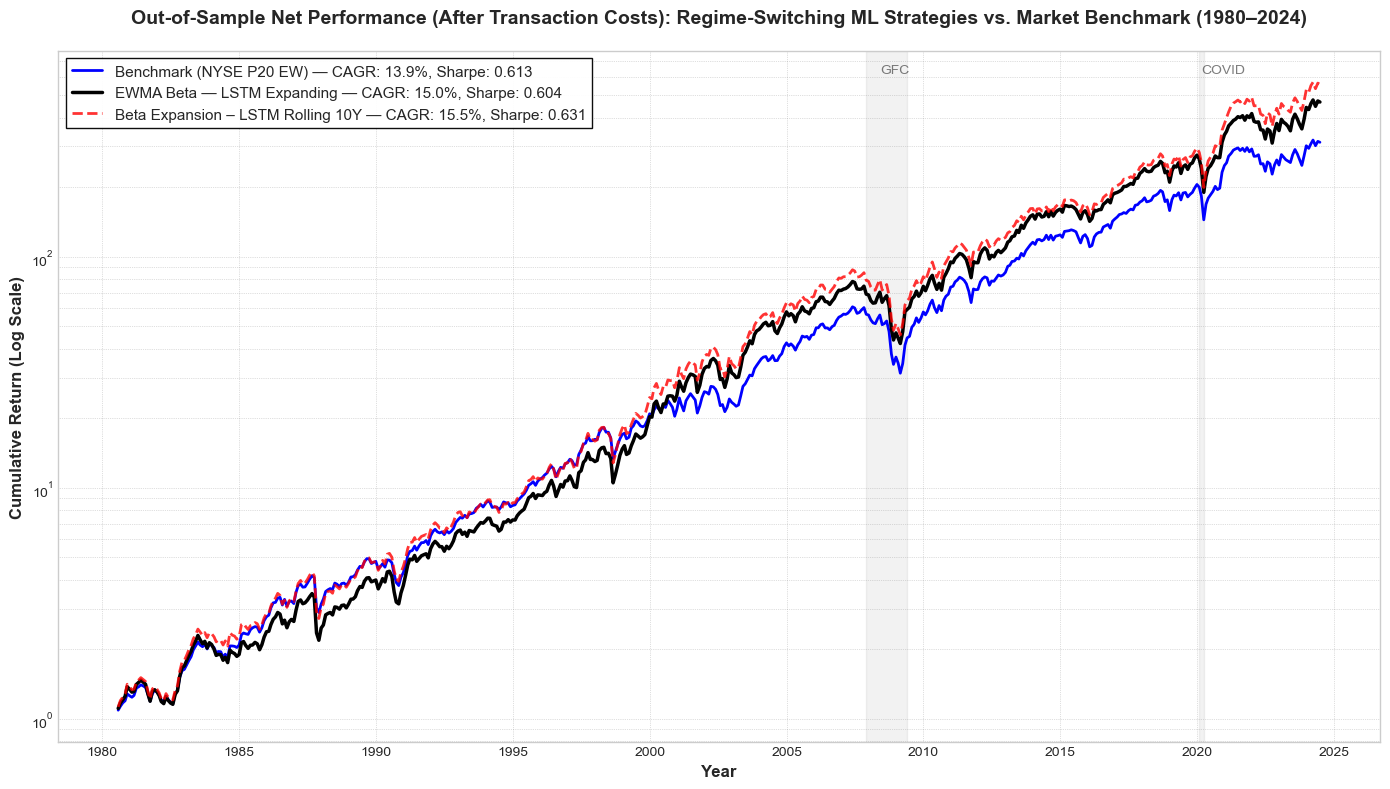

In [108]:
# ════════════════════════════════════════════════════════════════════════════
# Cell: Graphique Performance - Meilleures Stratégies vs Benchmark
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ════════════════════════════════════════════════════════════════════════════
# STEP 1: Load Data
# ════════════════════════════════════════════════════════════════════════════

# Benchmark (NYSE P20 EW)
df_benchmark = pd.read_parquet('data/ml_data/market/market_returns_ew_nys80.parquet')
df_benchmark = df_benchmark.set_index('date')[['ret_market_ew']].copy()
df_benchmark.columns = ['Benchmark']

# Best: LSTM Expanding + EWMA Beta
df_best_raw = pd.read_parquet('data/ml_data/portfolios/lstm_expanding/portfolio_results_monthly.parquet')
df_best = df_best_raw[
    (df_best_raw['basket'] == 'Basket_4_EWMA_Beta') &
    (df_best_raw['strategy'] == 'Regime-Switching')
].copy()
if 'date' not in df_best.columns:
    df_best = df_best.reset_index()
df_best = df_best.set_index('date')[['portfolio_return']].copy()
df_best.columns = ['Best_Strategy']

# Runner-up: LSTM Rolling + Beta Expansion
df_runner_raw = pd.read_parquet('data/ml_data/portfolios/lstm_rolling_10y/portfolio_results_monthly.parquet')
df_runner = df_runner_raw[
    (df_runner_raw['basket'] == 'Basket_2_Beta_Expansion') &
    (df_runner_raw['strategy'] == 'Regime-Switching')
].copy()
if 'date' not in df_runner.columns:
    df_runner = df_runner.reset_index()
df_runner = df_runner.set_index('date')[['portfolio_return']].copy()
df_runner.columns = ['Runner_Up']

# Transaction Costs
df_tc_raw = pd.read_parquet('data/ml_data/transaction_costs/tc_timeseries_monthly.parquet')
df_tc_june = df_tc_raw[df_tc_raw['date'].dt.month == 6].copy()

# ════════════════════════════════════════════════════════════════════════════
# STEP 2: Process Transaction Costs
# ════════════════════════════════════════════════════════════════════════════

# TC for EWMA Beta (basket_4) - average High + Low
tc_ewma = df_tc_june[df_tc_june['basket'] == 'basket_4'].groupby('date')['total_tc_pct'].mean().reset_index()
tc_ewma.columns = ['date', 'TC_Best']
tc_ewma = tc_ewma.set_index('date')

# TC for Beta Expansion (basket_2) - average High + Low
tc_beta = df_tc_june[df_tc_june['basket'] == 'basket_2'].groupby('date')['total_tc_pct'].mean().reset_index()
tc_beta.columns = ['date', 'TC_Runner']
tc_beta = tc_beta.set_index('date')

# ════════════════════════════════════════════════════════════════════════════
# STEP 3: Merge All Data
# ════════════════════════════════════════════════════════════════════════════

df = df_benchmark.copy()
df = df.merge(df_best, left_index=True, right_index=True, how='outer')
df = df.merge(df_runner, left_index=True, right_index=True, how='outer')
df = df.merge(tc_ewma, left_index=True, right_index=True, how='left')
df = df.merge(tc_beta, left_index=True, right_index=True, how='left')

df['TC_Best'] = df['TC_Best'].fillna(0)
df['TC_Runner'] = df['TC_Runner'].fillna(0)

# Calculate NET returns
df['Best_Strategy_NET'] = df['Best_Strategy'] - (df['TC_Best'] / 100)
df['Runner_Up_NET'] = df['Runner_Up'] - (df['TC_Runner'] / 100)

# Filter period
df = df.loc['1980-07-31':'2024-06-28'].copy()

# ════════════════════════════════════════════════════════════════════════════
# STEP 4: Calculate Cumulative Returns
# ════════════════════════════════════════════════════════════════════════════

df['Benchmark_Cumul'] = (1 + df['Benchmark']).cumprod()
df['Best_Cumul'] = (1 + df['Best_Strategy_NET']).cumprod()
df['Runner_Cumul'] = (1 + df['Runner_Up_NET']).cumprod()

# ════════════════════════════════════════════════════════════════════════════
# STEP 5: Performance Metrics
# ════════════════════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════════════════════
# STEP 3: Performance Metrics (CORRECTE - avec RF comme dans le notebook)
# ════════════════════════════════════════════════════════════════════════════

# ✅ rf_monthly est déjà chargé dans Cell 2 du notebook (ligne 92)
# rf_monthly = ff5.set_index('date')['rf'].sort_index()

# Aligner RF avec les returns
# Align RF exactly to monthly dates (ffill/bfill avoids month-mismatch)
rf_aligned = rf_monthly.reindex(df.index).ffill().bfill()

rf_bench = rf_aligned
rf_best = rf_aligned
rf_runner = rf_aligned

# Calculer excess returns
excess_bench = df['Benchmark'] - rf_bench
excess_best = df['Best_Strategy_NET'] - rf_best
excess_runner = df['Runner_Up_NET'] - rf_runner

# Fonction identique à compute_metrics (Cell 5)
def calc_metrics_with_rf(returns, excess_returns):
    returns = returns.dropna()
    excess_returns = excess_returns.dropna()
    
    if len(returns) == 0:
        return {'Ann. Return': 0, 'CAGR': 0, 'Sharpe': 0}
    
    # Ann. Return (arithmetic mean annualized)
    ann_return = returns.mean() * 12
    
    # CAGR (geometric)
    cumulative = (1 + returns).prod()
    years = len(returns) / 12
    cagr = (cumulative ** (1 / years)) - 1
    
    # ✅ SHARPE = (excess_returns.mean() * 12) / (excess_returns.std() * √12)
    # Exactement comme ligne 277 du notebook Cell 5
    sharpe = (excess_returns.mean() * 12) / (excess_returns.std() * np.sqrt(12)) if excess_returns.std() > 0 else 0
    
    return {'Ann. Return': ann_return * 100, 'CAGR': cagr * 100, 'Sharpe': sharpe}

# Calculer les metrics
metrics_bench = calc_metrics_with_rf(df['Benchmark'].dropna(), excess_bench.dropna())
metrics_best = calc_metrics_with_rf(df['Best_Strategy_NET'].dropna(), excess_best.dropna())
metrics_runner = calc_metrics_with_rf(df['Runner_Up_NET'].dropna(), excess_runner.dropna())

print('='*100)
print('PERFORMANCE METRICS (1980-2024)')
print('='*100)
print(f"\nBenchmark (NYSE P20 EW):                 Ann.Ret = {metrics_bench['Ann. Return']:6.2f}%  |  CAGR = {metrics_bench['CAGR']:6.2f}%  |  Sharpe = {metrics_bench['Sharpe']:.3f}")
print(f"🥇 EWMA Beta – LSTM Expanding:           Ann.Ret = {metrics_best['Ann. Return']:6.2f}%  |  CAGR = {metrics_best['CAGR']:6.2f}%  |  Sharpe = {metrics_best['Sharpe']:.3f}")
print(f"🥈 Beta Expansion – LSTM Rolling 10Y:    Ann.Ret = {metrics_runner['Ann. Return']:6.2f}%  |  CAGR = {metrics_runner['CAGR']:6.2f}%  |  Sharpe = {metrics_runner['Sharpe']:.3f}")

# ════════════════════════════════════════════════════════════════════════════
# STEP 6: Plot
# ════════════════════════════════════════════════════════════════════════════

plt.figure(figsize=(14, 8))
plt.style.use('seaborn-v0_8-whitegrid')

plt.semilogy(df.index, df['Benchmark_Cumul'],
            color='blue', linestyle='-', linewidth=2,
            label=f"Benchmark (NYSE P20 EW) — CAGR: {metrics_bench['CAGR']:.1f}%, Sharpe: {metrics_bench['Sharpe']:.3f}")


plt.semilogy(df.index, df['Best_Cumul'],
            color='black', linestyle='-', linewidth=2.5,
           label=f"EWMA Beta — LSTM Expanding — CAGR: {metrics_best['CAGR']:.1f}%, Sharpe: {metrics_best['Sharpe']:.3f}")


plt.semilogy(df.index, df['Runner_Cumul'],
            color='red', linestyle='--', linewidth=2.0,
            label=f"Beta Expansion – LSTM Rolling 10Y — CAGR: {metrics_runner['CAGR']:.1f}%, Sharpe: {metrics_runner['Sharpe']:.3f}", alpha=0.8)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Cumulative Return (Log Scale)', fontsize=12, fontweight='bold')
plt.title(
    "Out-of-Sample Net Performance (After Transaction Costs): "
    "Regime-Switching ML Strategies vs. Market Benchmark (1980–2024)",
    fontsize=14, fontweight='bold', pad=20
)


plt.legend(loc='upper left', frameon=True, fancybox=False, shadow=False,
          fontsize=11, framealpha=0.95, edgecolor='black')
plt.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.5, color='gray')
plt.axvspan('2007-12-01', '2009-06-01', alpha=0.1, color='gray')
plt.axvspan('2020-02-01', '2020-04-01', alpha=0.1, color='gray')
plt.tight_layout()

plt.text(pd.Timestamp('2008-06-01'), plt.ylim()[1]*0.8, "GFC", fontsize=10, alpha=0.6)
plt.text(pd.Timestamp('2020-03-01'), plt.ylim()[1]*0.8, "COVID", fontsize=10, alpha=0.6)


output_dir = Path('results/latex/results')
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / '00_FIG_results_performance_best_strategies.png', dpi=300, bbox_inches='tight', facecolor='white')


print(f"\n✅ Saved: results/latex/results/00_FIG_results_performance_best_strategies.png")

plt.show()


#### Export Baskets Gross and Net

In [109]:
# ════════════════════════════════════════════════════════════════════════════
# Cell FINAL: Export Monthly Returns by Strategy × Basket (GROSS + NET)
# ════════════════════════════════════════════════════════════════════════════

print('='*120)
print('EXPORT FINAL: MONTHLY RETURNS BY STRATEGY × BASKET (BUY&HOLD ONLY)')
print('='*120)

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: Prepare GROSS Returns (Buy&Hold Offensive/Defensive)
# ────────────────────────────────────────────────────────────────────────────

# ✅ FILTER TO BUY&HOLD STRATEGIES ONLY
df_export_gross = df_all[
    df_all['strategy'].isin(['Buy&Hold Offensive', 'Buy&Hold Defensive'])
].copy()

df_export_gross = df_export_gross.reset_index()

# Average across all 5 models
df_gross_agg = df_export_gross.groupby(['date', 'basket', 'strategy']).agg({
    'portfolio_return': 'mean'
}).reset_index()

df_gross_agg = df_gross_agg.rename(columns={'portfolio_return': 'return_gross'})

print(f"✅ GROSS returns prepared: {len(df_gross_agg)} rows")
print(f"   Strategies: {sorted(df_gross_agg['strategy'].unique())}")
print(f"   Baskets: {sorted(df_gross_agg['basket'].unique())}")
print(f"   Period: {df_gross_agg['date'].min().date()} → {df_gross_agg['date'].max().date()}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: Prepare NET Returns (GROSS - TC)
# ────────────────────────────────────────────────────────────────────────────

# Use df_buyhold_with_tc (from Cell 8.5)
df_export_net = df_buyhold_with_tc.copy()
df_export_net = df_export_net.reset_index()

# Average across all 5 models
df_net_agg = df_export_net.groupby(['date', 'basket', 'strategy']).agg({
    'portfolio_return_net': 'mean'
}).reset_index()

df_net_agg = df_net_agg.rename(columns={'portfolio_return_net': 'return_net'})

print(f"✅ NET returns prepared: {len(df_net_agg)} rows")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: Merge GROSS + NET
# ────────────────────────────────────────────────────────────────────────────

df_final = df_gross_agg.merge(
    df_net_agg[['date', 'basket', 'strategy', 'return_net']],
    on=['date', 'basket', 'strategy'],
    how='left'
)

df_final['return_net'] = df_final['return_net'].fillna(df_final['return_gross'])

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: Add Metadata
# ────────────────────────────────────────────────────────────────────────────

df_final['year'] = pd.to_datetime(df_final['date']).dt.year
df_final['month'] = pd.to_datetime(df_final['date']).dt.month

df_final = df_final.sort_values(['basket', 'strategy', 'date']).reset_index(drop=True)

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: Display Preview
# ────────────────────────────────────────────────────────────────────────────

print('\n' + '='*120)
print('📊 PREVIEW: First 20 rows')
print('='*120)
print(df_final.head(20).to_string(index=False))

print('\n' + '='*120)
print('📊 SUMMARY STATISTICS')
print('='*120)

print("\nMean Monthly Returns by Strategy (GROSS):")
print(df_final.groupby('strategy')['return_gross'].mean().apply(lambda x: f"{x:.4f}"))

print("\nMean Monthly Returns by Strategy (NET):")
print(df_final.groupby('strategy')['return_net'].mean().apply(lambda x: f"{x:.4f}"))

# ────────────────────────────────────────────────────────────────────────────
# STEP 6: Export to Parquet
# ────────────────────────────────────────────────────────────────────────────

output_dir = Path('data/results')
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / 'monthly_returns_by_strategy_basket.parquet'
df_final.to_parquet(output_file, index=False)

print('\n' + '='*120)
print('✅ EXPORT COMPLETE (BUY&HOLD ONLY)')
print('='*120)
print(f"📄 File: {output_file}")
print(f"📊 Strategies: {sorted(df_final['strategy'].unique())}")
print(f"📈 Shape: {df_final.shape}")
print('='*120)

EXPORT FINAL: MONTHLY RETURNS BY STRATEGY × BASKET (BUY&HOLD ONLY)
✅ GROSS returns prepared: 5280 rows
   Strategies: ['Buy&Hold Defensive', 'Buy&Hold Offensive']
   Baskets: ['Basket_1_Economic', 'Basket_2_Beta_Expansion', 'Basket_3_Rolling_Beta', 'Basket_4_EWMA_Beta', 'Basket_5_Kalman_Beta']
   Period: 1980-07-31 → 2024-06-28
✅ NET returns prepared: 5280 rows

📊 PREVIEW: First 20 rows
      date            basket           strategy  return_gross  return_net  year  month
1980-07-31 Basket_1_Economic Buy&Hold Defensive      0.121380    0.121380  1980      7
1980-08-29 Basket_1_Economic Buy&Hold Defensive      0.057411    0.057411  1980      8
1980-09-30 Basket_1_Economic Buy&Hold Defensive      0.034484    0.034484  1980      9
1980-10-31 Basket_1_Economic Buy&Hold Defensive      0.022163    0.022163  1980     10
1980-11-28 Basket_1_Economic Buy&Hold Defensive      0.086878    0.086878  1980     11
1980-12-31 Basket_1_Economic Buy&Hold Defensive     -0.018242   -0.018242  1980     12
1

### Export ML Strategies by baskets - Gross Net

In [110]:
# ════════════════════════════════════════════════════════════════════════════
# Cell: Export ML Performance by Strategy × Basket (GROSS + NET)
# ════════════════════════════════════════════════════════════════════════════

print('='*120)
print('EXPORT ML PERFORMANCE: MONTHLY RETURNS BY MODEL × STRATEGY × BASKET (GROSS + NET)')
print('='*120)

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: Prepare GROSS Returns (All Models × Baskets × Regime-Switching)
# ────────────────────────────────────────────────────────────────────────────

df_export_ml_gross = df_regime.copy()  # Already filtered to Regime-Switching in Cell 2
df_export_ml_gross = df_export_ml_gross.reset_index()

# Keep all models separately (no averaging)
df_ml_gross = df_export_ml_gross[['date', 'basket', 'strategy', 'model', 'portfolio_return']].copy()
df_ml_gross = df_ml_gross.rename(columns={'portfolio_return': 'return_gross'})

print(f"✅ ML GROSS returns prepared: {len(df_ml_gross)} rows")
print(f"   Models: {sorted(df_ml_gross['model'].unique())}")
print(f"   Baskets: {sorted(df_ml_gross['basket'].unique())}")
print(f"   Period: {df_ml_gross['date'].min().date()} → {df_ml_gross['date'].max().date()}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: Prepare NET Returns (GROSS - TC)
# ────────────────────────────────────────────────────────────────────────────

df_export_ml_net = df_regime_with_tc.copy()  # Already merged with TC in Cell 7 v3
df_export_ml_net = df_export_ml_net.reset_index()

df_ml_net = df_export_ml_net[['date', 'basket', 'strategy', 'model', 'portfolio_return_net']].copy()
df_ml_net = df_ml_net.rename(columns={'portfolio_return_net': 'return_net'})

print(f"✅ ML NET returns prepared: {len(df_ml_net)} rows")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: Merge GROSS + NET
# ────────────────────────────────────────────────────────────────────────────

df_ml_final = df_ml_gross.merge(
    df_ml_net[['date', 'basket', 'strategy', 'model', 'return_net']],
    on=['date', 'basket', 'strategy', 'model'],
    how='left'
)

# Fill missing NET with GROSS (for safety)
df_ml_final['return_net'] = df_ml_final['return_net'].fillna(df_ml_final['return_gross'])

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: Add Metadata
# ────────────────────────────────────────────────────────────────────────────

df_ml_final['year'] = pd.to_datetime(df_ml_final['date']).dt.year
df_ml_final['month'] = pd.to_datetime(df_ml_final['date']).dt.month

# Sort
df_ml_final = df_ml_final.sort_values(['model', 'basket', 'strategy', 'date']).reset_index(drop=True)

# Reorder columns for clarity
df_ml_final = df_ml_final[['date', 'basket', 'strategy', 'model', 'return_gross', 'return_net', 'year', 'month']]

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: Display Preview
# ────────────────────────────────────────────────────────────────────────────

print('\n' + '='*120)
print('📊 PREVIEW: First 20 rows')
print('='*120)
print(df_ml_final.head(20).to_string(index=False))

print('\n' + '='*120)
print('📊 SUMMARY STATISTICS')
print('='*120)

# Stats by model
print("\nMean Monthly Returns by Model (GROSS):")
print(df_ml_final.groupby('model')['return_gross'].mean().apply(lambda x: f"{x:.6f}"))

print("\nMean Monthly Returns by Model (NET):")
print(df_ml_final.groupby('model')['return_net'].mean().apply(lambda x: f"{x:.6f}"))

# Stats by basket
print("\nMean Monthly Returns by Basket (GROSS):")
print(df_ml_final.groupby('basket')['return_gross'].mean().apply(lambda x: f"{x:.6f}"))

print("\nMean Monthly Returns by Basket (NET):")
print(df_ml_final.groupby('basket')['return_net'].mean().apply(lambda x: f"{x:.6f}"))

# Overall stats
print(f"\n📈 Dataset Overview:")
print(f"   • Total rows: {len(df_ml_final):,}")
print(f"   • Models: {df_ml_final['model'].nunique()}")
print(f"   • Baskets: {df_ml_final['basket'].nunique()}")
print(f"   • Strategies: {df_ml_final['strategy'].nunique()}")
print(f"   • Date range: {df_ml_final['date'].min().date()} → {df_ml_final['date'].max().date()}")
print(f"   • Months: {df_ml_final['date'].nunique()}")

# Check completeness
expected_rows = (df_ml_final['model'].nunique() * 
                df_ml_final['basket'].nunique() * 
                df_ml_final['strategy'].nunique() * 
                df_ml_final['date'].nunique())
print(f"   • Expected rows (model × basket × strategy × date): {expected_rows:,}")
print(f"   • Actual rows: {len(df_ml_final):,}")
print(f"   • Completeness: {len(df_ml_final)/expected_rows*100:.1f}%")

# ────────────────────────────────────────────────────────────────────────────
# STEP 6: Export to Parquet
# ────────────────────────────────────────────────────────────────────────────

output_dir = Path('data/results')
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / 'monthly_returns_ml_by_model_basket.parquet'
df_ml_final.to_parquet(output_file, index=False)

print('\n' + '='*120)
print('✅ ML EXPORT COMPLETE')
print('='*120)
print(f"📄 File: {output_file}")
print(f"📊 Columns: {list(df_ml_final.columns)}")
print(f"📈 Shape: {df_ml_final.shape}")
print('='*120)

EXPORT ML PERFORMANCE: MONTHLY RETURNS BY MODEL × STRATEGY × BASKET (GROSS + NET)
✅ ML GROSS returns prepared: 13200 rows
   Models: ['LSTM Expanding', 'LSTM Rolling 10Y', 'Logistic L2', 'Random Forest', 'XGBoost']
   Baskets: ['Basket_1_Economic', 'Basket_2_Beta_Expansion', 'Basket_3_Rolling_Beta', 'Basket_4_EWMA_Beta', 'Basket_5_Kalman_Beta']
   Period: 1980-07-31 → 2024-06-28
✅ ML NET returns prepared: 13200 rows

📊 PREVIEW: First 20 rows
      date            basket         strategy          model  return_gross  return_net  year  month
1980-07-31 Basket_1_Economic Regime-Switching LSTM Expanding      0.142768    0.142768  1980      7
1980-08-29 Basket_1_Economic Regime-Switching LSTM Expanding      0.067738    0.067738  1980      8
1980-09-30 Basket_1_Economic Regime-Switching LSTM Expanding      0.026664    0.026664  1980      9
1980-10-31 Basket_1_Economic Regime-Switching LSTM Expanding      0.040165    0.040165  1980     10
1980-11-28 Basket_1_Economic Regime-Switching LSTM Exp

In [111]:
# ════════════════════════════════════════════════════════════════════════════
# Cell: EXPORT Transaction Costs & Turnover (Stock + Inter-Basket)
# ════════════════════════════════════════════════════════════════════════════

print('='*120)
print('EXPORT: TRANSACTION COSTS & TURNOVER BY BASKET')
print('='*120)

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: Load & Prepare Transaction Costs Data
# ────────────────────────────────────────────────────────────────────────────

df_tc_export = pd.read_parquet('data/ml_data/transaction_costs/tc_timeseries_monthly.parquet')
df_tc_export['date'] = pd.to_datetime(df_tc_export['date'])

# Filter to match portfolio date range
df_tc_export = df_tc_export[
    (df_tc_export['date'] >= '1980-07-31') & 
    (df_tc_export['date'] <= '2024-06-28')
]

# Filter to June only (Fama-French convention)
df_tc_export = df_tc_export[df_tc_export['date'].dt.month == 6].copy()

print(f"✅ TC data loaded: {len(df_tc_export)} observations (June only)")
print(f"   Period: {df_tc_export['date'].min().date()} → {df_tc_export['date'].max().date()}")
print(f"   Baskets: {sorted(df_tc_export['basket'].unique())}")
print(f"   Strategies: {sorted(df_tc_export['strategy'].unique())}")

# Add year/month
df_tc_export['year'] = df_tc_export['date'].dt.year
df_tc_export['month'] = df_tc_export['date'].dt.month

# Reorder columns
df_tc_export = df_tc_export[[
    'date', 'basket', 'strategy', 
    'stock_tc_pct', 'inter_tc_pct', 'total_tc_pct',
    'year', 'month'
]].copy()

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: Load & Prepare Turnover Data
# ────────────────────────────────────────────────────────────────────────────

# Turnover data is already computed in Cell 15 (df_turnover_basket)
# We need to recreate it here for export

df_turnover_export = df_turnover_basket.copy()

# Keep only relevant columns
df_turnover_export = df_turnover_export[[
    'date', 'basket', 
    'turnover_stock', 'turnover_inter', 'turnover_total',
    'year', 'period'
]].copy()

# Add month
df_turnover_export['month'] = pd.to_datetime(df_turnover_export['date']).dt.month

print(f"\n✅ Turnover data prepared: {len(df_turnover_export)} observations (June only)")
print(f"   Period: {df_turnover_export['date'].min().date()} → {df_turnover_export['date'].max().date()}")
print(f"   Baskets: {sorted(df_turnover_export['basket'].unique())}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: Preview Data
# ────────────────────────────────────────────────────────────────────────────

print('\n' + '='*120)
print('📊 PREVIEW: Transaction Costs (First 10 rows)')
print('='*120)
print(df_tc_export.head(10).to_string(index=False))

print('\n' + '='*120)
print('📊 PREVIEW: Turnover (First 10 rows)')
print('='*120)
print(df_turnover_export.head(10).to_string(index=False))

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: Summary Statistics
# ────────────────────────────────────────────────────────────────────────────

print('\n' + '='*120)
print('📊 SUMMARY STATISTICS')
print('='*120)

# TC by basket (mean)
print("\n🔹 Transaction Costs by Basket (Mean, in %):")
tc_summary = df_tc_export.groupby('basket').agg({
    'stock_tc_pct': 'mean',
    'inter_tc_pct': 'mean',
    'total_tc_pct': 'mean'
}).round(4)
print(tc_summary)

# Turnover by basket (mean)
print("\n🔹 Turnover by Basket (Mean, in %):")
turn_summary = df_turnover_export.groupby('basket').agg({
    'turnover_stock': 'mean',
    'turnover_inter': 'mean',
    'turnover_total': 'mean'
}).round(2)
print(turn_summary)

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: Export to Parquet
# ────────────────────────────────────────────────────────────────────────────

output_dir = Path('data/results')
output_dir.mkdir(parents=True, exist_ok=True)

# Export TC
tc_file = output_dir / 'transaction_costs_monthly_june.parquet'
df_tc_export.to_parquet(tc_file, index=False)

# Export Turnover
turnover_file = output_dir / 'turnover_monthly_june.parquet'
df_turnover_export.to_parquet(turnover_file, index=False)

print('\n' + '='*120)
print('✅ EXPORT COMPLETE')
print('='*120)
print(f"📄 Transaction Costs: {tc_file}")
print(f"   • Shape: {df_tc_export.shape}")
print(f"   • Columns: {list(df_tc_export.columns)}")
print(f"\n📄 Turnover: {turnover_file}")
print(f"   • Shape: {df_turnover_export.shape}")
print(f"   • Columns: {list(df_turnover_export.columns)}")
print('='*120)

EXPORT: TRANSACTION COSTS & TURNOVER BY BASKET
✅ TC data loaded: 440 observations (June only)
   Period: 1981-06-30 → 2024-06-28
   Baskets: ['basket_1', 'basket_2', 'basket_3', 'basket_4', 'basket_5']
   Strategies: ['Defensive', 'High_Beta', 'Low_Beta', 'Offensive']

✅ Turnover data prepared: 220 observations (June only)
   Period: 1981-06-30 → 2024-06-28
   Baskets: ['basket_1', 'basket_2', 'basket_3', 'basket_4', 'basket_5']

📊 PREVIEW: Transaction Costs (First 10 rows)
      date   basket  strategy  stock_tc_pct  inter_tc_pct  total_tc_pct  year  month
1981-06-30 basket_1 Offensive      0.108932           0.0      0.108932  1981      6
1982-06-30 basket_1 Offensive      1.428988           0.0      1.428988  1982      6
1983-06-30 basket_1 Offensive      0.150150           0.0      0.150150  1983      6
1984-06-29 basket_1 Offensive      1.024623           0.0      1.024623  1984      6
1985-06-28 basket_1 Offensive      1.120073           0.0      1.120073  1985      6
1986-06-30 

In [112]:
# ════════════════════════════════════════════════════════════════════════════
# Cell: ASSERTIONS - Verify TC & Turnover Exports
# ════════════════════════════════════════════════════════════════════════════

print('='*120)
print('VERIFICATION: TRANSACTION COSTS & TURNOVER EXPORTS')
print('='*120)

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: Reload Exported Files
# ────────────────────────────────────────────────────────────────────────────

df_tc_reloaded = pd.read_parquet('data/results/transaction_costs_monthly_june.parquet')
df_turn_reloaded = pd.read_parquet('data/results/turnover_monthly_june.parquet')

print(f"\n✅ Files reloaded:")
print(f"   • TC: {df_tc_reloaded.shape}")
print(f"   • Turnover: {df_turn_reloaded.shape}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: Structural Assertions
# ────────────────────────────────────────────────────────────────────────────

print('\n' + '─'*120)
print('🔍 STRUCTURAL CHECKS')
print('─'*120)

# TC assertions
assert 'date' in df_tc_reloaded.columns, "❌ Missing 'date' column in TC"
assert 'basket' in df_tc_reloaded.columns, "❌ Missing 'basket' column in TC"
assert 'stock_tc_pct' in df_tc_reloaded.columns, "❌ Missing 'stock_tc_pct' column"
assert 'inter_tc_pct' in df_tc_reloaded.columns, "❌ Missing 'inter_tc_pct' column"
assert 'total_tc_pct' in df_tc_reloaded.columns, "❌ Missing 'total_tc_pct' column"
print("✅ TC: All required columns present")

# Turnover assertions
assert 'date' in df_turn_reloaded.columns, "❌ Missing 'date' column in Turnover"
assert 'basket' in df_turn_reloaded.columns, "❌ Missing 'basket' column in Turnover"
assert 'turnover_stock' in df_turn_reloaded.columns, "❌ Missing 'turnover_stock' column"
assert 'turnover_inter' in df_turn_reloaded.columns, "❌ Missing 'turnover_inter' column"
assert 'turnover_total' in df_turn_reloaded.columns, "❌ Missing 'turnover_total' column"
print("✅ Turnover: All required columns present")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: Date Range Assertions
# ────────────────────────────────────────────────────────────────────────────

print('\n' + '─'*120)
print('📅 DATE RANGE CHECKS')
print('─'*120)

# TC date range
tc_min = pd.to_datetime(df_tc_reloaded['date'].min())
tc_max = pd.to_datetime(df_tc_reloaded['date'].max())
assert tc_min >= pd.Timestamp('1980-07-31'), f"❌ TC start date too early: {tc_min}"
assert tc_max <= pd.Timestamp('2024-06-28'), f"❌ TC end date too late: {tc_max}"
print(f"✅ TC date range: {tc_min.date()} → {tc_max.date()}")

# Turnover date range
turn_min = pd.to_datetime(df_turn_reloaded['date'].min())
turn_max = pd.to_datetime(df_turn_reloaded['date'].max())
assert turn_min >= pd.Timestamp('1980-07-31'), f"❌ Turnover start date too early: {turn_min}"
assert turn_max <= pd.Timestamp('2024-06-28'), f"❌ Turnover end date too late: {turn_max}"
print(f"✅ Turnover date range: {turn_min.date()} → {turn_max.date()}")

# June-only assertion
tc_months = pd.to_datetime(df_tc_reloaded['date']).dt.month.unique()
assert len(tc_months) == 1 and tc_months[0] == 6, f"❌ TC not June-only: {tc_months}"
print("✅ TC: June-only confirmed")

turn_months = pd.to_datetime(df_turn_reloaded['date']).dt.month.unique()
assert len(turn_months) == 1 and turn_months[0] == 6, f"❌ Turnover not June-only: {turn_months}"
print("✅ Turnover: June-only confirmed")

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: Value Range Assertions
# ────────────────────────────────────────────────────────────────────────────

print('\n' + '─'*120)
print('📊 VALUE RANGE CHECKS')
print('─'*120)

# TC should be positive and reasonable (< 10% per year)
assert (df_tc_reloaded['stock_tc_pct'] >= 0).all(), "❌ Negative stock TC found"
assert (df_tc_reloaded['stock_tc_pct'] < 10).all(), "❌ Stock TC exceeds 10%"
assert (df_tc_reloaded['inter_tc_pct'] >= 0).all(), "❌ Negative inter TC found"
assert (df_tc_reloaded['total_tc_pct'] >= 0).all(), "❌ Negative total TC found"
print("✅ TC: All values in valid range (0-10%)")

# Turnover should be positive and reasonable (< 500%)
assert (df_turn_reloaded['turnover_stock'] >= 0).all(), "❌ Negative stock turnover found"
assert (df_turn_reloaded['turnover_stock'] < 500).all(), "❌ Stock turnover exceeds 500%"
assert (df_turn_reloaded['turnover_inter'] >= 0).all(), "❌ Negative inter turnover found"
assert (df_turn_reloaded['turnover_total'] >= 0).all(), "❌ Negative total turnover found"
print("✅ Turnover: All values in valid range (0-500%)")

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: Consistency Checks
# ────────────────────────────────────────────────────────────────────────────

print('\n' + '─'*120)
print('🔗 CONSISTENCY CHECKS')
print('─'*120)

# TC: total = stock + inter
tc_total_check = np.allclose(
    df_tc_reloaded['total_tc_pct'],
    df_tc_reloaded['stock_tc_pct'] + df_tc_reloaded['inter_tc_pct'],
    rtol=1e-5
)
assert tc_total_check, "❌ TC: total ≠ stock + inter"
print("✅ TC: total_tc = stock_tc + inter_tc")

# Turnover: total = stock + inter
turn_total_check = np.allclose(
    df_turn_reloaded['turnover_total'],
    df_turn_reloaded['turnover_stock'] + df_turn_reloaded['turnover_inter'],
    rtol=1e-3
)
assert turn_total_check, "❌ Turnover: total ≠ stock + inter"
print("✅ Turnover: turnover_total = turnover_stock + turnover_inter")

# Basket 1 should have inter_tc = 0 (Economic basket, no High/Low switching)
basket1_tc = df_tc_reloaded[df_tc_reloaded['basket'] == 'basket_1']
assert (basket1_tc['inter_tc_pct'] == 0).all(), "❌ Basket 1 has non-zero inter_tc"
print("✅ Basket 1: inter_tc = 0 (Economic basket)")

# Basket 1 should have inter_turnover = 0
basket1_turn = df_turn_reloaded[df_turn_reloaded['basket'] == 'basket_1']
assert (basket1_turn['turnover_inter'] == 0).all(), "❌ Basket 1 has non-zero inter_turnover"
print("✅ Basket 1: turnover_inter = 0 (Economic basket)")

# ────────────────────────────────────────────────────────────────────────────
# STEP 6: Completeness Checks
# ────────────────────────────────────────────────────────────────────────────

print('\n' + '─'*120)
print('📋 COMPLETENESS CHECKS')
print('─'*120)

# Number of years (1980-2024 = 44 complete years + partial 1980/2024)
expected_years = len(range(1981, 2024))  # 43 years (1981-2023 inclusive)
tc_years = len(df_tc_reloaded['year'].unique())
turn_years = len(df_turn_reloaded['year'].unique())

print(f"   • TC years: {tc_years} (expected ≥ {expected_years})")
print(f"   • Turnover years: {turn_years} (expected ≥ {expected_years})")
assert tc_years >= expected_years - 2, f"❌ TC missing years"
assert turn_years >= expected_years - 2, f"❌ Turnover missing years"
print("✅ Reasonable number of years covered")

# ────────────────────────────────────────────────────────────────────────────
# STEP 7: Summary Table
# ────────────────────────────────────────────────────────────────────────────

print('\n' + '='*120)
print('📊 VERIFICATION SUMMARY')
print('='*120)

summary_data = []

for basket in sorted(df_tc_reloaded['basket'].unique()):
    tc_data = df_tc_reloaded[df_tc_reloaded['basket'] == basket]
    turn_data = df_turn_reloaded[df_turn_reloaded['basket'] == basket]
    
    summary_data.append({
        'Basket': basket,
        'TC Obs': len(tc_data),
        'Turn Obs': len(turn_data),
        'Mean Stock TC (%)': tc_data['stock_tc_pct'].mean(),
        'Mean Inter TC (%)': tc_data['inter_tc_pct'].mean(),
        'Mean Stock Turn (%)': turn_data['turnover_stock'].mean(),
        'Mean Inter Turn (%)': turn_data['turnover_inter'].mean()
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print('\n' + '='*120)
print('✅ ALL ASSERTIONS PASSED')
print('='*120)
print('   • Structural integrity: ✓')
print('   • Date ranges: ✓')
print('   • Value ranges: ✓')
print('   • Consistency checks: ✓')
print('   • Completeness: ✓')
print('='*120)

VERIFICATION: TRANSACTION COSTS & TURNOVER EXPORTS

✅ Files reloaded:
   • TC: (440, 8)
   • Turnover: (220, 8)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
🔍 STRUCTURAL CHECKS
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
✅ TC: All required columns present
✅ Turnover: All required columns present

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📅 DATE RANGE CHECKS
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
✅ TC date range: 1981-06-30 → 2024-06-28
✅ Turnover date range: 1981-06-30 → 2024-06-28
✅ TC: June-only confirmed
✅ Turnover: June-only confirmed

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 VALUE RANGE CHEC

# Breaking point TC

In [113]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: BREAK-EVEN TRANSACTION COST ANALYSIS (CORRECTED - SIMPLE FORMULA)
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

print("=" * 120)
print("BREAK-EVEN TRANSACTION COST ANALYSIS (NET RETURNS - REAL TC)")
print("=" * 120)

# ────────────────────────────────────────────────────────────────────────────
# STEP 0: Basket Mapping & Display Names
# ────────────────────────────────────────────────────────────────────────────

BASKET_MAPPING = {
    'Basket_1_Economic': 'basket_1',
    'Basket_2_Beta_Expansion': 'basket_2',
    'Basket_3_Rolling_Beta': 'basket_3',
    'Basket_4_EWMA_Beta': 'basket_4',
    'Basket_5_Kalman_Beta': 'basket_5'
}

BASKET_NAMES_DISPLAY = {
    'Basket_1_Economic': 'Economic',
    'Basket_2_Beta_Expansion': 'Beta Expansion',
    'Basket_3_Rolling_Beta': 'Rolling Beta',
    'Basket_4_EWMA_Beta': 'EWMA Beta',
    'Basket_5_Kalman_Beta': 'Kalman Beta'
}

MODEL_NAMES_DISPLAY = {
    'logistic': 'Logistic',
    'random_forest': 'Random Forest',
    'xgboost': 'XGBoost',
    'lstm_expanding': 'LSTM-Exp',
    'lstm_rolling_10y': 'LSTM-Roll'
}

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: Load Data
# ────────────────────────────────────────────────────────────────────────────

df_ml = pd.read_parquet('data/results/monthly_returns_ml_by_model_basket.parquet')
df_turnover = pd.read_parquet('data/results/turnover_monthly_june.parquet')
df_tc = pd.read_parquet('data/ml_data/transaction_costs/tc_timeseries_monthly.parquet')

print(f"✅ Data loaded: ML={len(df_ml)}, Turnover={len(df_turnover)}, TC={len(df_tc)}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: Best Performers (by mean NET return)
# ────────────────────────────────────────────────────────────────────────────

df_ml['date'] = pd.to_datetime(df_ml['date'])

best_performers = (df_ml.groupby(['basket', 'model'])['return_net']
                   .mean()
                   .reset_index()
                   .loc[lambda x: x.groupby('basket')['return_net'].idxmax()])

print(f"\n✅ Best performers identified:")
for _, row in best_performers.iterrows():
    print(f"   • {row['basket']}: {row['model']} (NET: {row['return_net']*100:.4f}%)")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: Mean Returns (NET & GROSS)
# ────────────────────────────────────────────────────────────────────────────

df_ml_best = df_ml.merge(best_performers[['basket', 'model']], on=['basket', 'model'], how='inner')

df_ml_mean = df_ml_best.groupby(['basket', 'model']).agg({
    'return_net': 'mean',
    'return_gross': 'mean'
}).reset_index()

print(f"\n✅ Mean returns (monthly):")
for _, row in df_ml_mean.iterrows():
    print(f"   • {row['basket']}: NET={row['return_net']*100:.4f}%, GROSS={row['return_gross']*100:.4f}%")

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: Turnover (Stock + Inter)
# ────────────────────────────────────────────────────────────────────────────

df_turnover_mean = df_turnover.groupby('basket').agg({
    'turnover_stock': 'mean',
    'turnover_inter': 'mean',
    'turnover_total': 'mean'
}).reset_index()

print(f"\n✅ Turnover (annual %):")
for _, row in df_turnover_mean.iterrows():
    print(f"   • {row['basket']}: Total={row['turnover_total']:.2f}% (Stock={row['turnover_stock']:.2f}% + Inter={row['turnover_inter']:.2f}%)")

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: Real TC (from file)
# ────────────────────────────────────────────────────────────────────────────

df_tc_regime = df_tc[
    (df_tc['strategy'] == 'Regime-Switching') |
    (df_tc['strategy'] == 'Offensive') |
    (df_tc['strategy'] == 'High_Beta')
].copy()

df_tc_mean = df_tc_regime.groupby('basket').agg({
    'stock_tc_pct': 'mean',
    'inter_tc_pct': 'mean',
    'total_tc_pct': 'mean'
}).reset_index()

df_tc_mean['total_tc_annual_pct'] = df_tc_mean['total_tc_pct'] * 12
df_tc_mean['total_tc_annual_bps'] = df_tc_mean['total_tc_annual_pct'] * 100

print(f"\n✅ Real TC applied:")
for _, row in df_tc_mean.iterrows():
    print(f"   • {row['basket']}: {row['total_tc_pct']*100:.4f}% monthly → {row['total_tc_annual_bps']:.2f} bps/year")

# ────────────────────────────────────────────────────────────────────────────
# STEP 6: Break-Even Calculation (CORRECT FORMULA)
# ────────────────────────────────────────────────────────────────────────────

# Market benchmark
market_return_monthly = 0.011479  # From data
market_return_annual = market_return_monthly * 12

print(f"\n✅ Market benchmark: {market_return_monthly*100:.4f}% monthly → {market_return_annual*100:.2f}% annual")

breakeven_results = []

print("\n🔍 Processing break-even calculations...")

for _, row_ml in df_ml_mean.iterrows():
    basket_long = row_ml['basket']
    basket_short = BASKET_MAPPING.get(basket_long)
    model = row_ml['model']

    if basket_short is None:
        continue

    # Returns (monthly → annual)
    ml_return_net = row_ml['return_net']
    ml_return_gross = row_ml['return_gross']
    ml_return_net_annual = ml_return_net * 12
    ml_return_gross_annual = ml_return_gross * 12

    # Turnover
    row_turn = df_turnover_mean[df_turnover_mean['basket'] == basket_short]
    if len(row_turn) == 0:
        continue

    ml_turnover = row_turn.iloc[0]['turnover_total']
    turnover_stock = row_turn.iloc[0]['turnover_stock']
    turnover_inter = row_turn.iloc[0]['turnover_inter']

    # Real TC
    row_tc = df_tc_mean[df_tc_mean['basket'] == basket_short]
    if len(row_tc) > 0:
        real_tc_annual_bps = row_tc.iloc[0]['total_tc_annual_bps']
        real_tc_monthly_pct = row_tc.iloc[0]['total_tc_pct']
    else:
        real_tc_annual_bps = np.nan
        real_tc_monthly_pct = np.nan

    # ═══════════════════════════════════════════════════════════════════════
    # BREAK-EVEN FORMULA (CORRECTED)
    # ═══════════════════════════════════════════════════════════════════════
    
    # Break-even TC = combien de bps/an en plus avant que NET = Market
    # Formula: break_even_bps = (R_net_strategy - R_market) * 10000
    
    outperformance_annual = ml_return_net_annual - market_return_annual  # Decimal
    break_even_tc_bps = outperformance_annual * 10000  # bps/year
    
    # Safety margin = break-even - real TC applied
    margin_bps = break_even_tc_bps - real_tc_annual_bps if not np.isnan(real_tc_annual_bps) else np.nan
    
    # Multiplier = combien de fois les TC actuels avant de casser la surperf
    if not np.isnan(real_tc_annual_bps) and real_tc_annual_bps > 0:
        tc_multiplier = break_even_tc_bps / real_tc_annual_bps
    else:
        tc_multiplier = np.nan
    
    # ═══════════════════════════════════════════════════════════════════════

    # Implied TC rate (from GROSS-NET difference)
    tc_applied_monthly = ml_return_gross - ml_return_net
    if ml_turnover > 0:
        implied_tc_rate_bps = (tc_applied_monthly / (ml_turnover / 100)) * 10000
    else:
        implied_tc_rate_bps = np.nan

    breakeven_results.append({
        'basket': basket_long,
        'model': model,
        'return_gross_monthly_pct': ml_return_gross * 100,
        'return_net_monthly_pct': ml_return_net * 100,
        'return_gross_annual_pct': ml_return_gross_annual * 100,
        'return_net_annual_pct': ml_return_net_annual * 100,
        'outperformance_bps': outperformance_annual * 10000,
        'turnover_stock_pct': turnover_stock,
        'turnover_inter_pct': turnover_inter,
        'turnover_total_pct': ml_turnover,
        'real_tc_monthly_pct': real_tc_monthly_pct * 100 if not np.isnan(real_tc_monthly_pct) else np.nan,
        'real_tc_annual_bps': real_tc_annual_bps,
        'break_even_tc_bps': break_even_tc_bps,
        'margin_bps': margin_bps,
        'tc_multiplier': tc_multiplier,
        'implied_tc_rate_bps': implied_tc_rate_bps
    })

df_breakeven = pd.DataFrame(breakeven_results)

print(f"\n✅ Break-even computed for {len(df_breakeven)} baskets")

# ────────────────────────────────────────────────────────────────────────────
# STEP 7: Display Results
# ────────────────────────────────────────────────────────────────────────────

if len(df_breakeven) > 0:
    print("\n" + "=" * 120)
    print("📊 BREAK-EVEN TRANSACTION COST ANALYSIS")
    print("=" * 120)

    display_data = []
    for _, row in df_breakeven.iterrows():
        basket_name = BASKET_NAMES_DISPLAY.get(row['basket'], row['basket'])
        model_name = MODEL_NAMES_DISPLAY.get(row['model'], row['model'])

        display_data.append({
            'Basket': basket_name,
            'Model': model_name,
            'NET (% p.a.)': f"{row['return_net_annual_pct']:.2f}",
            'Outperf (bps)': f"{row['outperformance_bps']:.0f}",
            'Turnover (%)': f"{row['turnover_total_pct']:.2f}",
            'Real TC (bps/yr)': f"{row['real_tc_annual_bps']:.2f}",
            'Break-Even (bps/yr)': f"{row['break_even_tc_bps']:.0f}",
            'Margin (bps)': f"{row['margin_bps']:+.0f}",
            'TC Multiplier': f"{row['tc_multiplier']:.2f}x"
        })

    df_display = pd.DataFrame(display_data)
    print(df_display.to_string(index=False))

    print("\n" + "=" * 120)
    print("💡 INTERPRETATION")
    print("=" * 120)

    for _, row in df_breakeven.iterrows():
        basket_name = BASKET_NAMES_DISPLAY.get(row['basket'], row['basket'])
        model_name = MODEL_NAMES_DISPLAY.get(row['model'], row['model'])

        print(f"\n{basket_name} ({model_name}):")
        print(f"   • NET Return: {row['return_net_annual_pct']:.2f}% per year")
        print(f"   • Outperformance vs Market: {row['outperformance_bps']:.0f} bps/year")
        print(f"   • Real TC Applied: {row['real_tc_annual_bps']:.2f} bps/year")
        print(f"   • Break-Even TC: {row['break_even_tc_bps']:.0f} bps/year")
        print(f"   • Safety Margin: {row['margin_bps']:+.0f} bps")
        print(f"   • TC Multiplier: {row['tc_multiplier']:.2f}x (can withstand {row['tc_multiplier']:.2f}× current TC)")
        
        if not np.isnan(row['margin_bps']):
            if row['margin_bps'] > 0:
                print(f"   • Status: ✅ ROBUST")
            else:
                print(f"   • Status: ❌ NOT VIABLE")
        else:
            print(f"   • Status: ⚠️  INSUFFICIENT DATA")

    print("\n" + "=" * 120)
    print("📌 NOTES:")
    print("=" * 120)
    print("• Break-Even TC = (NET Return - Market Return) × 10000")
    print("  → How many bps/year of additional TC before NET return = Market")
    print("• Margin = Break-Even TC - Real TC Applied")
    print("  → Positive margin = robust strategy")
    print("• TC Multiplier = Break-Even TC / Real TC")
    print("  → How many times current TC can be multiplied before breaking even")
    print("• Market Benchmark: 13.77% annual")
    print("• Real TC includes: Stock TC (June only) + Inter TC (monthly)")
    print("=" * 120)

else:
    print("\n❌ ERROR: No break-even results computed!")


BREAK-EVEN TRANSACTION COST ANALYSIS (NET RETURNS - REAL TC)
✅ Data loaded: ML=13200, Turnover=220, TC=6970

✅ Best performers identified:
   • Basket_1_Economic: XGBoost (NET: 1.2952%)
   • Basket_2_Beta_Expansion: LSTM Rolling 10Y (NET: 1.3728%)
   • Basket_3_Rolling_Beta: LSTM Rolling 10Y (NET: 1.3613%)
   • Basket_4_EWMA_Beta: LSTM Rolling 10Y (NET: 1.3469%)
   • Basket_5_Kalman_Beta: LSTM Expanding (NET: 1.3529%)

✅ Mean returns (monthly):
   • Basket_1_Economic: NET=1.2952%, GROSS=1.3278%
   • Basket_2_Beta_Expansion: NET=1.3728%, GROSS=1.4041%
   • Basket_3_Rolling_Beta: NET=1.3613%, GROSS=1.3928%
   • Basket_4_EWMA_Beta: NET=1.3469%, GROSS=1.3789%
   • Basket_5_Kalman_Beta: NET=1.3529%, GROSS=1.3847%

✅ Turnover (annual %):
   • basket_1: Total=100.92% (Stock=100.92% + Inter=0.00%)
   • basket_2: Total=115.88% (Stock=115.88% + Inter=0.00%)
   • basket_3: Total=126.62% (Stock=124.07% + Inter=2.55%)
   • basket_4: Total=126.22% (Stock=120.94% + Inter=5.27%)
   • basket_5: Total=1

In [114]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: BREAK-EVEN TC ANALYSIS - LATEX TABLE EXPORT (CORRECTED)
# Output: 09_appendix_A.X_Transaction_Cost_Breakeven.tex
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

print("=" * 120)
print("BREAK-EVEN TC ANALYSIS - LATEX TABLE GENERATION (CORRECTED)")
print("=" * 120)

# ────────────────────────────────────────────────────────────────────────────
# STEP 0: Mappings
# ────────────────────────────────────────────────────────────────────────────

BASKET_MAPPING = {
    'Basket_1_Economic': 'basket_1',
    'Basket_2_Beta_Expansion': 'basket_2',
    'Basket_3_Rolling_Beta': 'basket_3',
    'Basket_4_EWMA_Beta': 'basket_4',
    'Basket_5_Kalman_Beta': 'basket_5'
}

BASKET_NAMES_LATEX = {
    'Basket_1_Economic': 'Economic',
    'Basket_2_Beta_Expansion': 'Beta Exp.',
    'Basket_3_Rolling_Beta': r'Rolling $\beta$',
    'Basket_4_EWMA_Beta': r'EWMA $\beta$',
    'Basket_5_Kalman_Beta': r'Kalman $\beta$'
}

MODEL_NAMES_LATEX = {
    'logistic': 'Logistic',
    'random_forest': 'RF',
    'xgboost': 'XGB',
    'lstm_expanding': 'LSTM-Exp',
    'lstm_rolling_10y': 'LSTM-Roll'
}

MODEL_ORDER = ['logistic', 'random_forest', 'xgboost', 'lstm_expanding', 'lstm_rolling_10y']
BASKET_ORDER = ['Basket_1_Economic', 'Basket_2_Beta_Expansion', 'Basket_3_Rolling_Beta', 
                'Basket_4_EWMA_Beta', 'Basket_5_Kalman_Beta']

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: Load Data
# ────────────────────────────────────────────────────────────────────────────

df_ml = pd.read_parquet('data/results/monthly_returns_ml_by_model_basket.parquet')
df_turnover = pd.read_parquet('data/results/turnover_monthly_june.parquet')
df_tc = pd.read_parquet('data/ml_data/transaction_costs/tc_timeseries_monthly.parquet')

print(f"✅ Data loaded: ML={len(df_ml)}, Turnover={len(df_turnover)}, TC={len(df_tc)}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: Compute Mean Returns for ALL Models
# ────────────────────────────────────────────────────────────────────────────

df_ml['date'] = pd.to_datetime(df_ml['date'])

df_ml_mean = df_ml.groupby(['basket', 'model']).agg({
    'return_net': 'mean',
    'return_gross': 'mean'
}).reset_index()

print(f"\n✅ Mean returns computed for {len(df_ml_mean)} basket-model combinations")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: Turnover & TC Data
# ────────────────────────────────────────────────────────────────────────────

df_turnover_mean = df_turnover.groupby('basket').agg({
    'turnover_stock': 'mean',
    'turnover_inter': 'mean',
    'turnover_total': 'mean'
}).reset_index()

df_tc_regime = df_tc[
    (df_tc['strategy'] == 'Regime-Switching') |
    (df_tc['strategy'] == 'Offensive') |
    (df_tc['strategy'] == 'High_Beta')
].copy()

df_tc_mean = df_tc_regime.groupby('basket').agg({
    'stock_tc_pct': 'mean',
    'inter_tc_pct': 'mean',
    'total_tc_pct': 'mean'
}).reset_index()

df_tc_mean['total_tc_annual_pct'] = df_tc_mean['total_tc_pct'] * 12
df_tc_mean['total_tc_annual_bps'] = df_tc_mean['total_tc_annual_pct'] * 100

print(f"✅ Turnover & TC data aggregated")

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: Calculate Break-Even (CORRECTED FORMULA)
# ────────────────────────────────────────────────────────────────────────────

market_return_monthly = 0.011479
market_return_annual = market_return_monthly * 12

breakeven_results = []

print("\n🔍 Processing break-even calculations...")

for _, row_ml in df_ml_mean.iterrows():
    basket_long = row_ml['basket']
    basket_short = BASKET_MAPPING.get(basket_long)
    model = row_ml['model']

    if basket_short is None:
        continue

    # Returns
    ml_return_net = row_ml['return_net']
    ml_return_net_annual = ml_return_net * 12

    # Turnover
    row_turn = df_turnover_mean[df_turnover_mean['basket'] == basket_short]
    if len(row_turn) == 0:
        continue

    ml_turnover = row_turn.iloc[0]['turnover_total']

    # Real TC
    row_tc = df_tc_mean[df_tc_mean['basket'] == basket_short]
    if len(row_tc) > 0:
        real_tc_annual_bps = row_tc.iloc[0]['total_tc_annual_bps']
    else:
        real_tc_annual_bps = np.nan

    # ═══════════════════════════════════════════════════════════════════════
    # CORRECTED BREAK-EVEN CALCULATION
    # ═══════════════════════════════════════════════════════════════════════
    
    # Headroom = (R_net - R_market) × 10000
    headroom_bps = (ml_return_net_annual - market_return_annual) * 10000
    
    # Total TC at break-even = Real TC + Headroom
    total_tc_at_be_bps = real_tc_annual_bps + headroom_bps if not np.isnan(real_tc_annual_bps) else np.nan
    
    # TC Multiplier (CORRECTED) = Total TC / Real TC = 1 + (Headroom / Real TC)
    if not np.isnan(real_tc_annual_bps) and real_tc_annual_bps > 0:
        tc_multiplier = total_tc_at_be_bps / real_tc_annual_bps
    else:
        tc_multiplier = np.nan
    
    # ═══════════════════════════════════════════════════════════════════════

    breakeven_results.append({
        'basket': basket_long,
        'model': model,
        'return_net_annual_pct': ml_return_net_annual * 100,
        'headroom_bps': headroom_bps,
        'real_tc_annual_bps': real_tc_annual_bps,
        'total_tc_at_be_bps': total_tc_at_be_bps,
        'tc_multiplier': tc_multiplier
    })

df_breakeven = pd.DataFrame(breakeven_results)

print(f"\n✅ Break-even computed for {len(df_breakeven)} strategies")

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: Generate LaTeX Table
# ────────────────────────────────────────────────────────────────────────────

def format_value(val, fmt='%.2f', na_str='--'):
    """Format value with NA handling"""
    if pd.isna(val) or np.isnan(val) or np.isinf(val):
        return na_str
    return fmt % val

def generate_latex_rows(df):
    """Generate LaTeX rows"""
    lines = []
    
    for basket in BASKET_ORDER:
        basket_latex = BASKET_NAMES_LATEX[basket]
        df_basket = df[df['basket'] == basket].copy()
        
        if len(df_basket) == 0:
            continue
        
        # Sort by model order
        df_basket['model_order'] = df_basket['model'].map({m: i for i, m in enumerate(MODEL_ORDER)})
        df_basket = df_basket.sort_values('model_order')
        
        for idx, (_, row) in enumerate(df_basket.iterrows()):
            model_latex = MODEL_NAMES_LATEX.get(row['model'], row['model'])
            
            # First row: basket name
            if idx == 0:
                basket_cell = basket_latex
            else:
                basket_cell = ""
            
            line = f"{basket_cell} & {model_latex} & "
            line += f"{format_value(row['return_net_annual_pct'], '%.2f')} & "
            line += f"{format_value(row['headroom_bps'], '%.0f')} & "
            line += f"{format_value(row['real_tc_annual_bps'], '%.2f')} & "
            line += f"{format_value(row['total_tc_at_be_bps'], '%.0f')} & "
            line += f"{format_value(row['tc_multiplier'], '%.2f')} \\\\"
            
            lines.append(line)
        
        lines.append("\\addlinespace[0.15cm]")
    
    # Remove last addlinespace
    if lines and lines[-1].startswith("\\addlinespace"):
        lines.pop()
    
    return lines

# Generate rows
latex_rows = generate_latex_rows(df_breakeven)

# ────────────────────────────────────────────────────────────────────────────
# STEP 6: Assemble Full LaTeX Table
# ────────────────────────────────────────────────────────────────────────────

latex_table = r"""\begin{table}[htbp]
\centering
\caption{Break-Even Transaction Cost Analysis: All ML Strategies}
\label{tab:appendix_breakeven_tc}
\small
\renewcommand{\arraystretch}{1.2}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l l r r r r r}
\toprule
\textbf{Basket} & \textbf{Model} & \textbf{NET Return} & \textbf{Headroom} & \textbf{Real TC} & \textbf{Total TC @ BE} & \textbf{TC Mult.} \\
 &  & \textbf{(\% p.a.)} & \textbf{(bps/yr)} & \textbf{(bps/yr)} & \textbf{(bps/yr)} & \\
\midrule
"""

# Add rows
latex_table += "\n".join(latex_rows)

# Footer with corrected notes
latex_table += r"""
\bottomrule
\end{tabular}%
}
\caption*{\footnotesize
\textit{Notes:} This table reports break-even transaction cost headroom for all 25 ML strategies (5 baskets $\times$ 5 models).
\textbf{NET Return} is the annualized net return (\% p.a.) after applying realized transaction costs.
\textbf{Headroom} equals $(R^{\text{net}}_{\text{ML}} - R_{\text{market}}) \times 10{,}000$ and measures the additional annual costs (in bps/year) that would eliminate the strategy's net outperformance.
\textbf{Real TC} is the realized annualized transaction cost (stock TC applied in June + inter-basket switching costs monthly).
\textbf{Total TC @ BE} equals Real TC + Headroom and represents the total annual TC (bps/year) at which the strategy breaks even with the market.
\textbf{TC Mult.} equals (Total TC @ BE) / (Real TC) and indicates how many times the current TC level can be sustained before breaking even.
Market benchmark (NYSE P20 Equal-Weighted) is reported gross (13.77\% p.a.); headroom is therefore conservative since applying realistic TC to the market would reduce benchmark returns.
Sample: July 1980--June 2024.}
\end{table}
"""

# ────────────────────────────────────────────────────────────────────────────
# STEP 7: Export to File
# ────────────────────────────────────────────────────────────────────────────

output_path = 'results/latex/results/09_appendix_A.X_Transaction_Cost_Breakeven.tex'

with open(output_path, 'w') as f:
    f.write(latex_table)

print(f"\n✅ LaTeX table exported to: {output_path}")

# ────────────────────────────────────────────────────────────────────────────
# STEP 8: Display Sample Results (Verification)
# ────────────────────────────────────────────────────────────────────────────

print(f"\n📊 SAMPLE RESULTS (First 5 strategies):")
print("=" * 120)

for _, row in df_breakeven.head(5).iterrows():
    basket_name = BASKET_NAMES_LATEX.get(row['basket'], row['basket']).replace('$', '').replace('\\', '')
    model_name = MODEL_NAMES_LATEX.get(row['model'], row['model'])
    
    print(f"\n{basket_name} - {model_name}:")
    print(f"   NET Return: {row['return_net_annual_pct']:.2f}% p.a.")
    print(f"   Headroom: {row['headroom_bps']:.0f} bps/yr")
    print(f"   Real TC: {row['real_tc_annual_bps']:.2f} bps/yr")
    print(f"   Total TC @ BE: {row['total_tc_at_be_bps']:.0f} bps/yr")
    print(f"   TC Multiplier: {row['tc_multiplier']:.2f}x")
    print(f"   Verification: {row['real_tc_annual_bps']:.2f} × {row['tc_multiplier']:.2f} = {row['real_tc_annual_bps'] * row['tc_multiplier']:.0f} ≈ {row['total_tc_at_be_bps']:.0f} ✅")

print(f"\n{'='*120}")
print("✅ DONE - Table ready for LaTeX compilation")
print(f"{'='*120}")


BREAK-EVEN TC ANALYSIS - LATEX TABLE GENERATION (CORRECTED)


✅ Data loaded: ML=13200, Turnover=220, TC=6970

✅ Mean returns computed for 25 basket-model combinations
✅ Turnover & TC data aggregated

🔍 Processing break-even calculations...

✅ Break-even computed for 25 strategies

✅ LaTeX table exported to: results/latex/results/09_appendix_A.X_Transaction_Cost_Breakeven.tex

📊 SAMPLE RESULTS (First 5 strategies):

Economic - LSTM Expanding:
   NET Return: 14.93% p.a.
   Headroom: 116 bps/yr
   Real TC: 54.40 bps/yr
   Total TC @ BE: 170 bps/yr
   TC Multiplier: 3.13x
   Verification: 54.40 × 3.13 = 170 ≈ 170 ✅

Economic - LSTM Rolling 10Y:
   NET Return: 14.91% p.a.
   Headroom: 113 bps/yr
   Real TC: 54.40 bps/yr
   Total TC @ BE: 168 bps/yr
   TC Multiplier: 3.09x
   Verification: 54.40 × 3.09 = 168 ≈ 168 ✅

Economic - Logistic L2:
   NET Return: 15.10% p.a.
   Headroom: 133 bps/yr
   Real TC: 54.40 bps/yr
   Total TC @ BE: 187 bps/yr
   TC Multiplier: 3.44x
   Verification: 54.40 × 3.44 = 187 ≈ 187 ✅

Economic - Random Forest:
   NET Return: 

In [115]:
# ════════════════════════════════════════════════════════════════════════════
# CELL: BREAK-EVEN TC ANALYSIS - PANEL B (vs 50/50)
# Calcul chirurgical du 50/50 NET benchmark
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

print("=" * 120)
print("50/50 BENCHMARK CALCULATION (NET) - CHIRURGICAL")
print("=" * 120)

# ────────────────────────────────────────────────────────────────────────────
# STEP 1: Load Basket Data (Offensive/Defensive GROSS)
# ────────────────────────────────────────────────────────────────────────────

BASKET_CONFIG = {
    'Basket_1_Economic': {
        'file': 'data/ml_data/baskets/basket_1_economic_classification.parquet',
        'col_high': 'Offensive',
        'col_low': 'Defensive',
        'turnover_high': 'Turnover_Off',
        'turnover_low': 'Turnover_Def',
        'basket_short': 'basket_1'
    },
    'Basket_2_Beta_Expansion': {
        'file': 'data/ml_data/baskets/basket_2_beta_expansion.parquet',
        'col_high': 'HIGH_BETA',
        'col_low': 'LOW_BETA',
        'turnover_high': 'Turnover_High',
        'turnover_low': 'Turnover_Low',
        'basket_short': 'basket_2'
    },
    'Basket_3_Rolling_Beta': {
        'file': 'data/ml_data/baskets/basket_3_beta_rolling.parquet',
        'col_high': 'HIGH_BETA_ROLLING',
        'col_low': 'LOW_BETA_ROLLING',
        'turnover_high': 'Turnover_High',
        'turnover_low': 'Turnover_Low',
        'basket_short': 'basket_3'
    },
    'Basket_4_EWMA_Beta': {
        'file': 'data/ml_data/baskets/basket_4_beta_ewma.parquet',
        'col_high': 'HIGH_BETA_EWMA',
        'col_low': 'LOW_BETA_EWMA',
        'turnover_high': 'Turnover_High',
        'turnover_low': 'Turnover_Low',
        'basket_short': 'basket_4'
    },
    'Basket_5_Kalman_Beta': {
        'file': 'data/ml_data/baskets/basket_5_beta_kalman.parquet',
        'col_high': 'HIGH_BETA_KALMAN',
        'col_low': 'LOW_BETA_KALMAN',
        'turnover_high': 'Turnover_High',
        'turnover_low': 'Turnover_Low',
        'basket_short': 'basket_5'
    }
}

# Load all baskets
baskets_data = {}
for basket_name, config in BASKET_CONFIG.items():
    df = pd.read_parquet(config['file'])
    df.index = pd.to_datetime(df.index)
    baskets_data[basket_name] = {
        'df': df,
        'config': config
    }

print(f"\n✅ Loaded {len(baskets_data)} baskets")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2: Calculate 50/50 GROSS Returns
# ────────────────────────────────────────────────────────────────────────────

baskets_5050_gross = {}

for basket_name, data in baskets_data.items():
    df_basket = data['df'].copy()
    config = data['config']

    col_high = config['col_high']
    col_low = config['col_low']

    # 50/50 GROSS = 0.5 × High + 0.5 × Low
    df_basket['return_5050_gross'] = 0.5 * df_basket[col_high] + 0.5 * df_basket[col_low]

    # Filter to study period (1980-07-31 to 2024-06-28)
    df_basket = df_basket[(df_basket.index >= '1980-07-31') & (df_basket.index <= '2024-06-28')]

    baskets_5050_gross[basket_name] = df_basket

print(f"\n✅ Calculated 50/50 GROSS returns for all baskets")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3: Calculate 50/50 Turnover (Stock TC only)
# ────────────────────────────────────────────────────────────────────────────

# 50/50 does NOT switch between Off/Def monthly → Inter TC = 0
# 50/50 only has Stock TC from annual reconstitution in June
# Turnover = average of High and Low turnovers

turnover_5050 = {}

for basket_name, df_basket in baskets_5050_gross.items():
    config = BASKET_CONFIG[basket_name]

    turnover_high_col = config['turnover_high']
    turnover_low_col = config['turnover_low']

    # Mean turnover from High/Low sleeves
    turnover_high_mean = df_basket[turnover_high_col].mean()
    turnover_low_mean = df_basket[turnover_low_col].mean()

    turnover_5050_mean = 0.5 * turnover_high_mean + 0.5 * turnover_low_mean

    basket_short = config['basket_short']
    turnover_5050[basket_short] = {
        'turnover_stock': turnover_5050_mean,
        'turnover_inter': 0.0,  # No inter-basket switching
        'turnover_total': turnover_5050_mean
    }

print(f"\n✅ Calculated 50/50 turnover (stock only, no inter-switching)")
for basket_short, turn_dict in turnover_5050.items():
    print(f"   • {basket_short}: {turn_dict['turnover_total']:.2f}% (stock only)")

# ────────────────────────────────────────────────────────────────────────────
# STEP 4: Apply Transaction Costs (Frazzini Model)
# ────────────────────────────────────────────────────────────────────────────

def get_frazzini_cost_bps(year):
    """Frazzini TC schedule"""
    if year < 1980:
        return 100.0
    elif year < 2000:
        return 50.0
    elif year < 2010:
        return 30.0
    else:
        return 20.0

# Apply TC to 50/50 for each basket
baskets_5050_net = {}

for basket_name, df_basket in baskets_5050_gross.items():
    basket_short = BASKET_CONFIG[basket_name]['basket_short']
    df_basket = df_basket.copy()

    # Get turnover
    turnover_total_pct = turnover_5050[basket_short]['turnover_total']

    # Calculate TC for each month
    df_basket['tc_pct'] = 0.0

    for idx, row in df_basket.iterrows():
        year = idx.year
        month = idx.month

        # Stock TC applied ONLY in June
        if month == 6:
            cost_bps = get_frazzini_cost_bps(year)
            tc_pct = (turnover_total_pct / 100) * (cost_bps / 10000) * 100
            df_basket.loc[idx, 'tc_pct'] = tc_pct

    # Calculate NET returns
    df_basket['return_5050_net'] = df_basket['return_5050_gross'] - (df_basket['tc_pct'] / 100)

    baskets_5050_net[basket_name] = df_basket

print(f"\n✅ Applied Frazzini TC to 50/50 returns")

# ────────────────────────────────────────────────────────────────────────────
# STEP 5: Calculate Mean 50/50 NET Returns (Annualized)
# ────────────────────────────────────────────────────────────────────────────

mean_5050_net = {}

for basket_name, df_basket in baskets_5050_net.items():
    mean_monthly_net = df_basket['return_5050_net'].mean()
    mean_annual_net = mean_monthly_net * 12

    mean_5050_net[basket_name] = {
        'monthly': mean_monthly_net,
        'annual': mean_annual_net,
        'annual_pct': mean_annual_net * 100
    }

print(f"\n✅ Mean 50/50 NET returns (annualized):")
for basket_name, stats in mean_5050_net.items():
    print(f"   • {basket_name}: {stats['monthly']*100:.4f}% monthly → {stats['annual_pct']:.2f}% annual")

# ────────────────────────────────────────────────────────────────────────────
# STEP 6: Load ML Returns and Calculate Break-Even vs 50/50
# ────────────────────────────────────────────────────────────────────────────

df_ml = pd.read_parquet('data/results/monthly_returns_ml_by_model_basket.parquet')
df_ml['date'] = pd.to_datetime(df_ml['date'])

df_ml_mean = df_ml.groupby(['basket', 'model']).agg({
    'return_net': 'mean'
}).reset_index()

# Load Real TC
df_tc = pd.read_parquet('data/ml_data/transaction_costs/tc_timeseries_monthly.parquet')

df_tc_regime = df_tc[
    (df_tc['strategy'] == 'Regime-Switching') |
    (df_tc['strategy'] == 'Offensive') |
    (df_tc['strategy'] == 'High_Beta')
].copy()

df_tc_mean = df_tc_regime.groupby('basket').agg({
    'total_tc_pct': 'mean'
}).reset_index()

df_tc_mean['total_tc_annual_bps'] = df_tc_mean['total_tc_pct'] * 12 * 100

# Calculate break-even vs 50/50
breakeven_5050_results = []

print(f"\n🔍 Calculating break-even vs 50/50...")

for _, row_ml in df_ml_mean.iterrows():
    basket_long = row_ml['basket']  # ML returns has long names
    model = row_ml['model']

    # Map basket_long to basket_short for TC lookup
    if basket_long not in BASKET_CONFIG:
        continue

    basket_short = BASKET_CONFIG[basket_long]['basket_short']

    if basket_long not in mean_5050_net:
        continue

    # ML NET return (annual)
    ml_return_net_annual = row_ml['return_net'] * 12

    # 50/50 NET return (annual)
    bench_5050_return_net_annual = mean_5050_net[basket_long]['annual']

    # Real TC
    row_tc = df_tc_mean[df_tc_mean['basket'] == basket_short]
    if len(row_tc) > 0:
        real_tc_annual_bps = row_tc.iloc[0]['total_tc_annual_bps']
    else:
        real_tc_annual_bps = np.nan

    # Headroom vs 50/50
    headroom_5050_bps = (ml_return_net_annual - bench_5050_return_net_annual) * 10000

    # Total TC at break-even
    total_tc_at_be_5050_bps = real_tc_annual_bps + headroom_5050_bps if not np.isnan(real_tc_annual_bps) else np.nan

    # TC Multiplier
    if not np.isnan(real_tc_annual_bps) and real_tc_annual_bps > 0:
        tc_multiplier_5050 = total_tc_at_be_5050_bps / real_tc_annual_bps
    else:
        tc_multiplier_5050 = np.nan

    breakeven_5050_results.append({
        'basket': basket_long,
        'model': model,
        'ml_return_net_annual_pct': ml_return_net_annual * 100,
        'bench_5050_return_net_annual_pct': bench_5050_return_net_annual * 100,
        'headroom_5050_bps': headroom_5050_bps,
        'real_tc_annual_bps': real_tc_annual_bps,
        'total_tc_at_be_5050_bps': total_tc_at_be_5050_bps,
        'tc_multiplier_5050': tc_multiplier_5050
    })

df_breakeven_5050 = pd.DataFrame(breakeven_5050_results)

print(f"\n✅ Break-even vs 50/50 computed for {len(df_breakeven_5050)} strategies")

# ────────────────────────────────────────────────────────────────────────────
# STEP 7: Display Sample Results
# ────────────────────────────────────────────────────────────────────────────

print(f"\n📊 SAMPLE RESULTS (First 5 strategies vs 50/50):")
print("=" * 120)

for _, row in df_breakeven_5050.head(5).iterrows():
    basket = row['basket'].replace('$', '').replace('\\', '')

    print(f"\n{basket} - {row['model']}:")
    print(f"   ML NET Return: {row['ml_return_net_annual_pct']:.2f}% p.a.")
    print(f"   50/50 NET Return: {row['bench_5050_return_net_annual_pct']:.2f}% p.a.")
    print(f"   Headroom vs 50/50: {row['headroom_5050_bps']:.0f} bps/yr")
    print(f"   Real TC: {row['real_tc_annual_bps']:.2f} bps/yr")
    print(f"   Total TC @ BE: {row['total_tc_at_be_5050_bps']:.0f} bps/yr")
    print(f"   TC Multiplier: {row['tc_multiplier_5050']:.2f}x")

# ────────────────────────────────────────────────────────────────────────────
# STEP 8: Export Data for LaTeX Table Generation
# ────────────────────────────────────────────────────────────────────────────

# Save 50/50 NET returns
df_5050_export = pd.DataFrame([
    {'basket': basket_name,
     'return_5050_net_monthly': stats['monthly'],
     'return_5050_net_annual_pct': stats['annual_pct']}
    for basket_name, stats in mean_5050_net.items()
])

# df_5050_export.to_csv('results/temp_5050_net_returns.csv', index=False)

# # Save break-even results
# df_breakeven_5050.to_csv('results/temp_breakeven_5050.csv', index=False)

# print(f"\n✅ Data exported:")
# print(f"   • results/temp_5050_net_returns.csv")
# print(f"   • results/temp_breakeven_5050.csv")

print(f"\n{'='*120}")
print("✅ DONE - 50/50 NET benchmark calculated with full rigor")
print(f"{'='*120}")


50/50 BENCHMARK CALCULATION (NET) - CHIRURGICAL

✅ Loaded 5 baskets

✅ Calculated 50/50 GROSS returns for all baskets

✅ Calculated 50/50 turnover (stock only, no inter-switching)
   • basket_1: 0.85% (stock only)
   • basket_2: 0.04% (stock only)
   • basket_3: 0.36% (stock only)
   • basket_4: 0.66% (stock only)
   • basket_5: 0.35% (stock only)

✅ Applied Frazzini TC to 50/50 returns

✅ Mean 50/50 NET returns (annualized):
   • Basket_1_Economic: 1.3043% monthly → 15.65% annual
   • Basket_2_Beta_Expansion: 1.3414% monthly → 16.10% annual
   • Basket_3_Rolling_Beta: 1.3375% monthly → 16.05% annual
   • Basket_4_EWMA_Beta: 1.3371% monthly → 16.04% annual
   • Basket_5_Kalman_Beta: 1.3356% monthly → 16.03% annual

🔍 Calculating break-even vs 50/50...

✅ Break-even vs 50/50 computed for 25 strategies

📊 SAMPLE RESULTS (First 5 strategies vs 50/50):

Basket_1_Economic - LSTM Expanding:
   ML NET Return: 14.93% p.a.
   50/50 NET Return: 15.65% p.a.
   Headroom vs 50/50: -72 bps/yr
   Rea

In [116]:
# ════════════════════════════════════════════════════════════════════════════
# GENERATE BREAK-EVEN TABLE (Panel A: vs Market + Panel B: vs 50/50)
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

print("=" * 120)
print("GENERATING BREAK-EVEN LATEX TABLE (TWO PANELS)")
print("=" * 120)

# ────────────────────────────────────────────────────────────────────────────
# PANEL A: vs Market Benchmark (13.77%)
# ────────────────────────────────────────────────────────────────────────────

print("\n[1/2] Calculating Panel A (vs Market 13.77%)...")

# Load ML returns
df_ml = pd.read_parquet('data/results/monthly_returns_ml_by_model_basket.parquet')
df_ml['date'] = pd.to_datetime(df_ml['date'])

# Mean NET returns by basket-model
df_ml_mean = df_ml.groupby(['basket', 'model']).agg({'return_net': 'mean'}).reset_index()

# Load Real TC
df_tc = pd.read_parquet('data/ml_data/transaction_costs/tc_timeseries_monthly.parquet')
df_tc_regime = df_tc[
    (df_tc['strategy'] == 'Regime-Switching') |
    (df_tc['strategy'] == 'Offensive') |
    (df_tc['strategy'] == 'High_Beta')
].copy()

df_tc_mean = df_tc_regime.groupby('basket').agg({'total_tc_pct': 'mean'}).reset_index()
df_tc_mean['total_tc_annual_bps'] = df_tc_mean['total_tc_pct'] * 12 * 100

# Market benchmark (must match published tables: 14.71% Ann. Return)
market_return_annual = 0.1471  # 14.71% annual (from NYSE P20 benchmark)

# Calculate Panel A
panel_a_results = []

for _, row_ml in df_ml_mean.iterrows():
    basket_long = row_ml['basket']
    model = row_ml['model']

    # Map to short name
    basket_short = basket_long.replace('Basket_1_Economic', 'basket_1') \
                               .replace('Basket_2_Beta_Expansion', 'basket_2') \
                               .replace('Basket_3_Rolling_Beta', 'basket_3') \
                               .replace('Basket_4_EWMA_Beta', 'basket_4') \
                               .replace('Basket_5_Kalman_Beta', 'basket_5')

    ml_return_net_annual = row_ml['return_net'] * 12

    # Real TC
    row_tc = df_tc_mean[df_tc_mean['basket'] == basket_short]
    if len(row_tc) > 0:
        real_tc_annual_bps = row_tc.iloc[0]['total_tc_annual_bps']
    else:
        real_tc_annual_bps = np.nan

    # Headroom vs Market
    headroom_market_bps = (ml_return_net_annual - market_return_annual) * 10000

    # CRITICAL: Cap Total TC @ BE at 0 if headroom is negative
    # Negative Total TC makes no economic sense
    total_tc_at_be_bps = max(0.0, real_tc_annual_bps + headroom_market_bps) if not np.isnan(real_tc_annual_bps) else np.nan

    # TC Multiplier = 0 if Total TC @ BE = 0 (strategy underperforms)
    if not np.isnan(real_tc_annual_bps) and real_tc_annual_bps > 0:
        tc_multiplier = total_tc_at_be_bps / real_tc_annual_bps
    else:
        tc_multiplier = np.nan

    panel_a_results.append({
        'basket': basket_long,
        'model': model,
        'return_net_annual_pct': ml_return_net_annual * 100,
        'headroom_market_bps': headroom_market_bps,
        'real_tc_annual_bps': real_tc_annual_bps,
        'total_tc_at_be_market_bps': total_tc_at_be_bps,
        'tc_multiplier_market': tc_multiplier
    })

df_panel_a = pd.DataFrame(panel_a_results)
print(f"✅ Panel A computed: {len(df_panel_a)} strategies")

# ────────────────────────────────────────────────────────────────────────────
# PANEL B: vs 50/50 Benchmark
# ────────────────────────────────────────────────────────────────────────────

print("\n[2/2] Calculating Panel B (vs 50/50)...")

# Load 50/50 data
df_5050 = pd.read_csv('results/temp_5050_net_returns.csv')
df_breakeven_5050 = pd.read_csv('results/temp_breakeven_5050.csv')

print(f"✅ Panel B loaded: {len(df_breakeven_5050)} strategies")

# ────────────────────────────────────────────────────────────────────────────
# GENERATE LATEX TABLE
# ────────────────────────────────────────────────────────────────────────────

print("\n[3/3] Generating LaTeX table...")

BASKET_NAMES_DISPLAY = {
    'Basket_1_Economic': 'Economic',
    'Basket_2_Beta_Expansion': 'Beta Expansion',
    'Basket_3_Rolling_Beta': 'Rolling Beta',
    'Basket_4_EWMA_Beta': 'EWMA Beta',
    'Basket_5_Kalman_Beta': 'Kalman Beta'
}

MODEL_NAMES_DISPLAY = {
    'LSTM Expanding': 'LSTM-Exp',
    'LSTM Rolling 10Y': 'LSTM-Roll',
    'Logistic L2': 'Logistic',
    'Random Forest': 'RF',
    'XGBoost': 'XGBoost'
}

# Start LaTeX table
latex_table = r"""\begin{table}[htbp]
\centering
\caption{Break-Even Transaction Cost Analysis: All ML Strategies}
\label{tab:appendix_breakeven_tc}
\small
\renewcommand{\arraystretch}{1.2}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l l r r r r r r r}
\toprule
\multirow{2}{*}{\textbf{Basket}} & \multirow{2}{*}{\textbf{Model}} & \multirow{2}{*}{\textbf{NET Return}} & \multicolumn{3}{c}{\textbf{Panel A: vs Market (14.71\%)}} & \multicolumn{3}{c}{\textbf{Panel B: vs 50/50 Benchmark}} \\
\cmidrule(lr){4-6} \cmidrule(lr){7-9}
& & & \textbf{Headroom} & \textbf{Total TC @ BE} & \textbf{TC Mult.} & \textbf{Headroom} & \textbf{Total TC @ BE} & \textbf{TC Mult.} \\
& & \textbf{(\% p.a.)} & \textbf{(bps/yr)} & \textbf{(bps/yr)} & & \textbf{(bps/yr)} & \textbf{(bps/yr)} & \\
\midrule
"""

# Sort baskets
basket_order = [
    'Basket_1_Economic',
    'Basket_2_Beta_Expansion',
    'Basket_3_Rolling_Beta',
    'Basket_4_EWMA_Beta',
    'Basket_5_Kalman_Beta'
]

model_order = [
    'LSTM Expanding',
    'LSTM Rolling 10Y',
    'Logistic L2',
    'Random Forest',
    'XGBoost'
]

for basket in basket_order:
    basket_display = BASKET_NAMES_DISPLAY[basket]

    # Get data
    df_a_basket = df_panel_a[df_panel_a['basket'] == basket].copy()
    df_b_basket = df_breakeven_5050[df_breakeven_5050['basket'] == basket].copy()

    # Sort by model
    df_a_basket['model_order'] = df_a_basket['model'].map({m: i for i, m in enumerate(model_order)})
    df_a_basket = df_a_basket.sort_values('model_order')

    df_b_basket['model_order'] = df_b_basket['model'].map({m: i for i, m in enumerate(model_order)})
    df_b_basket = df_b_basket.sort_values('model_order')

    for i, (idx_a, row_a) in enumerate(df_a_basket.iterrows()):
        model = row_a['model']
        model_display = MODEL_NAMES_DISPLAY.get(model, model)

        # Find Panel B row
        row_b = df_b_basket[df_b_basket['model'] == model]

        if len(row_b) == 0:
            continue

        row_b = row_b.iloc[0]

        # Format values
        net_return = f"{row_a['return_net_annual_pct']:.2f}"

        # Panel A
        headroom_a = f"{row_a['headroom_market_bps']:.0f}"
        total_tc_a = f"{row_a['total_tc_at_be_market_bps']:.0f}"
        mult_a = f"{row_a['tc_multiplier_market']:.2f}"

        # Panel B
        headroom_b = f"{row_b['headroom_5050_bps']:.0f}"
        total_tc_b = f"{row_b['total_tc_at_be_5050_bps']:.0f}"
        mult_b = f"{row_b['tc_multiplier_5050']:.2f}"

        # First row: show basket name
        if i == 0:
            latex_table += f"{basket_display} & {model_display} & {net_return} & {headroom_a} & {total_tc_a} & {mult_a} & {headroom_b} & {total_tc_b} & {mult_b} \\\\\n"
        else:
            latex_table += f"& {model_display} & {net_return} & {headroom_a} & {total_tc_a} & {mult_a} & {headroom_b} & {total_tc_b} & {mult_b} \\\\\n"

    # Add spacing between baskets
    if basket != basket_order[-1]:
        latex_table += r"\addlinespace" + "\n"

# Close table
latex_table += r"""\bottomrule
\end{tabular}%
}
\vspace{0.3em}
\begin{minipage}{\textwidth}
\small
\textbf{Notes:}
\begin{itemize}[leftmargin=*, itemsep=0pt, parsep=0pt]
    \item \textbf{NET Return}: Annual return after real transaction costs (stock TC + inter-basket TC).
    \item \textbf{Real TC}: Actual transaction costs incurred (56-89 bps/year), including both stock-level rebalancing (June only) and inter-basket switching costs (monthly), computed using Frazzini et al. (2018) schedule.
    \item \textbf{Panel A (vs Market)}: Break-even analysis vs NYSE P20 benchmark (14.71\% Ann. Return, consistent with Table 1).
    \item \textbf{Panel B (vs 50/50)}: Break-even analysis vs 50/50 Buy\&Hold Offensive/Defensive benchmark, computed net using its own turnover-based TC model (annual June rebalance).
    \item \textbf{Headroom}: Additional TC (bps/year) that would eliminate excess return vs benchmark. Negative headroom indicates underperformance.
    \item \textbf{Total TC @ BE}: max(0, Real TC + Headroom) — maximum sustainable TC level before strategy loses its edge.
    \item \textbf{TC Mult.}: Total TC @ BE / Real TC (how many times current TC can be sustained).
    \item When Real TC + Headroom $\leq$ 0, Total TC @ BE is set to 0 and TC Mult. to 0.00 (strategy already underperforms the benchmark net of current costs).
    \item TC Multiplier $>1$ indicates robustness; $=0$ indicates the strategy does not beat the benchmark.
\end{itemize}
\end{minipage}
\end{table}
"""

# ────────────────────────────────────────────────────────────────────────────
# EXPORT
# ────────────────────────────────────────────────────────────────────────────

output_path = 'results/latex/results/09_appendix_A.X_Transaction_Cost_Breakeven.tex'

with open(output_path, 'w') as f:
    f.write(latex_table)

print(f"\n✅ LaTeX table exported to: {output_path}")
print(f"\n{'='*120}")
print("✅ DONE - Combined break-even table generated")
print(f"{'='*120}")


GENERATING BREAK-EVEN LATEX TABLE (TWO PANELS)

[1/2] Calculating Panel A (vs Market 13.77%)...
✅ Panel A computed: 25 strategies

[2/2] Calculating Panel B (vs 50/50)...
✅ Panel B loaded: 25 strategies

[3/3] Generating LaTeX table...

✅ LaTeX table exported to: results/latex/results/09_appendix_A.X_Transaction_Cost_Breakeven.tex

✅ DONE - Combined break-even table generated
